# Analyse comparative des ego-réseaux Twitter (Graph ML)

**Dépôt (GitHub) :** https://github.com/hughdmr/GML

## Objectif
Comparer plusieurs ego-réseaux Twitter à l’aide d’outils de **science des réseaux + graph ML** :
- statistiques de base & centralités
- détection de communautés
- embeddings spectraux et neuronaux (Laplacian Eigenmaps, Node2Vec)
- résumés visuels + interprétation

## Sorties
Tous les tableaux/figures sont sauvegardés dans : `twitter_ego/twitter/summary_tables/`

## Feuille de route
1. Charger tous les ego-réseaux
2. Construire les graphes avec NetworkX
3. Calculer les métriques (degré, clustering, densité, connectivité)
4. Agréger l’ensemble dans des tableaux de comparaison
5. Mettre en évidence les réseaux “typiques” vs “atypiques” + sélection d’un réseau pour analyse détaillée
6. Centralités (Degree, Eigenvector, Closeness, Betweenness, PageRank)
7. Communautés (Louvain + Girvan–Newman) + métriques (modularité, conductance)
8. Embeddings (Laplacian Eigenmaps + Node2Vec) + t-SNE/PCA coloré par communauté
9. Tâche aval (Graph ML) : link prediction avec Node2Vec
10. Bonus Deep Learning : GCN (node classification sur labels synthétiques) + visualisation
11. Discussion : interprétation, limites, pistes futures

In [1]:
# Import Required Libraries
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Charger tous les ego-réseaux Twitter

On parcourt un dossier à la recherche des fichiers `*.edges` afin d’identifier les ego-réseaux disponibles, puis on charge les composants de chaque réseau.

Composants chargés (lorsqu’ils sont présents) :
- `edges` : la liste d’arêtes (source, cible)
- `feat`, `egofeat` : matrices de caractéristiques (non utilisées par défaut)
- `circles` : appartenances aux cercles (peut servir en extension pour évaluer les communautés)

In [2]:
# Folder that contains the SNAP ego-net files
twitter_path = Path("twitter_ego") / "twitter"

# Output folder for summary tables/plots
summary_dir = twitter_path / "summary_tables"
summary_dir.mkdir(parents=True, exist_ok=True)

# Find all unique node IDs by looking for .edges files
ego_network_ids = sorted([int(p.stem) for p in twitter_path.glob("*.edges")])

if ego_network_ids:
    print(f"Found {len(ego_network_ids)} ego networks")
else:
    print(f"No .edges files found in: {twitter_path.resolve()}")

Found 973 ego networks


In [3]:
def load_ego_network(node_id, twitter_path: Path):
    data = {}

    edges_file = twitter_path / f"{node_id}.edges"
    if edges_file.exists():
        try:
            data["edges"] = pd.read_csv(edges_file, sep=r"\s+", header=None,
                                        names=["source", "target"], engine="python")
        except Exception:
            data["edges"] = pd.read_csv(edges_file, sep=" ", header=None,
                                        names=["source", "target"])
    else:
        data["edges"] = pd.DataFrame(columns=["source", "target"])

    feat_file = twitter_path / f"{node_id}.feat"
    data["feat"] = pd.read_csv(feat_file, sep=r"\s+", header=None, engine="python") if feat_file.exists() else None

    egofeat_file = twitter_path / f"{node_id}.egofeat"
    data["egofeat"] = pd.read_csv(egofeat_file, sep=r"\s+", header=None, engine="python") if egofeat_file.exists() else None

    circles_file = twitter_path / f"{node_id}.circles"
    circles = {}
    if circles_file.exists():
        with circles_file.open("r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                   circles[parts[0]] = [int(x) for x in parts[1:]] if len(parts) > 1 else []
    data["circles"] = circles

    return data

## Methodology / Pipeline (schematic)

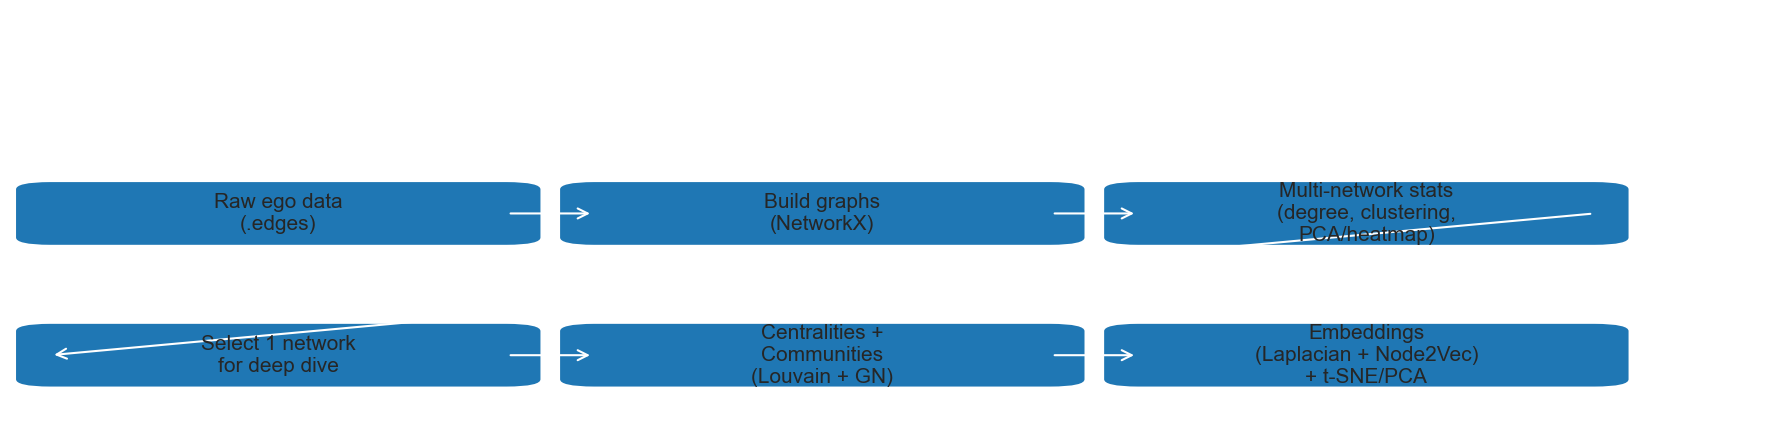

Saved: twitter_ego\twitter\summary_tables\pipeline_schematic.png


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import Image, display

def add_box(ax, xy, text, w=0.26, h=0.12):
    x, y = xy
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", linewidth=1)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)
    return (x, y, w, h)

def add_arrow(ax, b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    a = FancyArrowPatch((x1+w1, y1+h1/2), (x2, y2+h2/2), arrowstyle="->",
                       mutation_scale=12, linewidth=1)
    ax.add_patch(a)

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

b1 = add_box(ax, (0.02, 0.45), "Raw ego data\n(.edges)")
b2 = add_box(ax, (0.33, 0.45), "Build graphs\n(NetworkX)")
b3 = add_box(ax, (0.64, 0.45), "Multi-network stats\n(degree, clustering,\nPCA/heatmap)")

b4 = add_box(ax, (0.02, 0.10), "Select 1 network\nfor deep dive")
b5 = add_box(ax, (0.33, 0.10), "Centralities +\nCommunities\n(Louvain + GN)")
b6 = add_box(ax, (0.64, 0.10), "Embeddings\n(Laplacian + Node2Vec)\n+ t-SNE/PCA")

add_arrow(ax, b1, b2)
add_arrow(ax, b2, b3)
add_arrow(ax, b3, b4)
add_arrow(ax, b4, b5)
add_arrow(ax, b5, b6)

out_path = summary_dir / "pipeline_schematic.png"
plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.close()

display(Image(filename=str(out_path)))
print("Saved:", out_path)

## 2. Construire les graphes et calculer des statistiques de base

Pour chaque ego-réseau, on construit un graphe NetworkX et on calcule des métriques de base.

**Choix de construction du graphe**
- On part du fichier `*.edges` fourni (interprété comme un graphe orienté).
- On **n’ajoute pas d’arêtes artificielles** (pas de connexion ego → tous les voisins), afin de ne pas biaiser les métriques.

**Sortie enregistrée**
- `basic_stats.csv` (noeuds, arêtes, densité, nombre de SCC/WCC, connectivité faible)

In [5]:
# Build graphs
def build_ego_graph(node_id, network_data):
    G = nx.DiGraph()
    edges = network_data.get('edges', pd.DataFrame(columns=['source','target']))
    if not edges.empty:
        G.add_edges_from(edges[['source','target']].values)
    G.add_node(node_id)
    return G
all_networks = {node_id: load_ego_network(node_id, twitter_path) for node_id in ego_network_ids}
print(f"Loaded {len(all_networks)} networks into all_networks")
graphs = {}
for node_id, network_data in all_networks.items():
    graphs[node_id] = build_ego_graph(node_id, network_data)

# Compute basic stats
def compute_basic_stats(G):
    stats = {
        'num_nodes': G.number_of_nodes(),
        'num_edges': G.number_of_edges(),
        'density': nx.density(G),
        'is_connected': nx.is_weakly_connected(G) if G.number_of_nodes()>0 else False,
    }
    try:
        stats['num_scc'] = nx.number_strongly_connected_components(G)
        stats['num_wcc'] = nx.number_weakly_connected_components(G)
    except Exception:
        stats['num_scc'] = 0
        stats['num_wcc'] = 0
    return stats

network_stats = {nid: compute_basic_stats(G) for nid, G in graphs.items()}
stats_df = pd.DataFrame(network_stats).T
stats_df.index.name = 'network_id'
print('Basic Network Statistics (first rows):')
display(stats_df.head())
# Save
stats_df.to_csv(summary_dir / 'basic_stats.csv')

Loaded 973 networks into all_networks
Basic Network Statistics (first rows):


,num_nodes,num_edges,density,num_components,largest_cc_size
network_id,,,,,
12831,236.0,1811.0,0.065308,2.0,234.0
78813,231.0,2257.0,0.084961,2.0,229.0
356963,126.0,495.0,0.062857,2.0,122.0
428333,65.0,929.0,0.446635,1.0,65.0
612473,76.0,934.0,0.327719,1.0,76.0


## 3. Statistiques de degré (tableaux)

On calcule, pour chaque réseau, les distributions du **degré entrant** (in-degree) et du **degré sortant** (out-degree), puis on les résume avec :
- moyenne / médiane
- maximum
- écart-type

**Sortie enregistrée**
- `degree_stats.csv`


In [6]:
# Compute degree statistics
def compute_degree_stats(G):
    in_degrees = [d for _, d in G.in_degree()]
    out_degrees = [d for _, d in G.out_degree()]
    if len(in_degrees)==0: in_degrees=[0]
    if len(out_degrees)==0: out_degrees=[0]
    stats = {
        'mean_in_degree': float(np.mean(in_degrees)),
        'median_in_degree': float(np.median(in_degrees)),
        'max_in_degree': int(np.max(in_degrees)),
        'std_in_degree': float(np.std(in_degrees)),
        'mean_out_degree': float(np.mean(out_degrees)),
        'median_out_degree': float(np.median(out_degrees)),
        'max_out_degree': int(np.max(out_degrees)),
        'std_out_degree': float(np.std(out_degrees)),
    }
    return stats, in_degrees, out_degrees

degree_stats = {}
degree_distributions = {}
for nid, G in graphs.items():
    st, ind, outd = compute_degree_stats(G)
    degree_stats[nid] = st
    degree_distributions[nid] = {'in': ind, 'out': outd}
degree_stats_df = pd.DataFrame(degree_stats).T
degree_stats_df.index.name = 'network_id'
print('Degree statistics (first rows):')
display(degree_stats_df.head())
degree_stats_df.to_csv(summary_dir / 'degree_stats.csv')

Degree statistics (first rows):


,mean_degree,median_degree,max_degree,std_degree
network_id,,,,
12831,15.347458,12.0,59.0,12.500764
78813,19.541126,15.0,95.0,16.968695
356963,7.857143,6.0,55.0,7.671545
428333,28.584615,28.0,62.0,14.262260
612473,24.578947,23.5,62.0,14.308870


## 4. Coefficients de clustering (tableaux)

Le clustering est généralement défini sur des graphes **non orientés**, donc on calcule ces métriques sur une projection non orientée du graphe.

Métriques reportées :
- coefficient de clustering moyen
- transitivité (clustering global)
- min / max / écart-type des coefficients de clustering par noeud

**Sortie enregistrée**
- `clustering_stats.csv`

In [7]:
def compute_clustering_stats(G):
    G_undirected = G.to_undirected()
    if G_undirected.number_of_nodes() == 0:
        return {
            'avg_clustering': 0.0, 'transitivity': 0.0, 'max_clustering': 0.0, 'min_clustering': 0.0, 'std_clustering': 0.0
        }, []
    try:
        avg_clustering = nx.average_clustering(G_undirected)
    except Exception:
        avg_clustering = 0.0
    try:
        transitivity = nx.transitivity(G_undirected)
    except Exception:
        transitivity = 0.0
    clustering_coeffs = list(nx.clustering(G_undirected).values())
    stats = {
        'avg_clustering': float(avg_clustering),
        'transitivity': float(transitivity),
        'max_clustering': float(np.max(clustering_coeffs)) if clustering_coeffs else 0.0,
        'min_clustering': float(np.min(clustering_coeffs)) if clustering_coeffs else 0.0,
        'std_clustering': float(np.std(clustering_coeffs)) if clustering_coeffs else 0.0
    }
    return stats, clustering_coeffs

clustering_stats = {}
clustering_distributions = {}
for nid, G in graphs.items():
    st, coeffs = compute_clustering_stats(G)
    clustering_stats[nid] = st
    clustering_distributions[nid] = coeffs
clustering_df = pd.DataFrame(clustering_stats).T
clustering_df.index.name = 'network_id'
print('Clustering stats (first rows):')
display(clustering_df.head())
clustering_df.to_csv(summary_dir / 'clustering_stats.csv')

Clustering stats (first rows):


,avg_clustering,transitivity,max_clustering,min_clustering,std_clustering
network_id,,,,,
12831,0.363240,0.302879,1.0,0.000000,0.223487
78813,0.340839,0.297926,1.0,0.000000,0.205896
356963,0.367805,0.351873,1.0,0.000000,0.330295
428333,0.737253,0.635791,1.0,0.455843,0.135596
612473,0.625586,0.537932,1.0,0.000000,0.169299


## 5. Tableau comparatif complet

On fusionne toutes les métriques au niveau réseau dans un seul dataframe afin de faciliter la comparaison (tableaux > tableaux de bord).

Métrique dérivée supplémentaire :
- `avg_degree` = moyenne entre la moyenne des degrés entrants et la moyenne des degrés sortants

**Sortie enregistrée**
- `comprehensive_metrics.csv`

In [8]:
comprehensive_df = stats_df.copy()
comprehensive_df = comprehensive_df.join(degree_stats_df, how='left')
comprehensive_df = comprehensive_df.join(clustering_df, how='left')
comprehensive_df['avg_degree'] = (comprehensive_df['mean_in_degree'] + comprehensive_df['mean_out_degree']) / 2


comprehensive_df.index = comprehensive_df.index.astype(int)
print('Comprehensive metrics (first rows):')
display(comprehensive_df.head())
comprehensive_df.to_csv(summary_dir / 'comprehensive_metrics.csv')

Comprehensive metrics (first rows):


,num_nodes,num_edges,density,num_components,largest_cc_size,mean_degree,median_degree,max_degree,std_degree,avg_clustering,transitivity,max_clustering,min_clustering,std_clustering,avg_degree
network_id,,,,,,,,,,,,,,,
12831,236.0,1811.0,0.065308,2.0,234.0,15.347458,12.0,59.0,12.500764,0.363240,0.302879,1.0,0.000000,0.223487,15.347458
78813,231.0,2257.0,0.084961,2.0,229.0,19.541126,15.0,95.0,16.968695,0.340839,0.297926,1.0,0.000000,0.205896,19.541126
356963,126.0,495.0,0.062857,2.0,122.0,7.857143,6.0,55.0,7.671545,0.367805,0.351873,1.0,0.000000,0.330295,7.857143
428333,65.0,929.0,0.446635,1.0,65.0,28.584615,28.0,62.0,14.262260,0.737253,0.635791,1.0,0.455843,0.135596,28.584615
612473,76.0,934.0,0.327719,1.0,76.0,24.578947,23.5,62.0,14.308870,0.625586,0.537932,1.0,0.000000,0.169299,24.578947


## 6. Détection d’anomalies (tableaux)

On repère les réseaux **inhabituellement** grands / denses / clusterisés à l’aide d’une règle simple basée sur le **z-score**.

- Une métrique est considérée comme atypique lorsque `|z| > threshold` (par défaut : 1.5).
- C’est une méthode descriptive rapide (pas un test statistique), utile pour mettre en avant des candidats à inspecter.

**Sorties enregistrées**
- `outliers_flat.csv` (facile à lire)
- `outliers.json` (structuré)

In [9]:
def identify_outliers(df, columns, threshold=1.5):
    outliers = {}
    for col in columns:
        if col not in df.columns:
            continue
        col_vals = df[col].astype(float).values
        z_scores = np.abs((col_vals - np.nanmean(col_vals)) / (np.nanstd(col_vals) if np.nanstd(col_vals)!=0 else 1e-8))
        mask = z_scores > threshold
        if mask.any():
            nets = df.index[mask].tolist()
            vals = df.loc[nets, col].tolist()
            zs = z_scores[mask].tolist()
            outliers[col] = {'networks': nets, 'values': vals, 'z_scores': zs}
    return outliers

metrics_to_check = ['num_nodes', 'num_edges', 'density', 'avg_degree', 'avg_clustering', 'transitivity']
outliers = identify_outliers(comprehensive_df, metrics_to_check, threshold=1.5)
print('Outliers summary:')
out_rows = []
for metric, data in outliers.items():
    for net, val, z in zip(data['networks'], data['values'], data['z_scores']):
        out_rows.append({'metric': metric, 'network': net, 'value': val, 'z_score': z})
outliers_df = pd.DataFrame(out_rows)
display(outliers_df.head())
outliers_df.to_csv(summary_dir / 'outliers_flat.csv', index=False)
import json
with open(summary_dir / 'outliers.json', 'w') as f:
    json.dump(outliers, f, indent=2)

Outliers summary:


,metric,network,value,z_score
0,num_nodes,12831,236.0,1.617617
1,num_nodes,78813,231.0,1.540028
2,num_nodes,734493,9.0,1.904928
3,num_nodes,745823,242.0,1.710724
4,num_nodes,809864,235.0,1.602099


## 7. Clustering des réseaux (tableaux) + visualisation minimale

On regroupe (clusterise) les réseaux à partir d’un ensemble de métriques sélectionnées (après standardisation).

Méthode :
- Standardiser les variables (z-score via `StandardScaler`)
- Clustering KMeans (k choisi de manière conservatrice pour de petits jeux de données)
- Coordonnées PCA sauvegardées pour permettre une visualisation 2D légère si besoin

**Sorties enregistrées**
- `comprehensive_with_clusters.csv`
- `cluster_summary.csv`
- `pca_coords.csv`

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

clustering_features = [c for c in ['num_nodes','num_edges','density','avg_degree','avg_clustering','transitivity'] if c in comprehensive_df.columns]
if len(comprehensive_df) >= 2 and len(clustering_features) >= 2:
    scaler = StandardScaler()
    X = comprehensive_df[clustering_features].astype(float).fillna(0)
    X_scaled = scaler.fit_transform(X)
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    comprehensive_df['cluster'] = labels
    comprehensive_df.to_csv(summary_dir / 'comprehensive_with_clusters.csv')
    # cluster summary table
    cluster_summary = comprehensive_df.groupby('cluster')[clustering_features].agg(['mean','std','count'])
    display(cluster_summary)
    cluster_summary.to_csv(summary_dir / 'cluster_summary.csv')
    # save PCA coords
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame(pca_coords, index=comprehensive_df.index, columns=['PC1','PC2'])
    pca_df.to_csv(summary_dir / 'pca_coords.csv')
else:
    comprehensive_df['cluster'] = 0
    comprehensive_df.to_csv(summary_dir / 'comprehensive_with_clusters.csv')
    cluster_summary = comprehensive_df.groupby('cluster')[clustering_features].agg(['mean','std','count'])
    cluster_summary.to_csv(summary_dir / 'cluster_summary.csv')
    display(cluster_summary.head())

num_nodes                     num_edges                     \
               mean        std count         mean          std count   
cluster                                                                
0        189.882155  34.410817   297  3566.727273  1413.709627   297   
1         58.251337  30.891345   187   767.657754   737.189417   187   
2        124.564417  54.950839   489   941.341513   632.985720   489   

          density                 avg_degree                  avg_clustering  \
             mean       std count       mean        std count           mean   
cluster                                                                        
0        0.205898  0.078607   297  37.550580  12.656758   297       0.544040   
1        0.411641  0.158955   187  21.300775  11.875333   187       0.689594   
2        0.124573  0.056286   489  13.720714   5.853316   489       0.449974   

                        transitivity                  
              std count         mean       std count  
cluster                                               
0        0.067074   297     0.495488  0.075694   297  
1        0.086039   187     0.647992  0.100860   187  
2        0.083898   489     0.406681  0.096698   489

## 8. Réseaux typiques vs atypiques (tableaux)

On mesure à quel point chaque réseau s’éloigne du réseau “moyen” en utilisant une distance euclidienne dans l’espace des z-scores.

- Réseaux “typiques” : distance au-dessous de la médiane (par rapport à la moyenne)
- Réseaux “atypiques” : distance au-dessus de la médiane

**Sorties enregistrées**
- `typical_networks.csv`
- `unusual_networks.csv`
- `comprehensive_final.csv`

In [11]:
mean_values = comprehensive_df[clustering_features].mean() if len(clustering_features)>0 else pd.Series()
std_values = comprehensive_df[clustering_features].std().replace(0, 1e-8) if len(clustering_features)>0 else pd.Series()
distances = []
for idx in comprehensive_df.index:
    if len(clustering_features)==0:
        distances.append(0.0)
        continue
    network_values = comprehensive_df.loc[idx, clustering_features]
    z_scores = (network_values - mean_values) / std_values
    distance = np.sqrt((z_scores.fillna(0) ** 2).sum())
    distances.append(distance)
comprehensive_df['distance_from_mean'] = distances
comprehensive_df['is_typical'] = comprehensive_df['distance_from_mean'] < np.nanmedian(comprehensive_df['distance_from_mean'])
typical_networks = comprehensive_df[comprehensive_df['is_typical']].index.tolist()
unusual_networks = comprehensive_df[~comprehensive_df['is_typical']].index.tolist()
pd.Series(typical_networks).to_csv(summary_dir / 'typical_networks.csv', index=False, header=False)
pd.Series(unusual_networks).to_csv(summary_dir / 'unusual_networks.csv', index=False, header=False)
print(f"Typical networks: {len(typical_networks)}")
print(f"Unusual networks: {len(unusual_networks)}")
print("Most typical (5):", comprehensive_df.sort_values("distance_from_mean").head(5).index.tolist())
print("Most unusual (5):", comprehensive_df.sort_values("distance_from_mean", ascending=False).head(5).index.tolist())
display(comprehensive_df[[*clustering_features, 'distance_from_mean', 'is_typical']].head())
comprehensive_df.to_csv(summary_dir / 'comprehensive_final.csv')

Typical networks (486): [612473, 613313, 629863, 759679, 778446, 779715, 789071, 926981, 1046661, 1548841, 1608991, 2029971, 2257971, 2589521, 2841151, 3245291, 3253671, 4258591, 4387041, 5471892, 5506012, 5539522, 5747502, 5773532, 5774432, 5868402, 6297852, 6351572, 6408382, 7098022, 7670202, 7888452, 8079892, 9254272, 9298152, 9524062, 10146102, 10798802, 11027262, 11136132, 11681802, 11784842, 12069912, 12152402, 12415722, 12570812, 12771872, 13179562, 13212502, 13275962, 13317162, 13460312, 13649212, 13747362, 13809612, 13872872, 14045302, 14058831, 14077024, 14120253, 14147754, 14191254, 14203895, 14313005, 14332288, 14338082, 14365883, 14371740, 14372763, 14404235, 14521330, 14528221, 14550962, 14618160, 14719129, 14755105, 14791232, 14807093, 14840869, 14848513, 14893314, 14917050, 14922225, 14936377, 14957252, 14984096, 15070932, 15099384, 15164892, 15331855, 15347317, 15419775, 15473958, 15477120, 15527013, 15647676, 15665127, 15706128, 15741636, 15849055, 15864197, 15947217,

,num_nodes,num_edges,density,avg_degree,avg_clustering,transitivity,distance_from_mean,is_typical
network_id,,,,,,,,
12831,236.0,1811.0,0.065308,15.347458,0.363240,0.302879,2.746942,False
78813,231.0,2257.0,0.084961,19.541126,0.340839,0.297926,2.756046,False
356963,126.0,495.0,0.062857,7.857143,0.367805,0.351873,2.319640,False
428333,65.0,929.0,0.446635,28.584615,0.737253,0.635791,3.008580,False
612473,76.0,934.0,0.327719,24.578947,0.625586,0.537932,1.639449,True


In [12]:
# --- Select best networks based on analysis ---

metrics = [c for c in ['num_nodes','num_edges','density','avg_degree','avg_clustering','transitivity'] if c in comprehensive_df.columns]
rank_df = comprehensive_df.copy()

if len(metrics) > 0:
    z = (rank_df[metrics].astype(float).fillna(0) - rank_df[metrics].mean()) / rank_df[metrics].std().replace(0, 1e-8)
    for m in metrics:
        rank_df[f'z_{m}'] = z[m]
    # composite score: sum of absolute z-scores (higher => more atypical)
    rank_df['composite_score'] = z.abs().sum(axis=1)
else:
    rank_df['composite_score'] = 0

# ensure distance_from_mean exists
if 'distance_from_mean' not in rank_df.columns:
    if len(metrics) > 0:
        rank_df['distance_from_mean'] = np.sqrt((z.fillna(0) ** 2).sum(axis=1))
    else:
        rank_df['distance_from_mean'] = 0

# selection helpers
def pick_representative(df):
    return df['distance_from_mean'].idxmin() if len(df) > 0 else None

def pick_most_atypical(df, topk=3):
    return df.sort_values('composite_score', ascending=False).head(topk).index.tolist()

def pick_by_metric(df, metric, topk=3):
    return df.sort_values(metric, ascending=False).head(topk).index.tolist() if metric in df.columns else []

# picks
representative_net_avg = pick_representative(rank_df)
atypical_top3 = pick_most_atypical(rank_df, topk=3)
top_by_nodes = pick_by_metric(rank_df, 'num_nodes', topk=3)
top_by_edges = pick_by_metric(rank_df, 'num_edges', topk=3)

# ============================================================================
# CHOIX DU GRAPHE POUR L'ANALYSE
# ============================================================================
# - Plus de structure à analyser
# - Communautés plus nombreuses et distinctes
# - Embeddings plus riches
# - Comparaisons de centralités plus significatives

representative_net = int(representative_net_avg)  # deep dive on the most typical network

print('='*60)
print('SÉLECTION DU GRAPHE POUR ANALYSE')
print('='*60)
print(f'Graphe moyen (distance min): {representative_net_avg}')
print(f'Top 3 par noeuds: {top_by_nodes}')
print(f'Top 3 par arêtes: {top_by_edges}')
print(f'Top 3 atypiques: {atypical_top3}')
print('-'*60)
print(f'>>> GRAPHE SÉLECTIONNÉ: {representative_net} <<<')
print('-'*60)

comparison_nets = list(set([representative_net_avg] + top_by_nodes[:2]))
print('\nComparaison des candidats:')
display(rank_df.loc[comparison_nets, ['num_nodes', 'num_edges', 'density', 'avg_clustering', 'transitivity']].sort_values('num_nodes', ascending=False))

pd.Series([representative_net]).to_csv(summary_dir / 'selected_network.csv', index=False, header=False)
pd.Series(atypical_top3).to_csv(summary_dir / 'atypical_top3.csv', index=False, header=False)
pd.Series(top_by_nodes).to_csv(summary_dir / 'top_by_nodes.csv', index=False, header=False)

cols_to_save = ['num_nodes', 'num_edges', 'composite_score', 'distance_from_mean'] + [f'z_{m}' for m in metrics]
rank_df[cols_to_save].to_csv(summary_dir / 'network_rankings.csv')

if representative_net in graphs:
    G_selected = graphs[representative_net]
    print(f"\nGraphe sélectionné — noeuds: {G_selected.number_of_nodes()}, arêtes: {G_selected.number_of_edges()}")
    print(f"Densité: {nx.density(G_selected):.4f}")

SÉLECTION DU GRAPHE POUR ANALYSE
Graphe moyen (distance min): 197602850
Top 3 par noeuds: [170729553, 134943586, 15329577]
Top 3 par arêtes: [256497288, 314316607, 217796457]
Top 3 atypiques: [256497288, 734493, 1435461]
------------------------------------------------------------
>>> GRAPHE SÉLECTIONNÉ: 170729553 <<<
------------------------------------------------------------

Comparaison des candidats:


,num_nodes,num_edges,density,avg_clustering,transitivity
network_id,,,,,
170729553,247.0,5629.0,0.185280,0.508496,0.482882
134943586,247.0,6271.0,0.206412,0.581271,0.454337
197602850,134.0,1501.0,0.168443,0.511757,0.484039



Graphe sélectionné — noeuds: 247, arêtes: 5629
Densité: 0.1853


Sauvegardé: twitter_ego\twitter\summary_tables\170729553_degree_distribution_hist.png


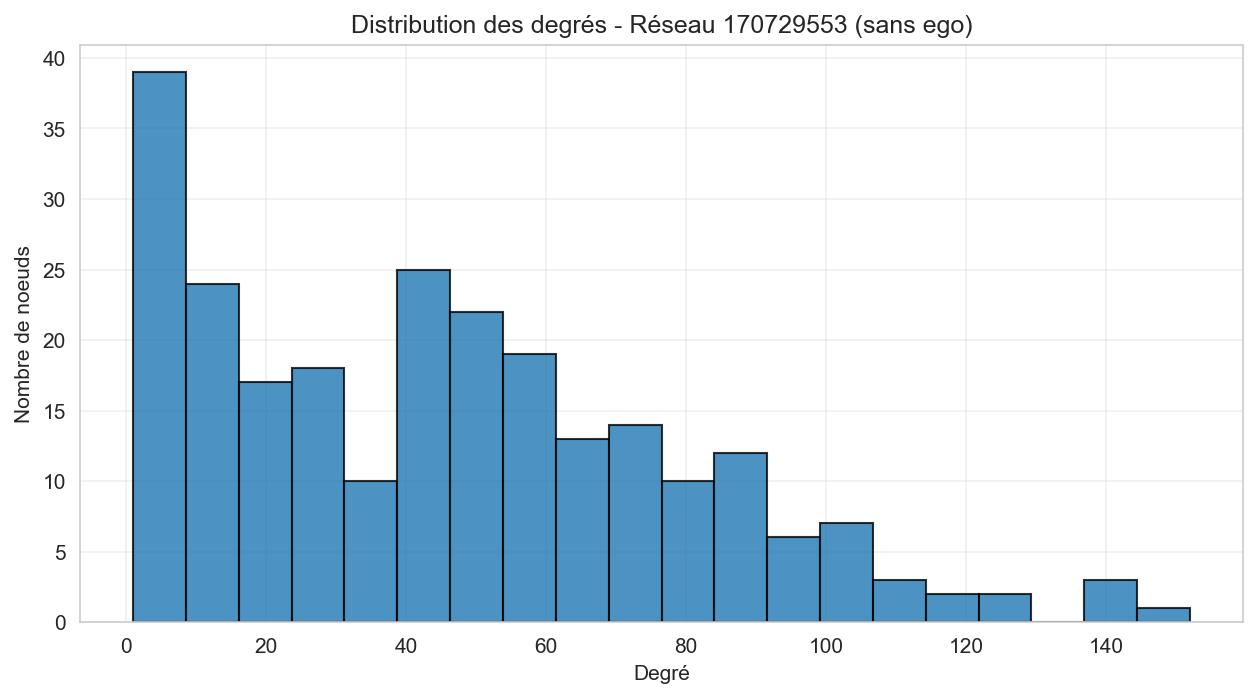

In [13]:
# HISTOGRAMME DE DISTRIBUTION DES DEGRÉS (graphe sélectionné)

rep = globals().get('representative_net', None)
rep = int(rep) if rep is not None else None
if rep is None:
    print("Pas de graphe sélectionné.")
else:
    rep = int(rep)

    G_hist = graphs[rep].to_undirected().copy()

    degrees = [d for _, d in G_hist.degree()]

    plt.figure(figsize=(10, 5))
    plt.hist(degrees, bins=20, edgecolor='black', alpha=0.8)
    plt.xlabel("Degré")
    plt.ylabel("Nombre de noeuds")
    plt.title(f"Distribution des degrés - Réseau {rep} (sans ego)")
    plt.grid(alpha=0.3)
    out_path = summary_dir / f"{rep}_degree_distribution_hist.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f"Sauvegardé: {out_path}")
    from IPython.display import display, Image

    display(Image(filename=str(out_path)))

Affichage du graphe représentatif et choisi

Saved: twitter_ego\twitter\summary_tables\170729553_selected_graph.png


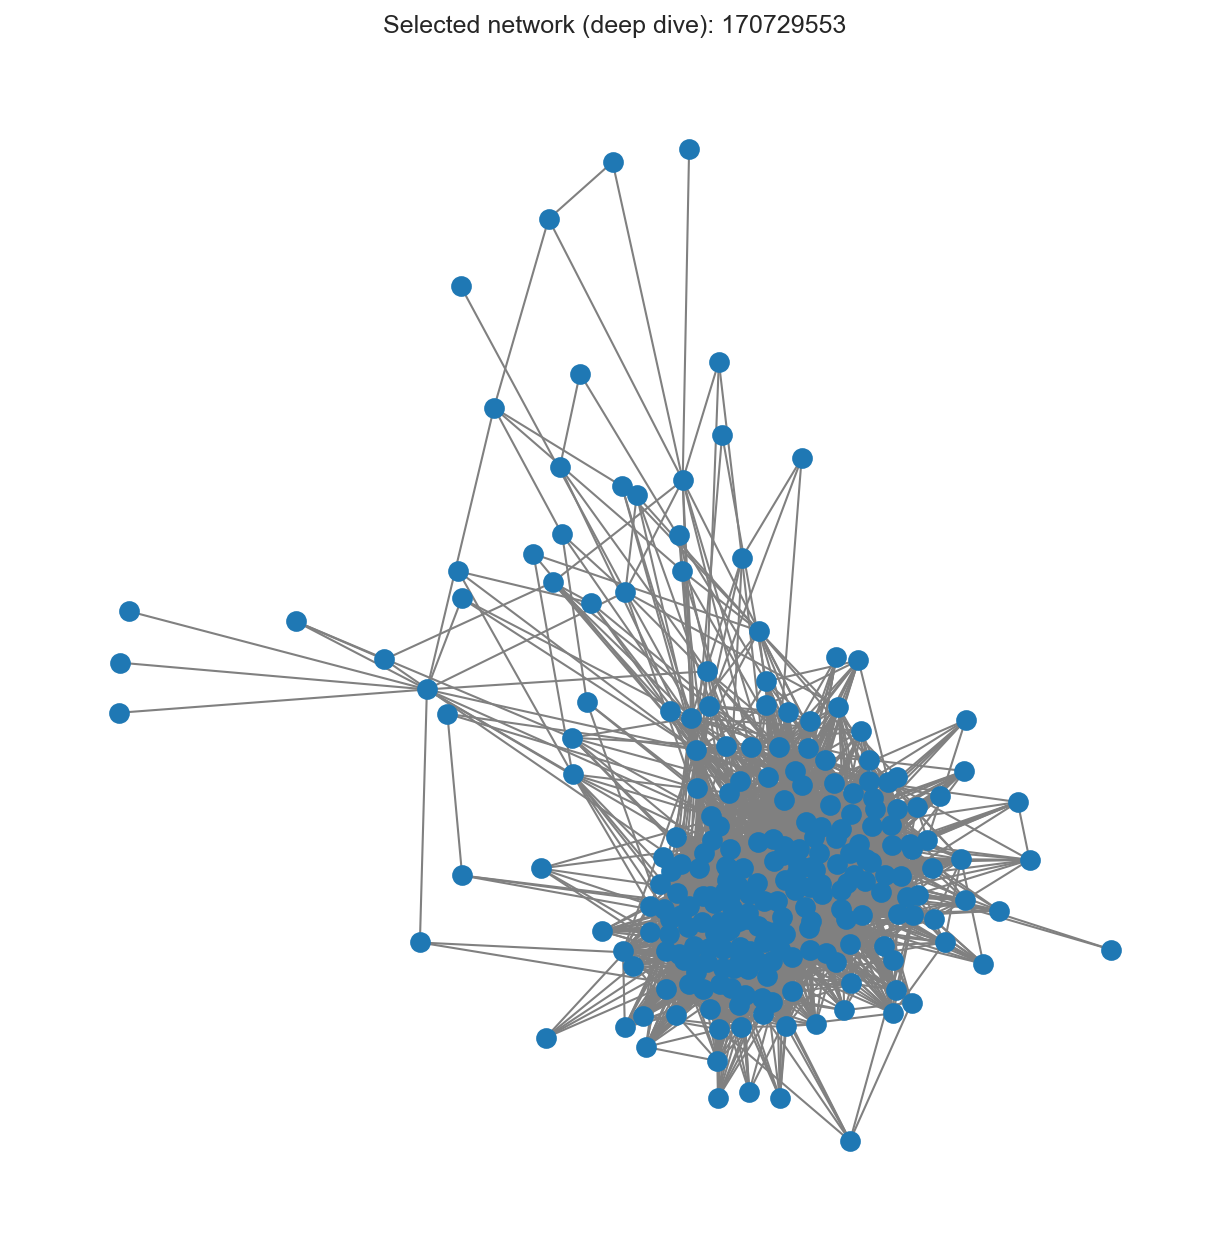

In [14]:
# Plot & save the selected network (deep dive)
rep = globals().get('representative_net', None)
if rep is None:
    print("No selected network. Run the selection cell first (Cell 19).")
else:
    rep = int(rep)
    if rep not in graphs:
        print(f"Graph {rep} not found in `graphs`.")
    else:
        G = graphs[rep]
        out_path = summary_dir / f"{rep}_selected_graph.png"

        plt.figure(figsize=(8, 8))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=False, node_size=80, edge_color="gray")
        plt.title(f"Selected network (deep dive): {rep}")
        plt.axis("off")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()

        print("Saved:", out_path)
        from IPython.display import Image, display
        display(Image(filename=str(out_path)))

## Bonus Deep Learning - GCN (démonstration)
On entraîne un petit GCN sur des **labels synthétiques** (bins de degré) pour illustrer une approche neuronale.
Ce bloc est pédagogique : ce n’est pas une tâche supervisée “réelle” avec ground-truth.

Preparing graph for GNN: 170729553
Prepared node features and labels saved to: twitter_ego\twitter\summary_tables/prepared_170729553_nodes.csv
Using device: cpu
Epoch 001  train_loss=0.6434  val_loss=0.6432  train_acc=0.676  val_acc=0.592
Epoch 050  train_loss=0.4721  val_loss=0.5123  train_acc=0.703  val_acc=0.673
Epoch 100  train_loss=0.4516  val_loss=0.4975  train_acc=0.716  val_acc=0.673
Epoch 150  train_loss=0.4279  val_loss=0.4707  train_acc=0.770  val_acc=0.694
Epoch 200  train_loss=0.4117  val_loss=0.4489  train_acc=0.784  val_acc=0.796

>>> Test accuracy: 0.800 <<<
Training history saved to: twitter_ego\twitter\summary_tables/170729553_training_history.csv
Training curves saved to: twitter_ego\twitter\summary_tables\170729553_training_curves.png


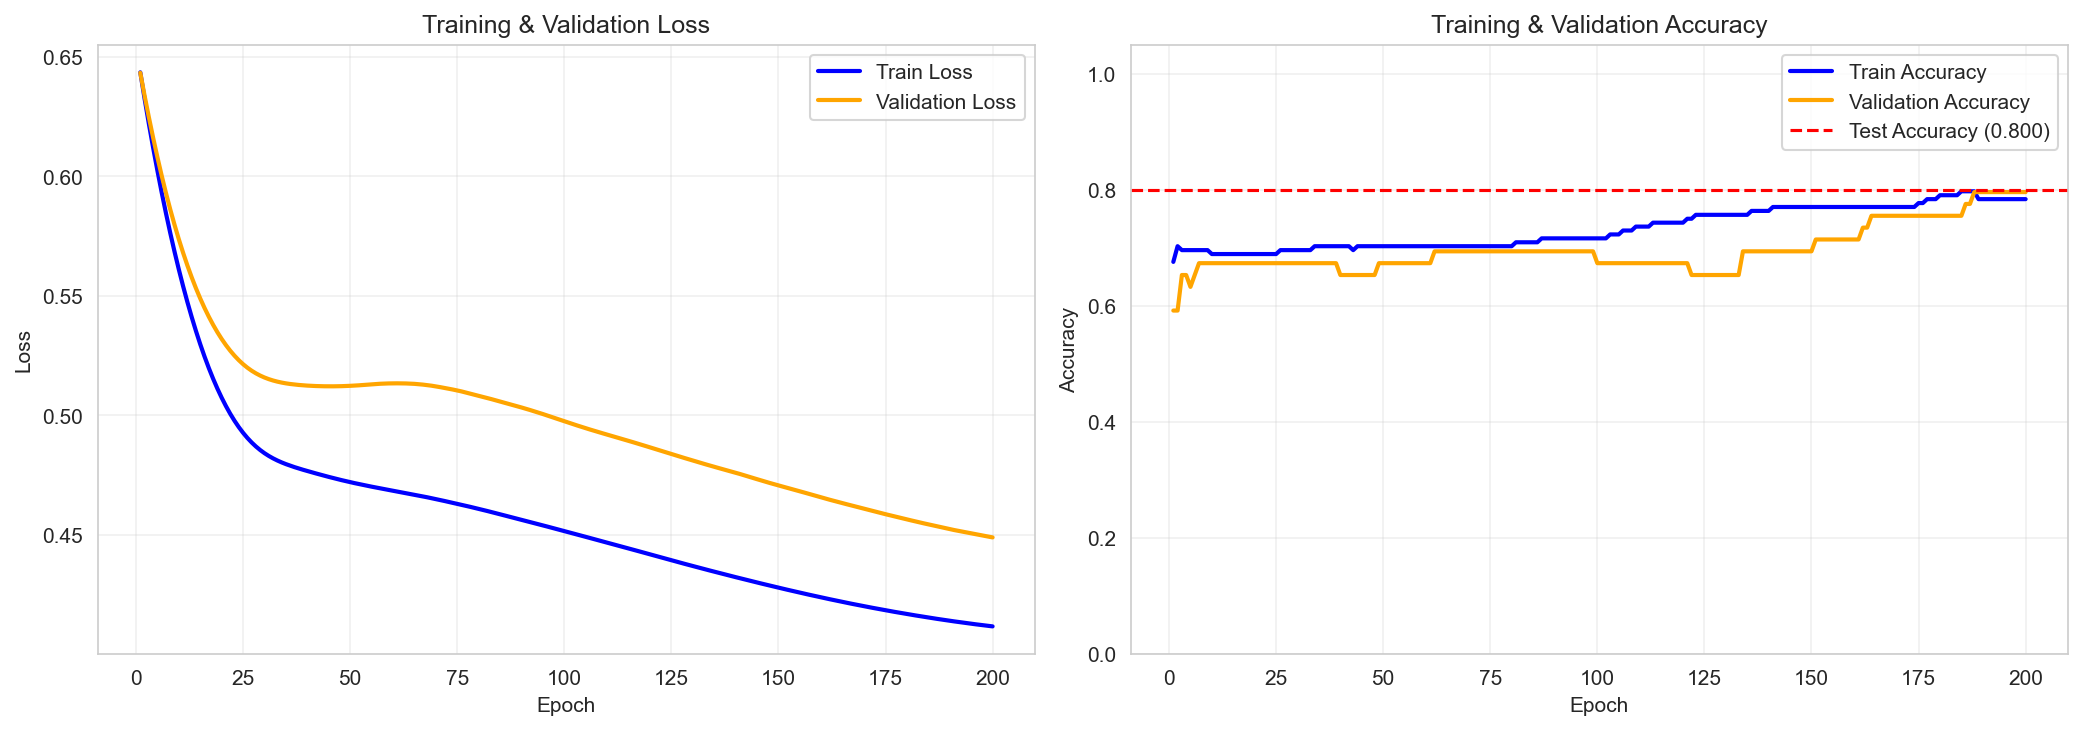

Saved node embeddings to: twitter_ego\twitter\summary_tables\170729553_node_embeddings.csv


In [15]:
if 'representative_net' not in globals() or representative_net is None:
    print('No representative network selected. Run the previous selection cell first.')
else:
    rep = int(representative_net)
    print('Preparing graph for GNN:', rep)
    Gsel = graphs[rep].to_undirected()
    nodes = list(Gsel.nodes())
    n = len(nodes)
    if n == 0:
        print('Graph is empty.')
    else:
        idx = {node: i for i, node in enumerate(nodes)}
        A = nx.to_numpy_array(Gsel, nodelist=nodes)
        # Node features: degree and clustering (and ego feature if available)
        deg = np.array([Gsel.degree(n) for n in nodes], dtype=float)
        clust = np.array([nx.clustering(Gsel, n) for n in nodes], dtype=float)
        X = np.vstack([deg, clust]).T
        # Normalize features
        X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

        # Synthetic labels: bin degrees into 3 classes (low/med/high)
        try:
            import pandas as pd
            labels = pd.qcut(deg, q=3, labels=False, duplicates='drop').astype(int).values
            num_classes = int(labels.max() + 1)
        except Exception:
            labels = (deg > np.median(deg)).astype(int)
            num_classes = max(2, int(labels.max() + 1))

        # Save prepared data
        prep_df = pd.DataFrame(X, index=nodes, columns=['deg_z','clust_z'])
        prep_df['label'] = labels
        prep_df.to_csv(summary_dir / f'prepared_{rep}_nodes.csv')
        print(f'Prepared node features and labels saved to: {summary_dir}/prepared_{rep}_nodes.csv')

        # Try to run a small GCN using PyTorch
        try:
            import torch
            import torch.nn as nn
            import torch.nn.functional as F
            import torch.optim as optim

            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            print('Using device:', device)

            # Build normalized adjacency
            A_tilde = A + np.eye(n)
            D = np.diag(A_tilde.sum(axis=1))
            D_inv_sqrt = np.linalg.inv(np.sqrt(D))
            A_norm = D_inv_sqrt @ A_tilde @ D_inv_sqrt
            A_norm = torch.tensor(A_norm, dtype=torch.float32, device=device)
            X_t = torch.tensor(X, dtype=torch.float32, device=device)
            y = torch.tensor(labels, dtype=torch.long, device=device)

            # Simple train/val/test split
            rng = np.random.default_rng(42)
            perm = rng.permutation(n)
            n_train = max(1, int(0.6 * n))
            n_val = max(1, int(0.2 * n))
            idx_train = perm[:n_train]
            idx_val = perm[n_train:n_train + n_val]
            idx_test = perm[n_train + n_val:]

            class SimpleGCN(nn.Module):
                def __init__(self, in_feats, hid_feats, out_feats):
                    super().__init__()
                    self.w1 = nn.Parameter(torch.randn(in_feats, hid_feats) / np.sqrt(in_feats))
                    self.w2 = nn.Parameter(torch.randn(hid_feats, out_feats) / np.sqrt(hid_feats))

                def forward(self, X, A_norm):
                    H = A_norm @ (X @ self.w1)
                    H = F.relu(H)
                    Z = A_norm @ (H @ self.w2)
                    return Z

            model = SimpleGCN(in_feats=X.shape[1], hid_feats=16, out_feats=num_classes).to(device)
            opt = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
            loss_fn = nn.CrossEntropyLoss()

            # Training history
            history = {
                'epoch': [],
                'train_loss': [],
                'val_loss': [],
                'train_acc': [],
                'val_acc': []
            }

            # Training loop
            best_val = 1e9
            best_state = None
            num_epochs = 200

            for epoch in range(1, num_epochs + 1):
                model.train()
                logits = model(X_t, A_norm)
                loss = loss_fn(logits[idx_train], y[idx_train])
                opt.zero_grad()
                loss.backward()
                opt.step()

                model.eval()
                with torch.no_grad():
                    logits = model(X_t, A_norm)
                    train_loss = loss_fn(logits[idx_train], y[idx_train]).item()
                    val_loss = loss_fn(logits[idx_val], y[idx_val]).item() if len(idx_val)>0 else 0.0
                    pred = logits.argmax(dim=1)
                    train_acc = (pred[idx_train] == y[idx_train]).float().mean().item()
                    val_acc = (pred[idx_val] == y[idx_val]).float().mean().item() if len(idx_val)>0 else 0.0

                # Store history
                history['epoch'].append(epoch)
                history['train_loss'].append(train_loss)
                history['val_loss'].append(val_loss)
                history['train_acc'].append(train_acc)
                history['val_acc'].append(val_acc)

                if epoch % 50 == 0 or epoch == 1:
                    print(f'Epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}')
                if val_loss < best_val:
                    best_val = val_loss
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            # Evaluate on test set
            if best_state is not None:
                model.load_state_dict(best_state)
            model.eval()
            with torch.no_grad():
                logits = model(X_t, A_norm)
                pred = logits.argmax(dim=1)
                test_acc = (pred[idx_test] == y[idx_test]).float().mean().item() if len(idx_test)>0 else 0.0
            print(f'\n>>> Test accuracy: {test_acc:.3f} <<<')
            globals()["test_acc"] = test_acc

            # Save training history
            history_df = pd.DataFrame(history)
            history_df.to_csv(summary_dir / f'{rep}_training_history.csv', index=False)
            print(f'Training history saved to: {summary_dir}/{rep}_training_history.csv')

            # Plot training curves
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Loss curves
            axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='blue', linewidth=2)
            axes[0].plot(history['epoch'], history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].set_title('Training & Validation Loss')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Accuracy curves
            axes[1].plot(history['epoch'], history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
            axes[1].plot(history['epoch'], history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)
            axes[1].axhline(y=test_acc, color='red', linestyle='--', label=f'Test Accuracy ({test_acc:.3f})')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy')
            axes[1].set_title('Training & Validation Accuracy')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            axes[1].set_ylim([0, 1.05])

            plt.tight_layout()
            out_path = summary_dir / f'{rep}_training_curves.png'
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Training curves saved to: {out_path}')

            # Display the plot
            from IPython.display import display, Image
            display(Image(filename=str(out_path)))

            # Save node embeddings (hidden layer activations)
            with torch.no_grad():
                H = F.relu(A_norm @ (X_t @ model.w1))
                emb = H.cpu().numpy()
            emb_df = pd.DataFrame(emb, index=nodes)
            emb_df.to_csv(summary_dir / f'{rep}_node_embeddings.csv')
            print('Saved node embeddings to:', summary_dir / f'{rep}_node_embeddings.csv')

        except Exception as e:
            print('PyTorch not available or error during training:', e)
            print('To run the GCN, install PyTorch (and optional GPU support). Example:')
            print('\n  pip install torch torchvision torchaudio\n')
            print('Then re-run this cell.')

## 9. Optionnel : carte thermique de corrélation (un seul graphique)

Si suffisamment de métriques sont disponibles, on calcule une matrice de corrélation et on enregistre une seule carte thermique.

**Sortie enregistrée**
- `correlation_heatmap.png` (optionnel)

## Visualisation des Embeddings GCN : t-SNE coloré par communauté

Cette section visualise les embeddings de noeuds appris par le GCN en utilisant t-SNE pour la réduction de dimension, colorés par les communautés détectées par l'algorithme de Louvain.

Chargement des embeddings GCN depuis: twitter_ego\twitter\summary_tables\170729553_node_embeddings.csv
Nombre de noeuds: 247
Dimension des embeddings: 16
Partition Louvain not found. Run the Louvain cell first.
Nombre de communautés détectées: 1

Calcul de t-SNE sur les embeddings GCN...

✅ Sauvegardé: twitter_ego\twitter\summary_tables\170729553_gcn_tsne_visualization.png


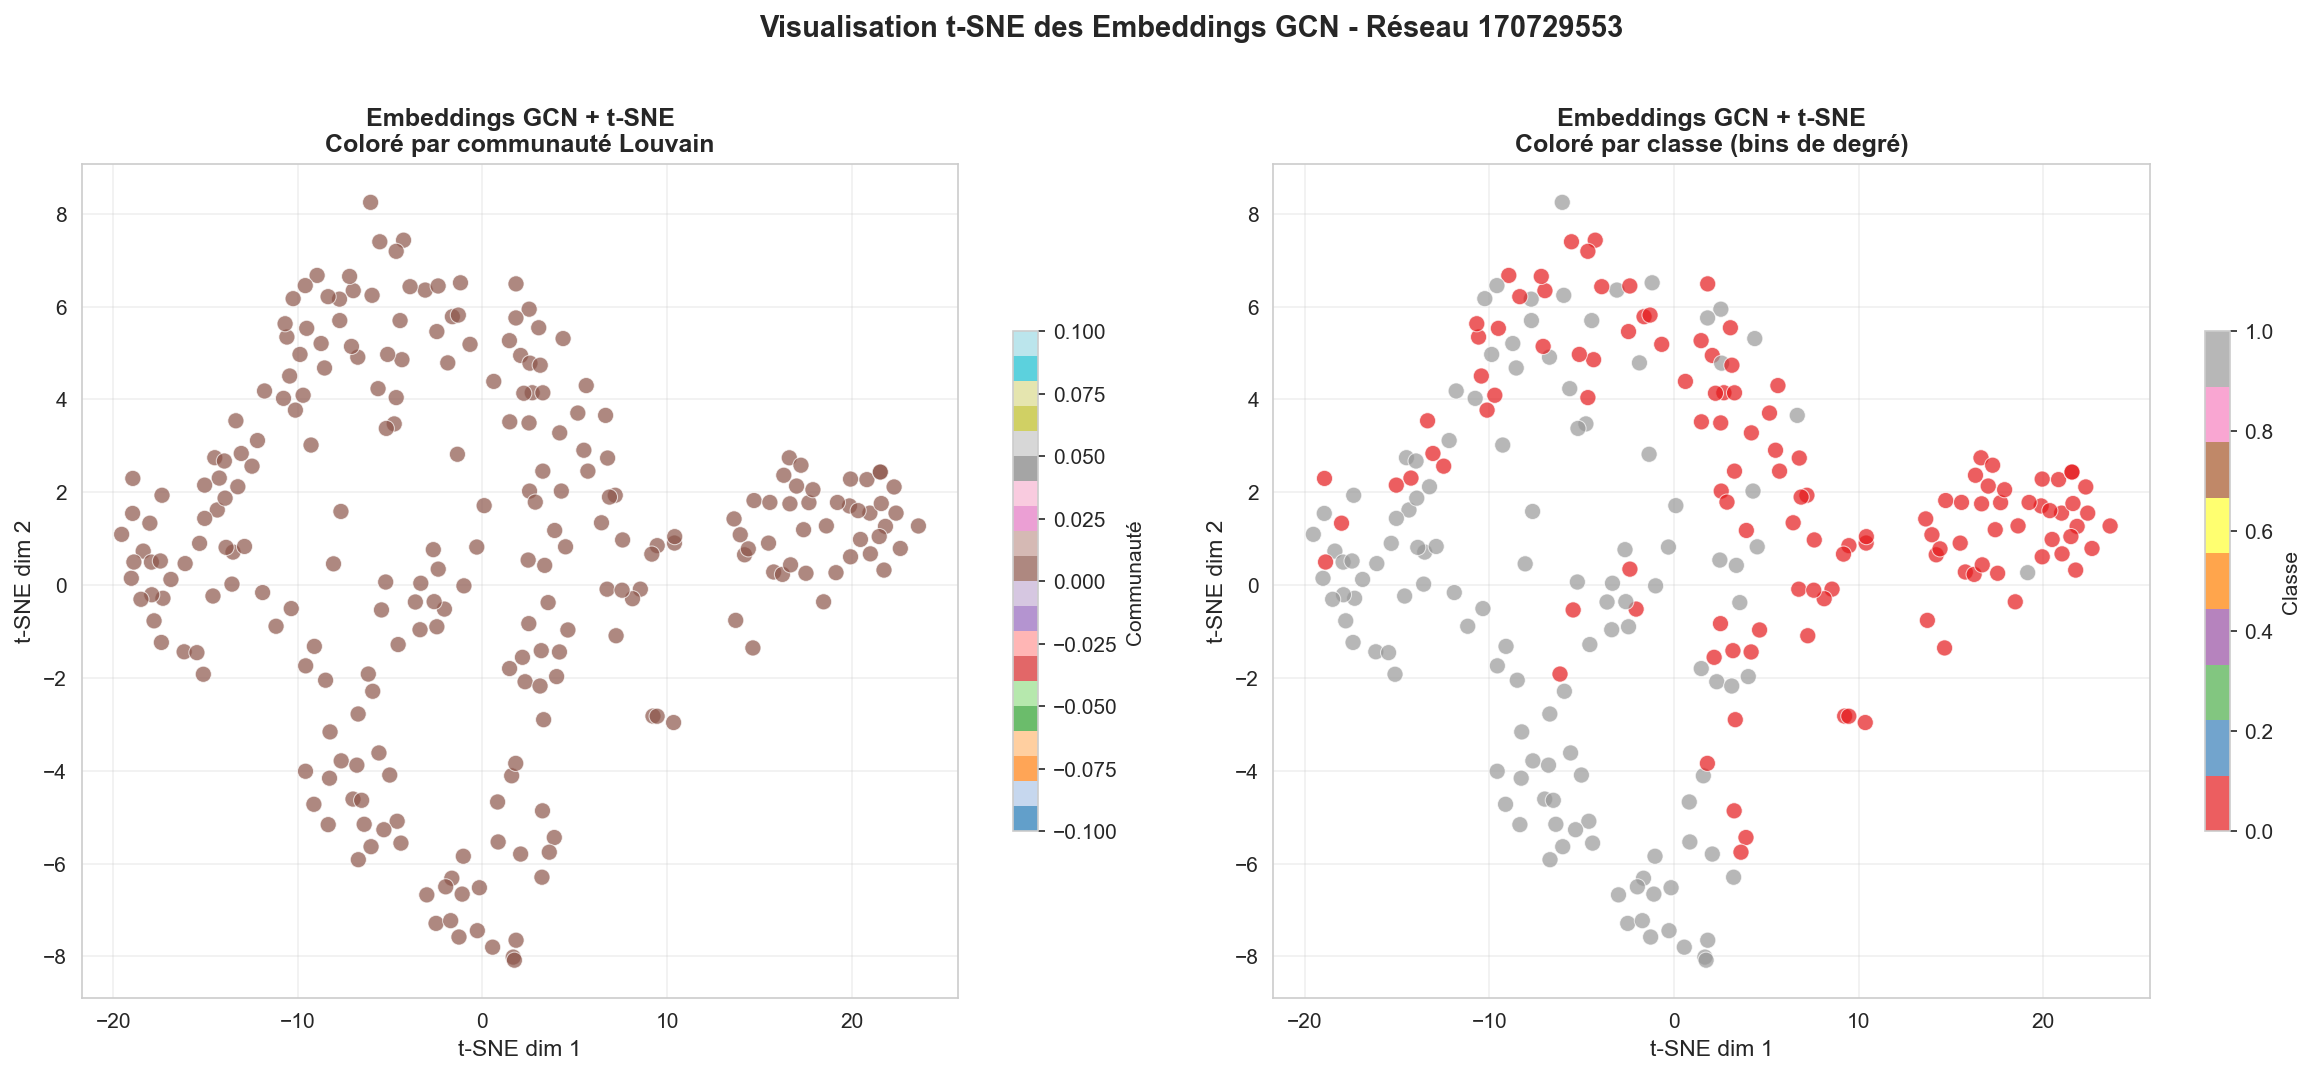


DISTRIBUTION DES NoeUDS PAR COMMUNAUTÉ
  Communauté 0: 247 noeuds (100.0%)


In [16]:
# ============================================================================
# VISUALISATION t-SNE DES EMBEDDINGS GCN COLORÉS PAR COMMUNAUTÉ
# ============================================================================

from sklearn.manifold import TSNE
from IPython.display import display, Image
import community as community_louvain

rep = globals().get('representative_net', None)
rep = int(rep) if rep is not None else None

if rep is None:
    print("Aucun graphe représentatif sélectionné.")
else:
    # Charger les embeddings GCN sauvegardés
    emb_path = summary_dir / f'{rep}_node_embeddings.csv'

    if emb_path.exists():
        print(f"Chargement des embeddings GCN depuis: {emb_path}")
        emb_df = pd.read_csv(emb_path, index_col=0)
        gcn_embeddings = emb_df.values
        gcn_nodes = [int(x) for x in emb_df.index]

        print(f"Nombre de noeuds: {len(gcn_nodes)}")
        print(f"Dimension des embeddings: {gcn_embeddings.shape[1]}")

        # Détecter les communautés avec Louvain sur le graphe non-dirigé
        if 'partition' not in globals() or not isinstance(globals().get('partition'), dict) or len(globals().get('partition')) == 0:
            print("Partition Louvain not found → computing it now.")
            G_tmp = graphs[rep].to_undirected()
            partition = community_louvain.best_partition(G_tmp)
            globals()['partition'] = partition
        else:
            partition = globals()['partition']

        # Récupérer les couleurs de communauté pour chaque noeud
        community_colors_gcn = [partition.get(n, 0) for n in gcn_nodes]
        n_communities = len(set(community_colors_gcn))
        print(f"Nombre de communautés détectées: {n_communities}")

        # Appliquer t-SNE
        print("\nCalcul de t-SNE sur les embeddings GCN...")
        n_samples = len(gcn_nodes)
        perplexity = min(30, max(5, n_samples // 4))
        perplexity = min(perplexity, n_samples - 1)

        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        gcn_tsne = tsne.fit_transform(gcn_embeddings)

        # Créer la visualisation
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # --- Plot 1: t-SNE coloré par communauté ---
        ax1 = axes[0]
        scatter1 = ax1.scatter(
            gcn_tsne[:, 0],
            gcn_tsne[:, 1],
            c=community_colors_gcn,
            cmap=plt.cm.tab20,
            s=60,
            alpha=0.7,
            edgecolors='white',
            linewidths=0.5
        )
        ax1.set_xlabel('t-SNE dim 1', fontsize=11)
        ax1.set_ylabel('t-SNE dim 2', fontsize=11)
        ax1.set_title('Embeddings GCN + t-SNE\nColoré par communauté Louvain', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)

        # --- Plot 2: t-SNE coloré par label de classe ---
        # Charger les labels si disponibles
        prep_path = summary_dir / f'prepared_{rep}_nodes.csv'
        if prep_path.exists():
            prep_df = pd.read_csv(prep_path, index_col=0)
            try:
                prep_df.index = prep_df.index.map(int)
            except Exception:
                pass
            labels_gcn = [int(prep_df.loc[n, 'label']) if n in prep_df.index else 0 for n in gcn_nodes]
        else:
            labels_gcn = community_colors_gcn  # fallback


        ax2 = axes[1]
        scatter2 = ax2.scatter(
            gcn_tsne[:, 0],
            gcn_tsne[:, 1],
            c=labels_gcn,
            cmap=plt.cm.Set1,
            s=60,
            alpha=0.7,
            edgecolors='white',
            linewidths=0.5
        )
        ax2.set_xlabel('t-SNE dim 1', fontsize=11)
        ax2.set_ylabel('t-SNE dim 2', fontsize=11)
        ax2.set_title('Embeddings GCN + t-SNE\nColoré par classe (bins de degré)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)

        # Colorbars
        plt.colorbar(scatter1, ax=ax1, shrink=0.6, label='Communauté')
        plt.colorbar(scatter2, ax=ax2, shrink=0.6, label='Classe')

        plt.suptitle(f'Visualisation t-SNE des Embeddings GCN - Réseau {rep}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()

        # Sauvegarder
        out_path_gcn_tsne = summary_dir / f'{rep}_gcn_tsne_visualization.png'
        plt.savefig(out_path_gcn_tsne, dpi=150, bbox_inches='tight')
        plt.close()

        print(f"\n✅ Sauvegardé: {out_path_gcn_tsne}")
        display(Image(filename=str(out_path_gcn_tsne)))

        # Statistiques par communauté
        print("\n" + "=" * 60)
        print("DISTRIBUTION DES NoeUDS PAR COMMUNAUTÉ")
        print("=" * 60)
        from collections import Counter
        comm_counts = Counter(community_colors_gcn)
        for comm, count in sorted(comm_counts.items()):
            print(f"  Communauté {comm}: {count} noeuds ({100*count/len(gcn_nodes):.1f}%)")
    else:
        print(f"❌ Embeddings GCN non trouvés: {emb_path}")
        print("Exécutez d'abord la cellule d'entraînement du GCN.")

In [17]:
metrics_cols = [c for c in ['num_nodes','num_edges','density','avg_degree','avg_clustering','transitivity','mean_in_degree','mean_out_degree'] if c in comprehensive_df.columns]
if len(metrics_cols) >= 2:
    corr = comprehensive_df[metrics_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.8, cbar_kws={'shrink':0.8})
    plt.title('Correlation Matrix of Network Metrics')
    plt.tight_layout()
    plt.savefig(summary_dir / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.close()
    print('Saved correlation_heatmap.png')
else:
    print('Not enough metrics for heatmap')

Saved correlation_heatmap.png


Graphe sauvegardé sous : twitter_ego\twitter\summary_tables\170729553_graph.png


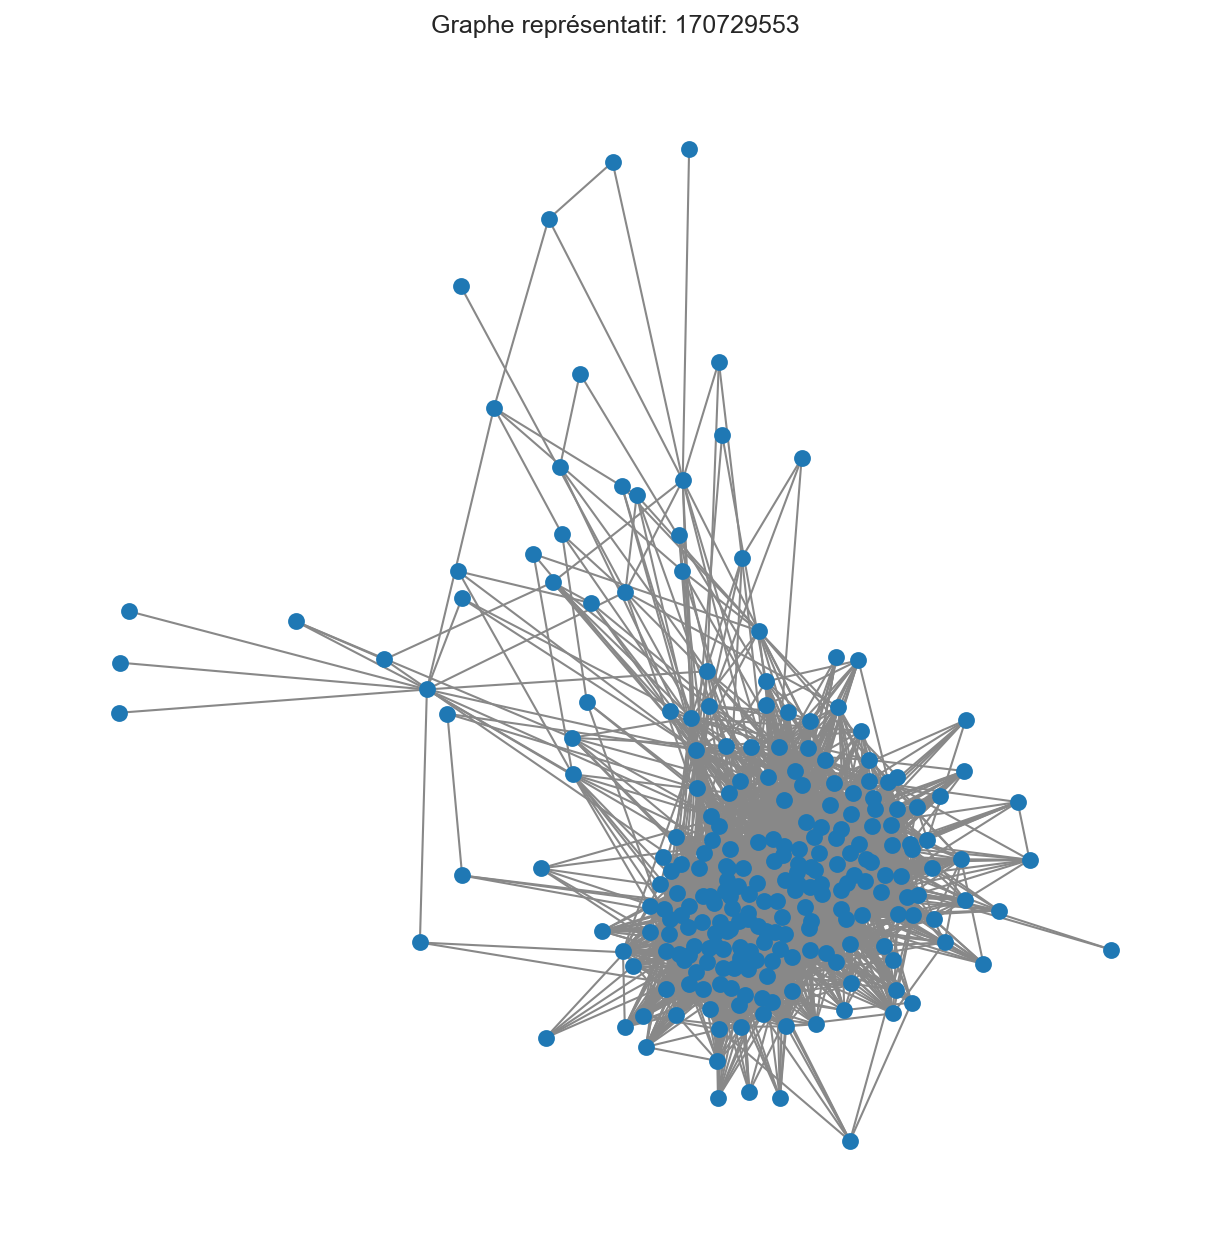

In [18]:
# Save and display the representative graph image
from IPython.display import display, Image
rep = globals().get('representative_net', None)
if rep is None:
    print('Aucun graphe représentatif sélectionné. Exécutez la cellule de sélection dabord.')
else:
    if 'graphs' not in globals() or rep not in graphs:
        print(f'Graphe {rep} introuvable dans la variable graphs.')
    else:
        Grep = graphs[rep]
        out_path = summary_dir / f'{rep}_graph.png'
        plt.figure(figsize=(8,8))
        pos = nx.spring_layout(Grep, seed=42)
        nx.draw(Grep, pos=pos, node_size=50, with_labels=False, edge_color='#888888')
        plt.title(f'Graphe représentatif: {rep}')
        plt.tight_layout()
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        print('Graphe sauvegardé sous :', out_path)
        try:
            display(Image(filename=str(out_path)))
        except Exception:
            print('Impossible dafficher limage dans cet environnement; le fichier est sauvegardé.')

## Centralités complètes

Calcul de toutes les centralités requises : Degree, Eigenvector, Closeness, Betweenness, PageRank.

In [19]:
# ============================================================================
# CALCUL DE TOUTES LES CENTRALITÉS
# ============================================================================
from IPython.display import display, Image
import time

rep = globals().get('representative_net', None)
if rep is None:
    print("Pas de graphe sélectionné.")
else:
    G = graphs[rep]
    G_undirected = G.to_undirected()

    print(f"Calcul des centralités pour le graphe {rep}...")
    print(f"Noeuds: {G.number_of_nodes()}, Arêtes: {G.number_of_edges()}")
    print("="*60)

    # 1. Degree Centrality
    print("1/5 Degree Centrality...")
    degree_centrality = nx.degree_centrality(G)
    in_degree_centrality = nx.in_degree_centrality(G)
    out_degree_centrality = nx.out_degree_centrality(G)

    # 2. Eigenvector Centrality (sur graphe non-dirigé pour convergence)
    print("2/5 Eigenvector Centrality...")
    try:
        eigenvector_centrality = nx.eigenvector_centrality(G_undirected, max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        print("   ⚠️ Eigenvector n'a pas convergé, utilisation de numpy...")
        eigenvector_centrality = nx.eigenvector_centrality_numpy(G_undirected)

    # 3. Closeness Centrality
    print("3/5 Closeness Centrality...")
    closeness_centrality = nx.closeness_centrality(G)

    # 4. Betweenness Centrality
    print("4/5 Betweenness Centrality...")
    betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

    # 5. PageRank
    print("5/5 PageRank...")
    pagerank = nx.pagerank(G, alpha=0.85)

    print("="*60)
    print("✅ Toutes les centralités calculées!")

    # Créer un DataFrame récapitulatif
    nodes_list = list(G.nodes())
    centrality_df = pd.DataFrame({
        'node': nodes_list,
        'degree': [degree_centrality[n] for n in nodes_list],
        'in_degree': [in_degree_centrality[n] for n in nodes_list],
        'out_degree': [out_degree_centrality[n] for n in nodes_list],
        'eigenvector': [eigenvector_centrality.get(n, 0) for n in nodes_list],
        'closeness': [closeness_centrality[n] for n in nodes_list],
        'betweenness': [betweenness_centrality[n] for n in nodes_list],
        'pagerank': [pagerank[n] for n in nodes_list],
    })
    centrality_df = centrality_df.set_index('node')

    # Sauvegarder
    centrality_df.to_csv(summary_dir / f'{rep}_all_centralities.csv')
    print(f"\nSauvegardé: {summary_dir}/{rep}_all_centralities.csv")

    # Afficher les top 10 pour chaque centralité
    print("\n" + "="*60)
    print("TOP 10 NoeUDS PAR CENTRALITÉ")
    print("="*60)

    for col in ['degree', 'eigenvector', 'closeness', 'betweenness', 'pagerank']:
        top10 = centrality_df[col].nlargest(10)
        print(f"\n🔹 {col.upper()}:")
        for i, (node, val) in enumerate(top10.items(), 1):
            print(f"   {i:2d}. {node}: {val:.4f}")

Calcul des centralités pour le graphe 170729553...
Noeuds: 247, Arêtes: 5629
1/5 Degree Centrality...


NetworkXNotImplemented: not implemented for undirected type

STATISTIQUES DESCRIPTIVES DES CENTRALITÉS


,degree,in_degree,out_degree,eigenvector,closeness,betweenness,pagerank
count,248.0000,248.0000,248.0000,248.0000,248.0000,248.0000,248.0000
mean,0.2689,0.1345,0.1345,0.0517,0.4016,0.0045,0.0040
std,0.2056,0.1229,0.1170,0.0369,0.1265,0.0094,0.0036
min,0.0081,0.0000,0.0000,0.0025,0.0000,0.0000,0.0007
25%,0.0891,0.0405,0.0324,0.0195,0.3738,0.0002,0.0015
50%,0.2510,0.0911,0.1215,0.0474,0.4299,0.0014,0.0029
75%,0.3806,0.1994,0.1994,0.0771,0.4709,0.0047,0.0052
max,1.0000,0.5628,1.0000,0.1755,0.6262,0.1044,0.0228



CORRÉLATION ENTRE CENTRALITÉS


,degree,eigenvector,closeness,betweenness,pagerank
degree,1.000,0.966,0.629,0.522,0.692
eigenvector,0.966,1.000,0.639,0.412,0.659
closeness,0.629,0.639,1.000,0.312,0.622
betweenness,0.522,0.412,0.312,1.000,0.482
pagerank,0.692,0.659,0.622,0.482,1.000



Sauvegardé: twitter_ego\twitter\summary_tables\170729553_centrality_correlation.png


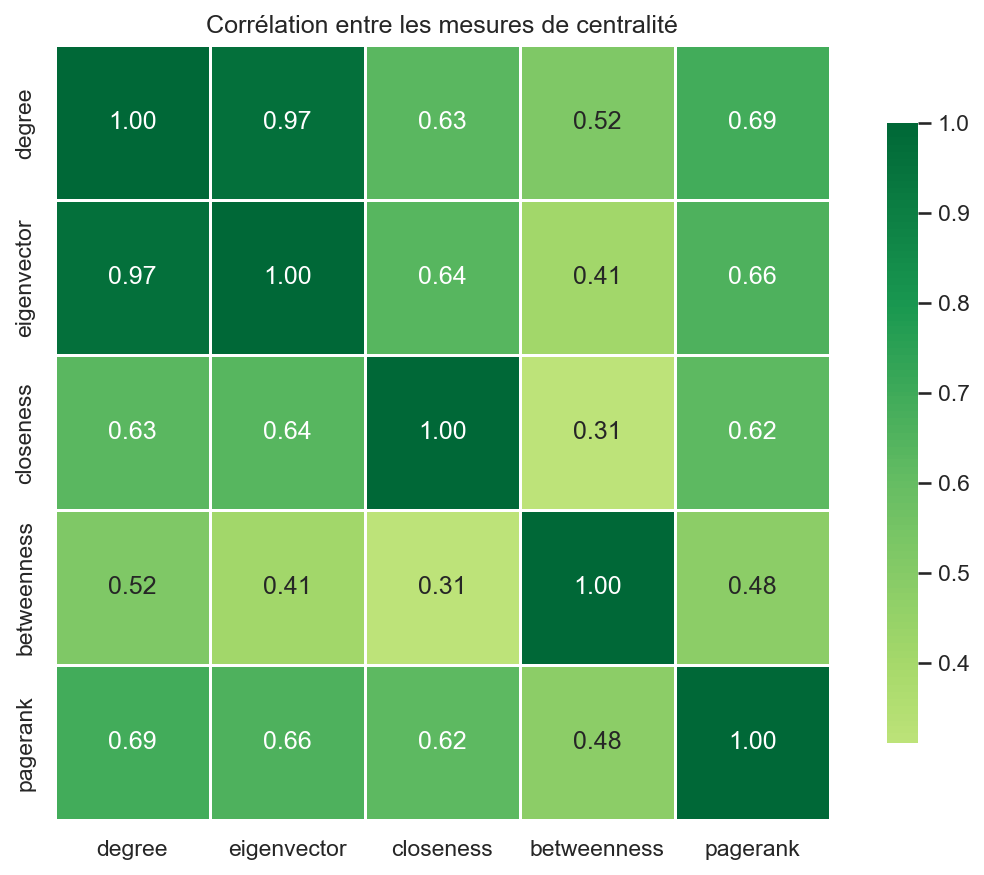

In [162]:
# ============================================================================
# TABLEAU COMPARATIF DES CENTRALITÉS
# ============================================================================

# Statistiques descriptives
print("STATISTIQUES DESCRIPTIVES DES CENTRALITÉS")
print("="*60)
display(centrality_df.describe().round(4))

# Matrice de corrélation entre centralités
print("\n" + "="*60)
print("CORRÉLATION ENTRE CENTRALITÉS")
print("="*60)
corr_centralities = centrality_df[['degree', 'eigenvector', 'closeness', 'betweenness', 'pagerank']].corr()
display(corr_centralities.round(3))

# Heatmap des corrélations
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_centralities, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Corrélation entre les mesures de centralité')
plt.tight_layout()
out_path = summary_dir / f'{rep}_centrality_correlation.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nSauvegardé: {out_path}")
display(Image(filename=str(out_path)))

# Sauvegarder la matrice de corrélation
corr_centralities.to_csv(summary_dir / f'{rep}_centrality_correlation.csv')

Sauvegardé: twitter_ego\twitter\summary_tables\170729553_centralities_comparison.png


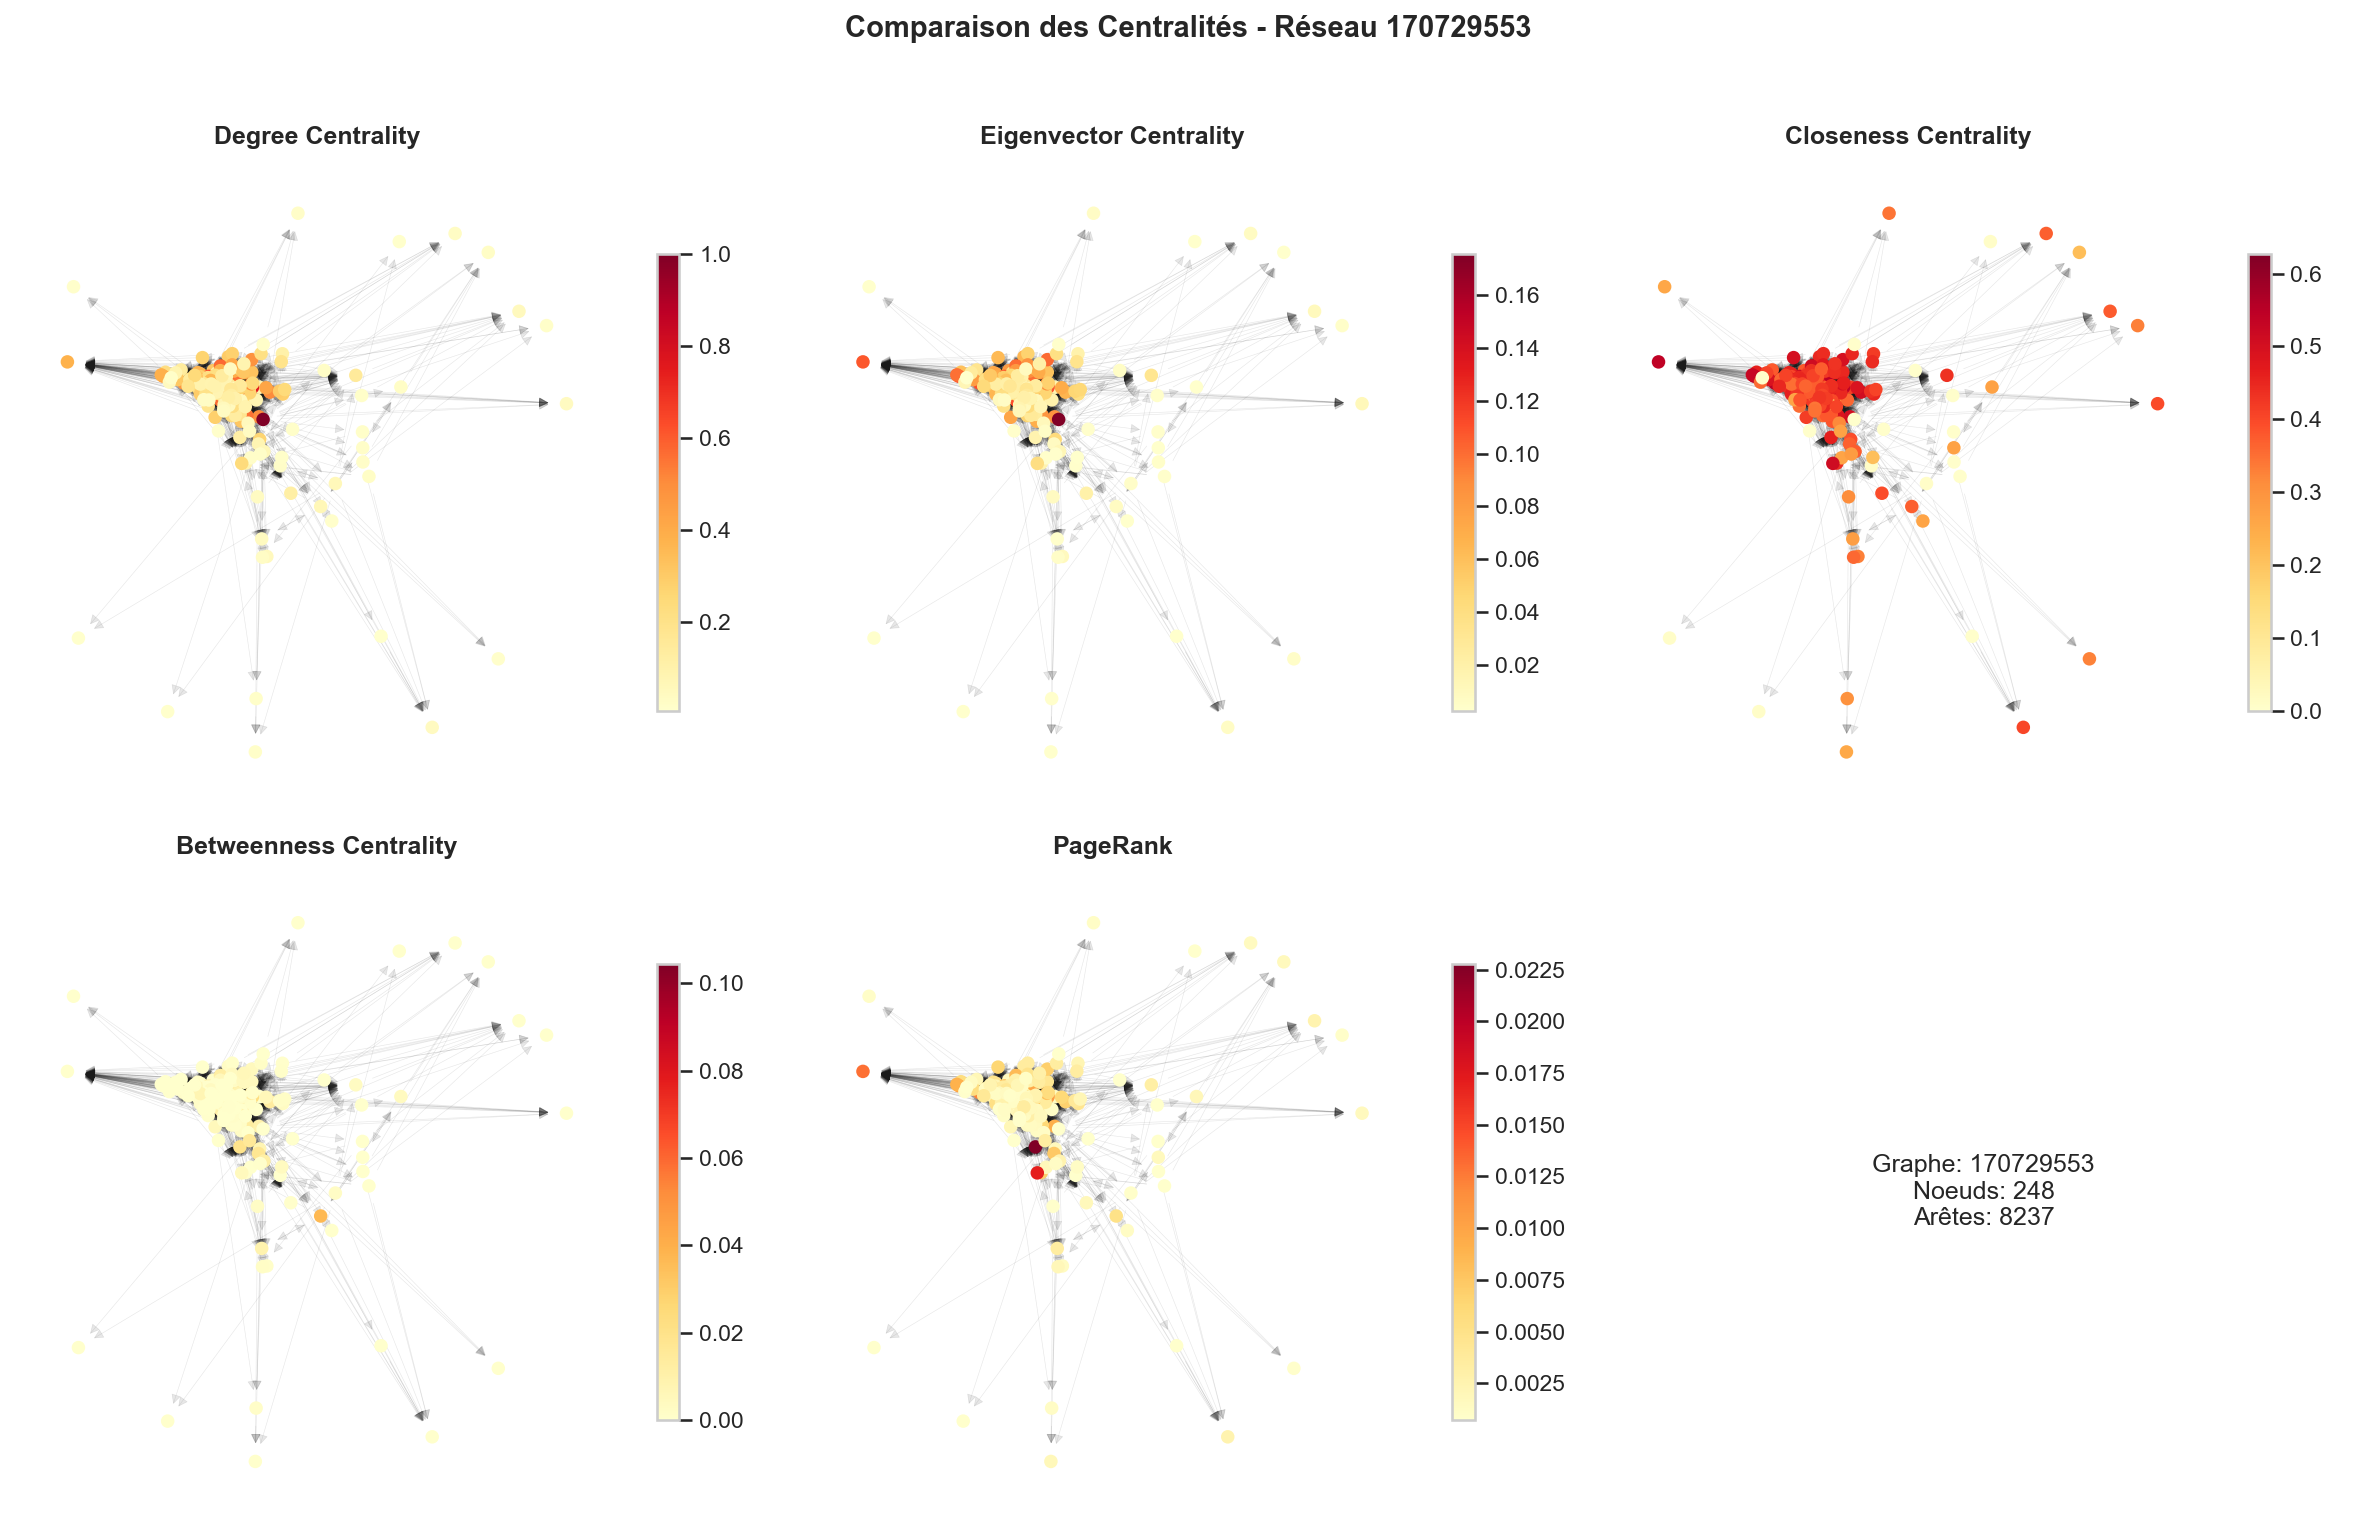

In [163]:
# ============================================================================
# VISUALISATION COMPARATIVE DES CENTRALITÉS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pos = nx.spring_layout(G, seed=42)

centralities = [
    ('degree', degree_centrality, 'Degree Centrality'),
    ('eigenvector', {n: eigenvector_centrality.get(n, 0) for n in G.nodes()}, 'Eigenvector Centrality'),
    ('closeness', closeness_centrality, 'Closeness Centrality'),
    ('betweenness', betweenness_centrality, 'Betweenness Centrality'),
    ('pagerank', pagerank, 'PageRank'),
]

for idx, (name, cent_dict, title) in enumerate(centralities):
    ax = axes[idx // 3, idx % 3]
    values = [cent_dict[n] for n in G.nodes()]

    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=30,
        node_color=values,
        cmap=plt.cm.YlOrRd,
        vmin=min(values),
        vmax=max(values)
    )
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, width=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(nodes, ax=ax, shrink=0.7)

# Cacher le 6ème subplot (vide)
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5, f'Graphe: {rep}\nNoeuds: {G.number_of_nodes()}\nArêtes: {G.number_of_edges()}',
                ha='center', va='center', fontsize=12, transform=axes[1, 2].transAxes)

plt.suptitle(f'Comparaison des Centralités - Réseau {rep}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
from IPython.display import display, Image

out_path = summary_dir / f'{rep}_centralities_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Sauvegardé: {out_path}")
display(Image(filename=str(out_path)))

### Interprétation des centralités

| Centralité | Signification | Noeuds importants selon cette mesure |
|------------|---------------|-------------------------------------|
| **Degree** | Nombre de connexions directes | Noeuds les plus connectés (hubs) |
| **Eigenvector** | Connexion à des noeuds eux-mêmes bien connectés | Noeuds influents par association |
| **Closeness** | Proximité moyenne à tous les autres noeuds | Noeuds centraux pour la diffusion rapide |
| **Betweenness** | Fréquence sur les plus courts chemins | Noeuds "ponts" entre communautés |
| **PageRank** | Importance récursive (liens entrants pondérés) | Noeuds vers lesquels pointent des noeuds importants |

**Observations attendues :**
- Forte corrélation Degree ↔ Eigenvector (les hubs sont souvent connectés entre eux)
- Betweenness peut identifier des noeuds moins connectés mais structurellement critiques
- PageRank et Eigenvector capturent l'influence indirecte

Graphe sauvegardé sous : twitter_ego\twitter\summary_tables\170729553_pagerank_noego.png


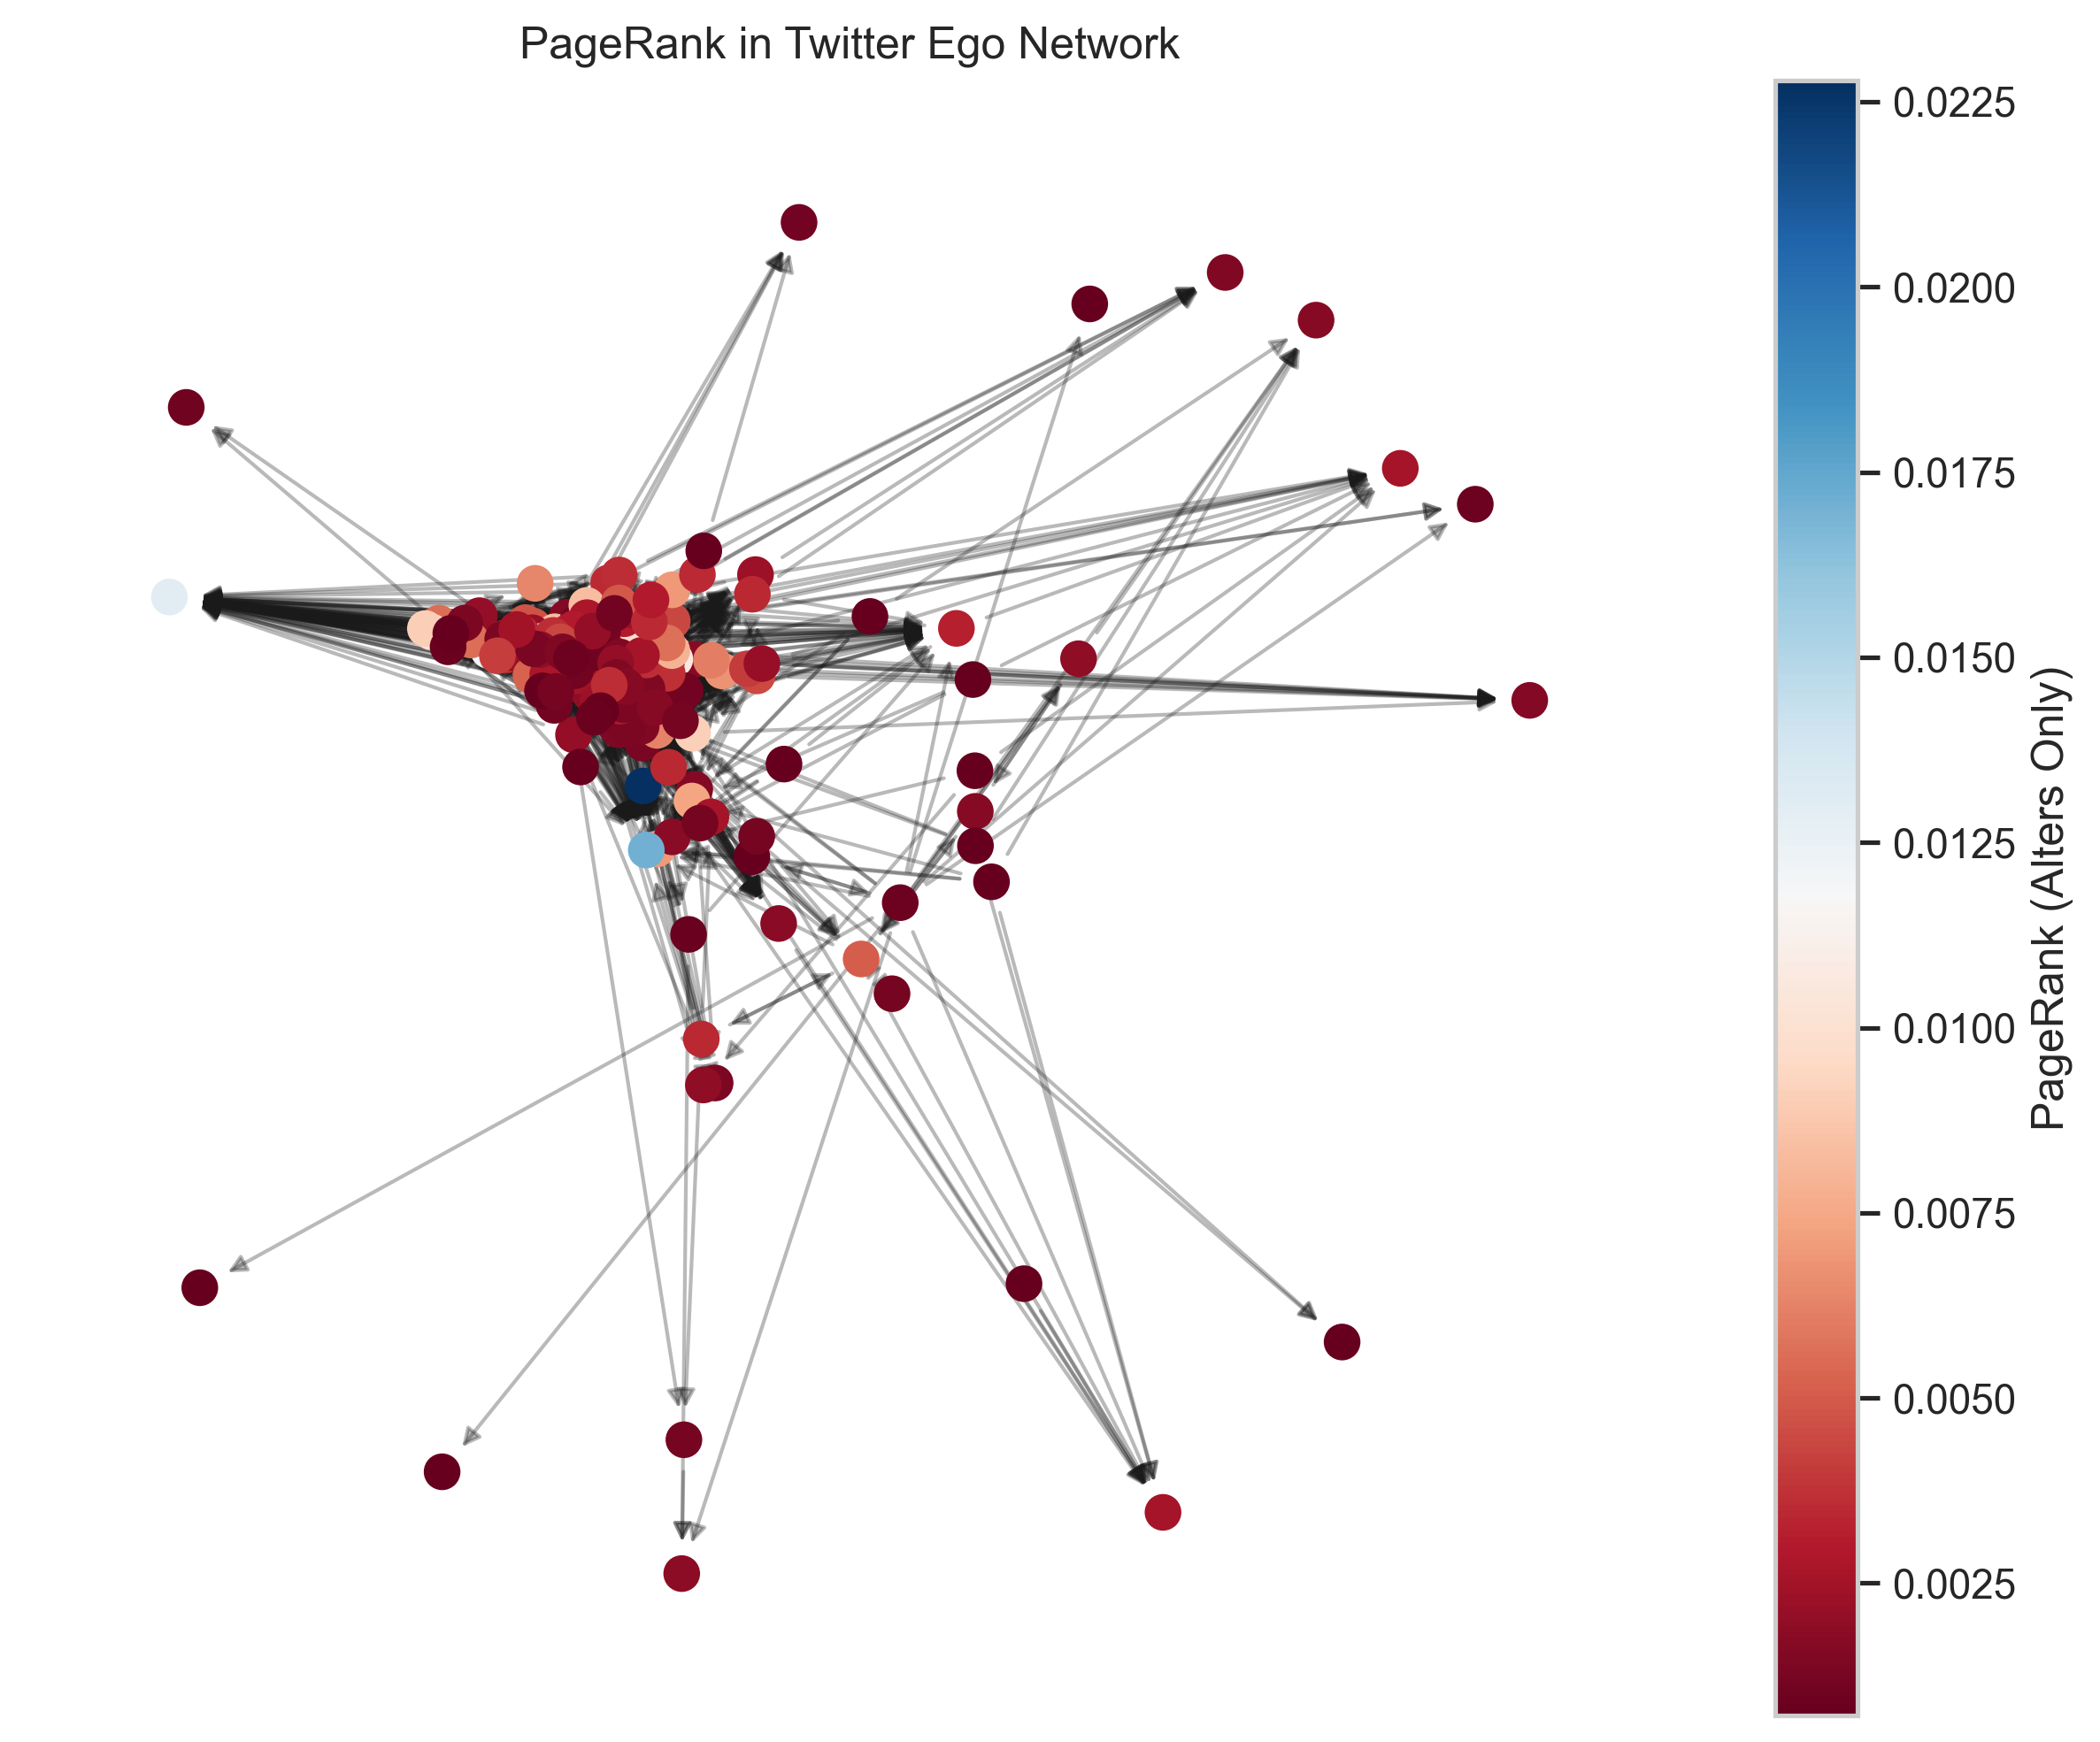

In [164]:
#page rank

import matplotlib.pyplot as plt

ego = rep

G_no_ego = G.copy()
G_no_ego.remove_node(ego)

pagerank_alters = nx.pagerank(G_no_ego, alpha=0.85)

out_path = summary_dir / f"{rep}_pagerank_noego.png"


values = list(pagerank_alters.values())

pos = nx.spring_layout(G_no_ego, seed=42)

plt.figure(figsize=(10, 8))
nodes = nx.draw_networkx_nodes(
    G_no_ego,
    pos,
    node_color=values,
    cmap=plt.cm.RdBu,
    node_size=80
)

nx.draw_networkx_edges(G_no_ego, pos, alpha=0.3)
plt.colorbar(nodes, label="PageRank (Alters Only)")
plt.title("PageRank in Twitter Ego Network")
plt.axis("off")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print('Graphe sauvegardé sous :', out_path)

display(Image(filename=str(out_path)))


Graphe sauvegardé sous : twitter_ego\twitter\summary_tables\170729553_louvain_communities_noego.png


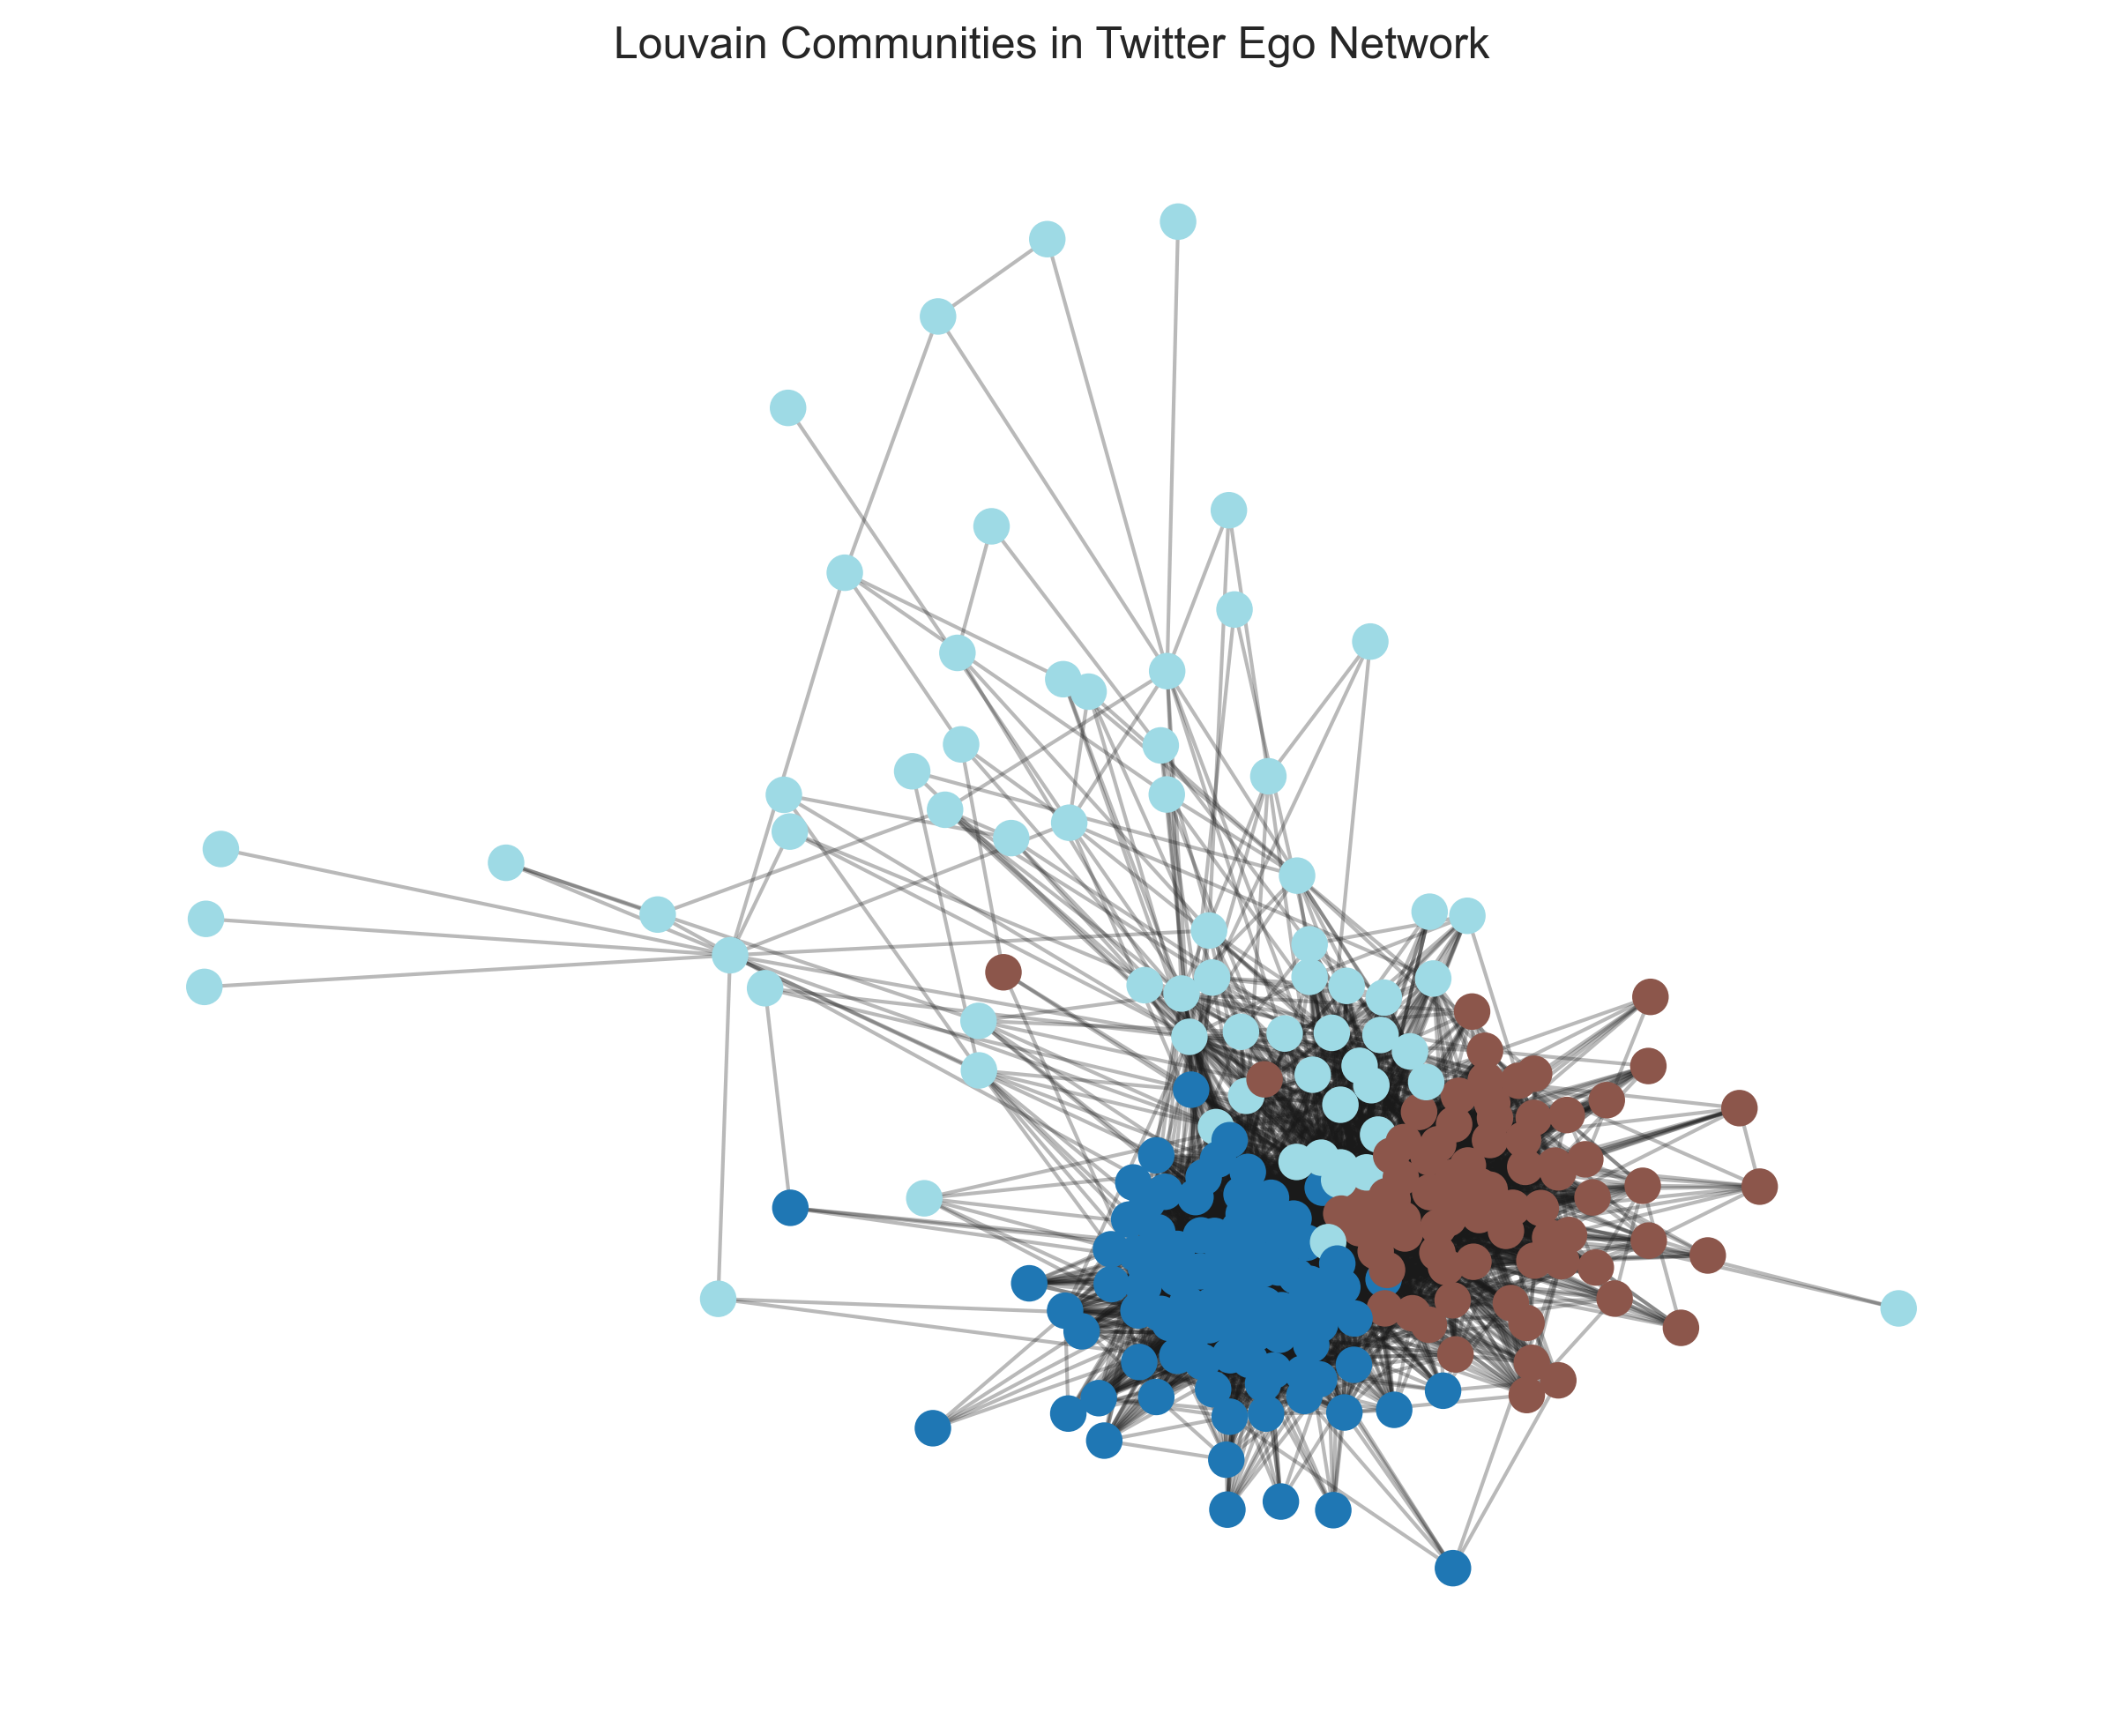

In [165]:
#louvain community detection
#only on undirected graph
import community.community_louvain as community_louvain

G_undirected = G_no_ego.to_undirected()
partition = community_louvain.best_partition(G_undirected)

# Get community labels
communities = list(partition.values())

pos = nx.spring_layout(G_undirected, seed=42)

plt.figure(figsize=(10, 8))

nodes = nx.draw_networkx_nodes(
    G_undirected,
    pos,
    node_color=communities,
    cmap=plt.cm.tab20,
    node_size=80
)

nx.draw_networkx_edges(G_undirected, pos, alpha=0.3)

out_path = summary_dir / f"{rep}_louvain_communities_noego.png"

plt.title("Louvain Communities in Twitter Ego Network")
plt.axis("off")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print('Graphe sauvegardé sous :', out_path)

display(Image(filename=str(out_path)))


## Détection de communautés : Girvan-Newman

Algorithme divisif : supprime itérativement les arêtes à haute betweenness pour révéler la structure communautaire.

In [166]:
# ============================================================================
# GIRVAN-NEWMAN COMMUNITY DETECTION
# ============================================================================
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import itertools

print("Détection de communautés avec Girvan-Newman...")
print("="*60)

# Utiliser le graphe non dirigé sans l'ego
G_gn = G_undirected.copy()

# Girvan-Newman retourne un générateur de partitions
# On va chercher la partition qui maximise la modularité
gn_generator = girvan_newman(G_gn)

# Limiter à un nombre raisonnable d'itérations pour éviter trop de calcul
# On teste jusqu'à 15 communautés max
max_communities = min(15, G_gn.number_of_nodes() // 5)
best_modularity = -1
best_partition_gn = None
best_k = 0

print(f"Recherche de la meilleure partition (max {max_communities} communautés)...")

for i, communities_tuple in enumerate(itertools.islice(gn_generator, max_communities - 1)):
    # communities_tuple est un tuple de frozensets
    communities_list = [set(c) for c in communities_tuple]
    k = len(communities_list)

    # Calculer la modularité
    mod = modularity(G_gn, communities_list)

    if mod > best_modularity:
        best_modularity = mod
        best_partition_gn = communities_list
        best_k = k

    if (i + 1) % 3 == 0:
        print(f"  Itération {i+1}: {k} communautés, modularité = {mod:.4f}")

print("="*60)
print(f"✅ Meilleure partition trouvée: {best_k} communautés")
print(f"   Modularité Girvan-Newman: {best_modularity:.4f}")

# Créer un dictionnaire node -> community pour comparaison avec Louvain
partition_gn = {}
for idx, community in enumerate(best_partition_gn):
    for node in community:
        partition_gn[node] = idx

# Statistiques des communautés
community_sizes_gn = [len(c) for c in best_partition_gn]
print(f"   Tailles des communautés: {sorted(community_sizes_gn, reverse=True)}")

# Sauvegarder
gn_df = pd.DataFrame({'node': list(partition_gn.keys()), 'community_gn': list(partition_gn.values())})
gn_df.to_csv(summary_dir / f'{rep}_girvan_newman_communities.csv', index=False)
print(f"\nSauvegardé: {summary_dir}/{rep}_girvan_newman_communities.csv")

Détection de communautés avec Girvan-Newman...
Recherche de la meilleure partition (max 15 communautés)...
  Itération 3: 4 communautés, modularité = 0.0058
  Itération 6: 7 communautés, modularité = 0.0072
  Itération 9: 10 communautés, modularité = 0.0075
  Itération 12: 13 communautés, modularité = 0.0077
✅ Meilleure partition trouvée: 14 communautés
   Modularité Girvan-Newman: 0.0079
   Tailles des communautés: [218, 12, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]

Sauvegardé: twitter_ego\twitter\summary_tables/170729553_girvan_newman_communities.csv


Sauvegardé: twitter_ego\twitter\summary_tables\170729553_girvan_newman.png


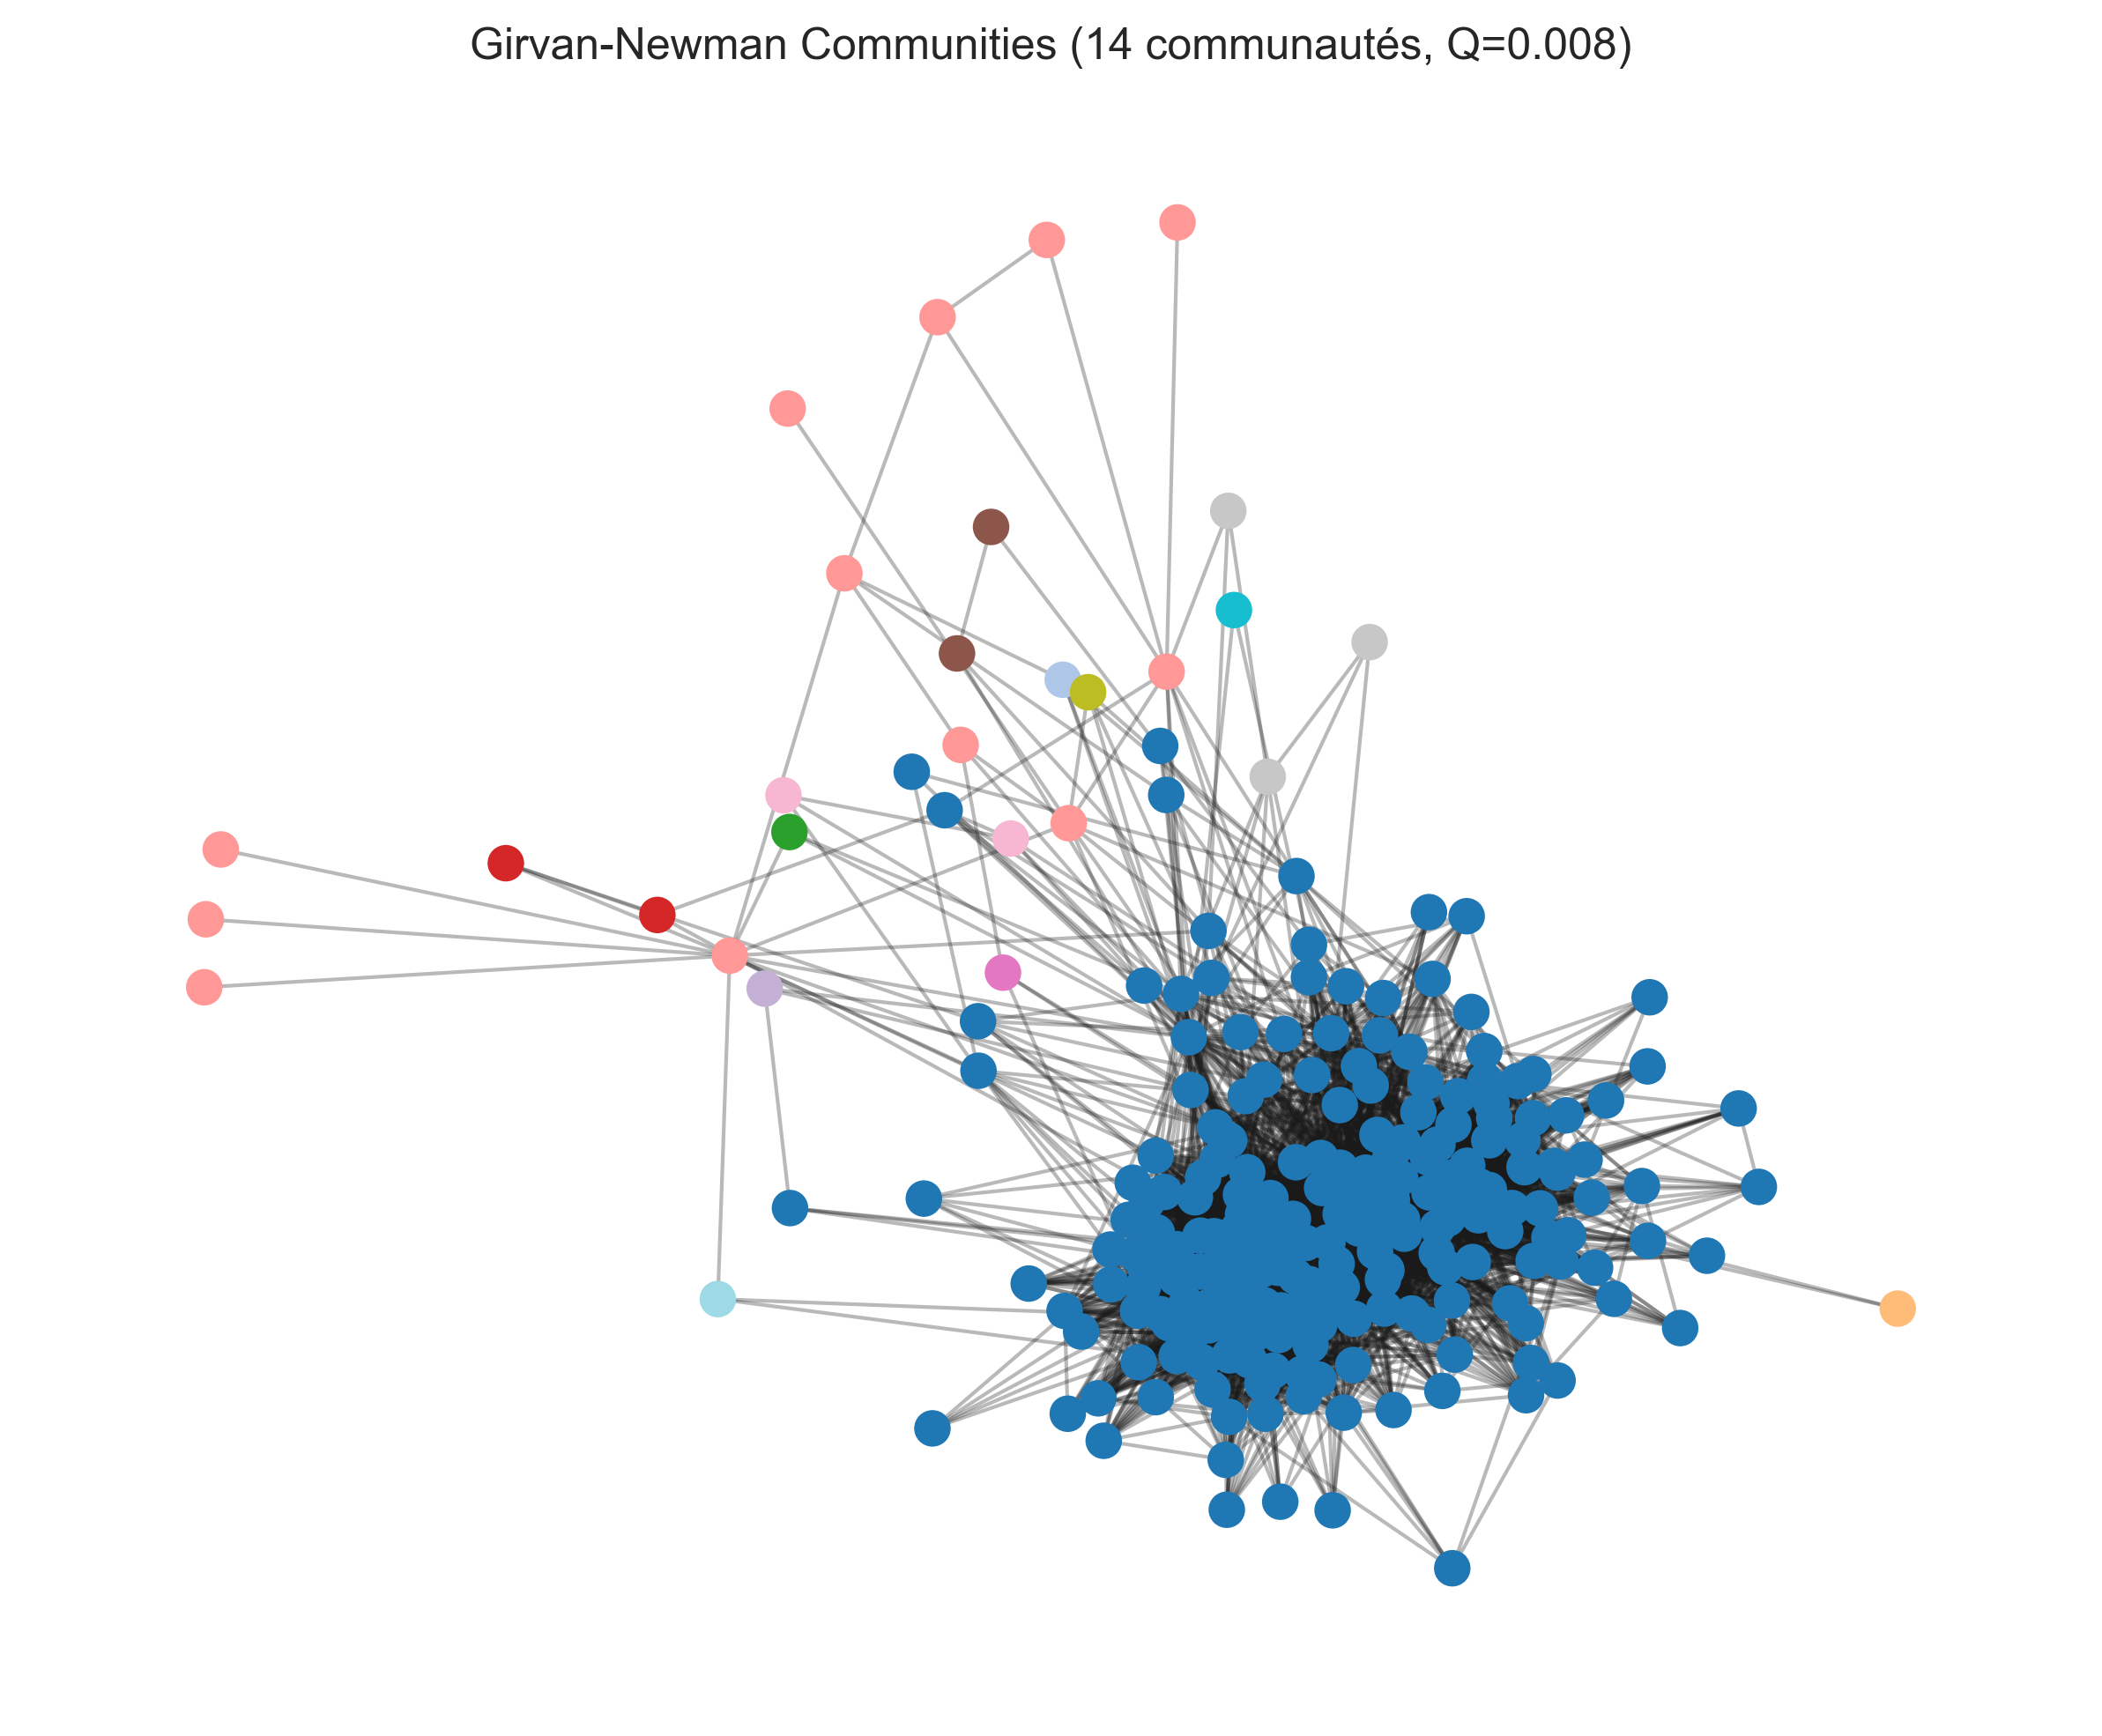

In [167]:
# ============================================================================
# VISUALISATION GIRVAN-NEWMAN
# ============================================================================

communities_gn = [partition_gn[n] for n in G_undirected.nodes()]

plt.figure(figsize=(10, 8))
nodes = nx.draw_networkx_nodes(
    G_undirected,
    pos,
    node_color=communities_gn,
    cmap=plt.cm.tab20,
    node_size=80
)
nx.draw_networkx_edges(G_undirected, pos, alpha=0.3)

out_path = summary_dir / f'{rep}_girvan_newman.png'
plt.title(f"Girvan-Newman Communities ({best_k} communautés, Q={best_modularity:.3f})")
plt.axis("off")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"Sauvegardé: {out_path}")
display(Image(filename=str(out_path)))

COMPARAISON DES ALGORITHMES DE DÉTECTION DE COMMUNAUTÉS


,Algorithme,Type,Nb communautés,Modularité,Complexité
0,Louvain,Agglomératif,3,0.253669,O(n log n)
1,Girvan-Newman,Divisif,14,0.007878,O(m² n)



Sauvegardé: twitter_ego\twitter\summary_tables\170729553_community_comparison.png


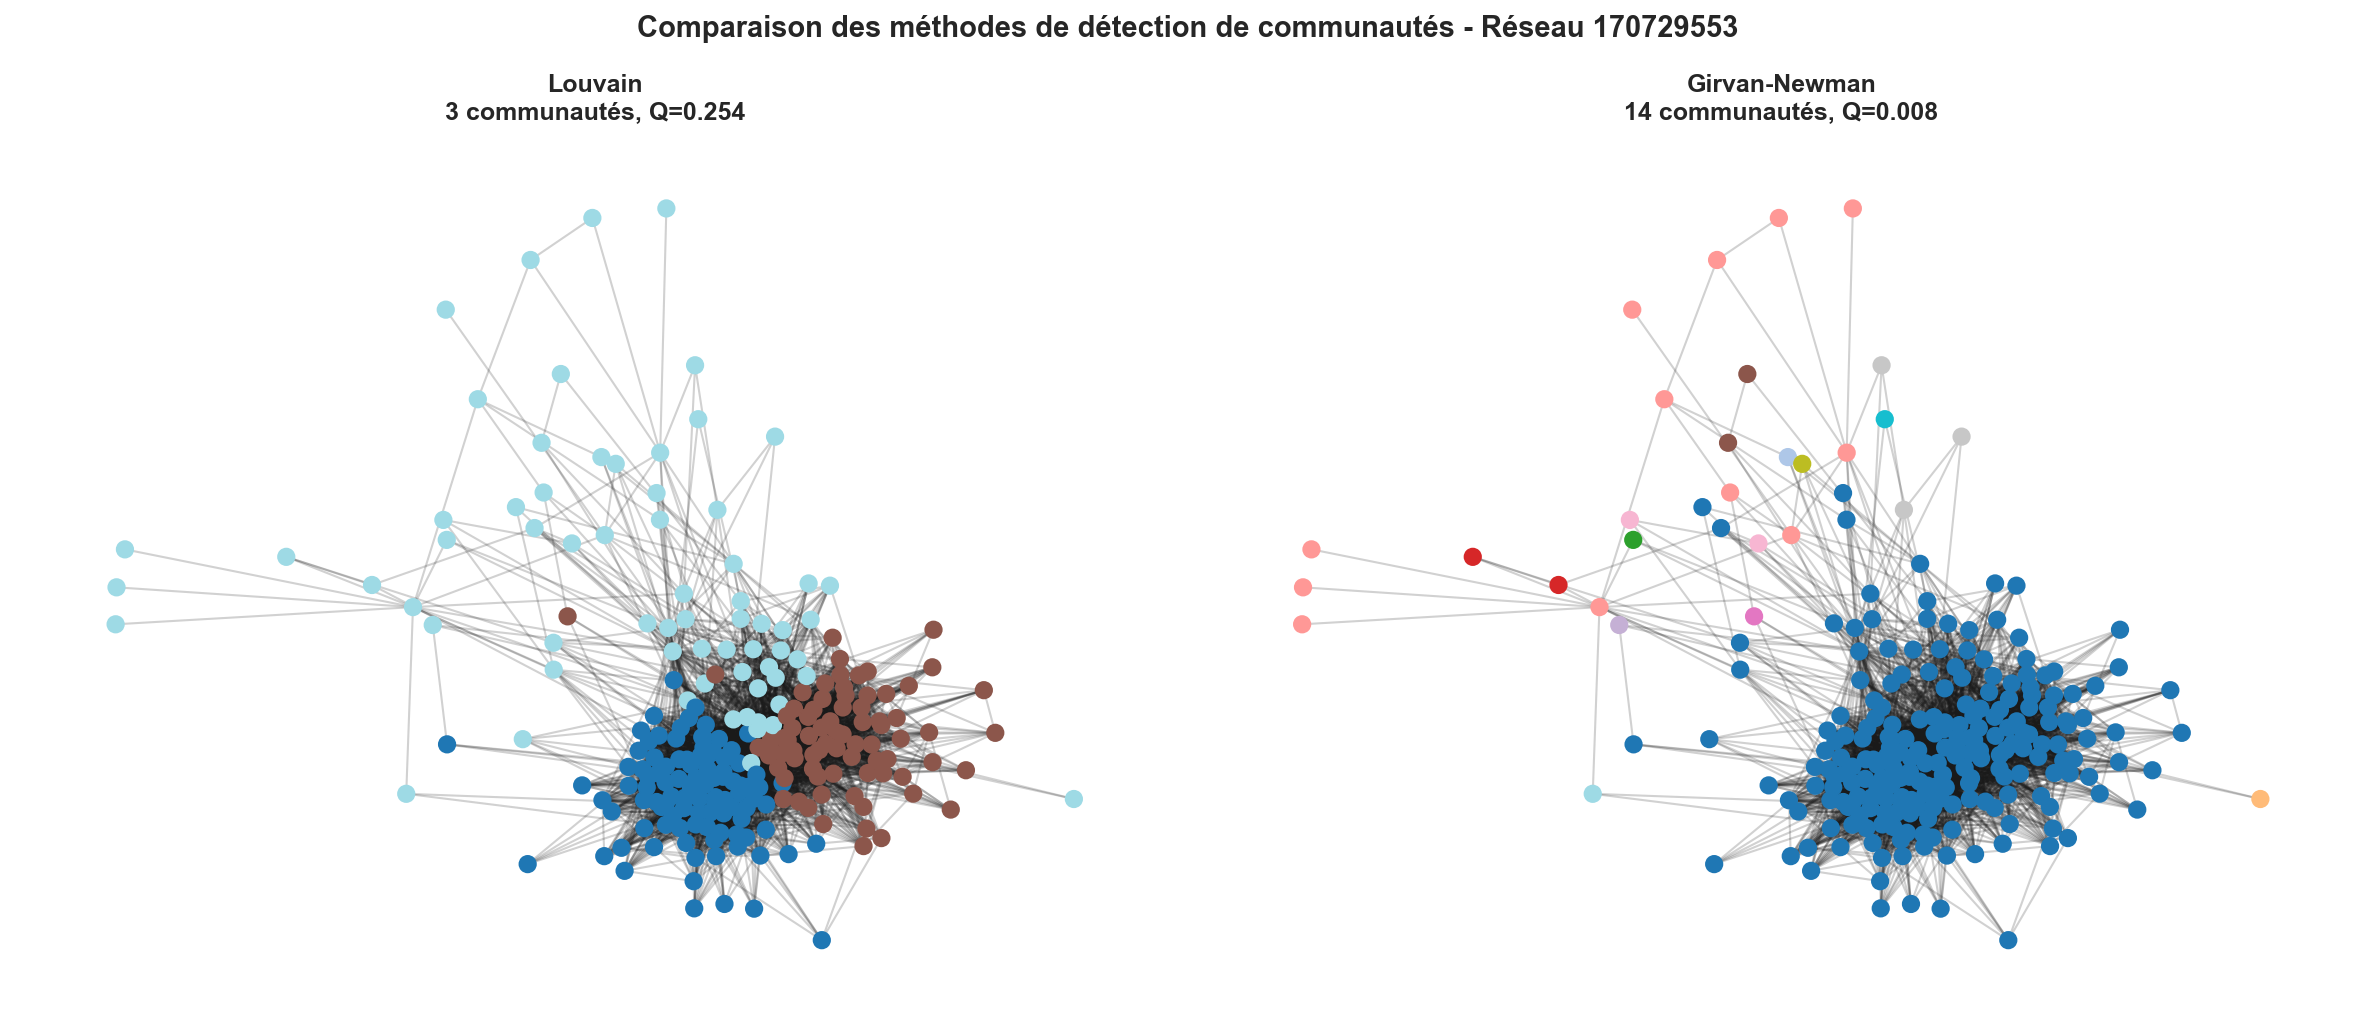

In [168]:
# ============================================================================
# COMPARAISON LOUVAIN vs GIRVAN-NEWMAN
# ============================================================================

# Calculer la modularité de Louvain
louvain_communities = {}
for node, comm in partition.items():
    if comm not in louvain_communities:
        louvain_communities[comm] = set()
    louvain_communities[comm].add(node)
louvain_communities_list = list(louvain_communities.values())
modularity_louvain = modularity(G_undirected, louvain_communities_list)

print("="*60)
print("COMPARAISON DES ALGORITHMES DE DÉTECTION DE COMMUNAUTÉS")
print("="*60)

comparison_data = {
    'Algorithme': ['Louvain', 'Girvan-Newman'],
    'Type': ['Agglomératif', 'Divisif'],
    'Nb communautés': [len(set(partition.values())), best_k],
    'Modularité': [modularity_louvain, best_modularity],
    'Complexité': ['O(n log n)', 'O(m² n)'],
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Sauvegarder
comparison_df.to_csv(summary_dir / f'{rep}_community_comparison.csv', index=False)

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Louvain
ax1 = axes[0]
communities_louvain = [partition[n] for n in G_undirected.nodes()]
nx.draw_networkx_nodes(G_undirected, pos, ax=ax1, node_color=communities_louvain,
                       cmap=plt.cm.tab20, node_size=60)
nx.draw_networkx_edges(G_undirected, pos, ax=ax1, alpha=0.2)
ax1.set_title(f'Louvain\n{len(set(partition.values()))} communautés, Q={modularity_louvain:.3f}',
              fontsize=12, fontweight='bold')
ax1.axis('off')

# Girvan-Newman
ax2 = axes[1]
nx.draw_networkx_nodes(G_undirected, pos, ax=ax2, node_color=communities_gn,
                       cmap=plt.cm.tab20, node_size=60)
nx.draw_networkx_edges(G_undirected, pos, ax=ax2, alpha=0.2)
ax2.set_title(f'Girvan-Newman\n{best_k} communautés, Q={best_modularity:.3f}',
              fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle(f'Comparaison des méthodes de détection de communautés - Réseau {rep}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = summary_dir / f'{rep}_community_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nSauvegardé: {out_path}")
display(Image(filename=str(out_path)))

### Interprétation : Louvain vs Girvan-Newman

| Aspect | Louvain | Girvan-Newman |
|--------|---------|---------------|
| **Approche** | Agglomérative (fusion bottom-up) | Divisive (suppression d'arêtes top-down) |
| **Optimisation** | Maximise la modularité localement | Supprime les arêtes à haute betweenness |
| **Vitesse** | Rapide O(n log n) | Lent O(m² n) |
| **Résultat** | Nombre de communautés automatique | Contrôle du nombre via itérations |

**Observations :**
- Louvain tend à trouver plus de petites communautés
- Girvan-Newman peut révéler une structure hiérarchique
- La modularité permet de comparer objectivement les deux partitions

## Métriques de qualité des communautés

Évaluation des partitions avec modularité et conductance.

In [169]:
# ============================================================================
# MÉTRIQUES DE QUALITÉ DES COMMUNAUTÉS
# ============================================================================
from networkx.algorithms.community.quality import modularity

# Fonctions de métriques (compatibilité avec différentes versions de NetworkX)
def compute_coverage(G, communities_list):
    """
    Coverage = fraction des arêtes intra-communauté.
    """
    intra_edges = 0
    for community in communities_list:
        subgraph = G.subgraph(community)
        intra_edges += subgraph.number_of_edges()
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0.0

def compute_performance(G, communities_list):
    """
    Performance = fraction des paires correctement classées
    (intra-communauté connectées + inter-communauté non connectées).
    """
    n = G.number_of_nodes()
    total_pairs = n * (n - 1) / 2
    if total_pairs == 0:
        return 0.0

    # Créer un mapping node -> community
    node_to_comm = {}
    for idx, comm in enumerate(communities_list):
        for node in comm:
            node_to_comm[node] = idx

    # Compter les paires correctes
    correct = 0
    nodes = list(G.nodes())
    edges_set = set(G.edges())

    for i, u in enumerate(nodes):
        for v in nodes[i+1:]:
            same_comm = node_to_comm.get(u) == node_to_comm.get(v)
            connected = (u, v) in edges_set or (v, u) in edges_set
            if (same_comm and connected) or (not same_comm and not connected):
                correct += 1

    return correct / total_pairs

def compute_conductance(G, communities_list):
    """
    Calcule la conductance moyenne des communautés.
    Conductance = edges sortant de la communauté / min(volume interne, volume externe)
    Plus la conductance est faible, meilleure est la communauté.
    """
    conductances = []
    for community in communities_list:
        if len(community) == 0 or len(community) == G.number_of_nodes():
            continue

        # Calculer les arêtes internes et externes
        boundary_edges = 0

        for node in community:
            for neighbor in G.neighbors(node):
                if neighbor not in community:
                    boundary_edges += 1

        # Volume = somme des degrés des noeuds dans la communauté
        volume = sum(G.degree(n) for n in community)

        # Conductance
        if volume > 0 and boundary_edges > 0:
            conductance = boundary_edges / volume
            conductances.append(conductance)

    return np.mean(conductances) if conductances else 0.0

print("="*60)
print("MÉTRIQUES DE QUALITÉ DES COMMUNAUTÉS")
print("="*60)

# Préparer les listes de communautés
louvain_communities_list = list(louvain_communities.values())
gn_communities_list = best_partition_gn

# Calculer les métriques
metrics_data = {
    'Métrique': [],
    'Louvain': [],
    'Girvan-Newman': [],
    'Meilleur': []
}

# 1. Modularité
mod_louvain = modularity(G_undirected, louvain_communities_list)
mod_gn = modularity(G_undirected, gn_communities_list)
metrics_data['Métrique'].append('Modularité (Q)')
metrics_data['Louvain'].append(f'{mod_louvain:.4f}')
metrics_data['Girvan-Newman'].append(f'{mod_gn:.4f}')
metrics_data['Meilleur'].append('Louvain' if mod_louvain > mod_gn else 'Girvan-Newman')

# 2. Coverage (fraction des arêtes intra-communauté)
cov_louvain = compute_coverage(G_undirected, louvain_communities_list)
cov_gn = compute_coverage(G_undirected, gn_communities_list)
metrics_data['Métrique'].append('Coverage')
metrics_data['Louvain'].append(f'{cov_louvain:.4f}')
metrics_data['Girvan-Newman'].append(f'{cov_gn:.4f}')
metrics_data['Meilleur'].append('Louvain' if cov_louvain > cov_gn else 'Girvan-Newman')

# 3. Performance (fraction des paires correctement classées)
print("Calcul de la performance (peut prendre quelques secondes)...")
perf_louvain = compute_performance(G_undirected, louvain_communities_list)
perf_gn = compute_performance(G_undirected, gn_communities_list)
metrics_data['Métrique'].append('Performance')
metrics_data['Louvain'].append(f'{perf_louvain:.4f}')
metrics_data['Girvan-Newman'].append(f'{perf_gn:.4f}')
metrics_data['Meilleur'].append('Louvain' if perf_louvain > perf_gn else 'Girvan-Newman')

# 4. Conductance moyenne (plus faible = meilleur)
cond_louvain = compute_conductance(G_undirected, louvain_communities_list)
cond_gn = compute_conductance(G_undirected, gn_communities_list)
metrics_data['Métrique'].append('Conductance (↓)')
metrics_data['Louvain'].append(f'{cond_louvain:.4f}')
metrics_data['Girvan-Newman'].append(f'{cond_gn:.4f}')
metrics_data['Meilleur'].append('Louvain' if cond_louvain < cond_gn else 'Girvan-Newman')

# 5. Nombre de communautés
n_comm_louvain = len(louvain_communities_list)
n_comm_gn = len(gn_communities_list)
metrics_data['Métrique'].append('Nb communautés')
metrics_data['Louvain'].append(str(n_comm_louvain))
metrics_data['Girvan-Newman'].append(str(n_comm_gn))
metrics_data['Meilleur'].append('-')

# 6. Taille moyenne des communautés
avg_size_louvain = np.mean([len(c) for c in louvain_communities_list])
avg_size_gn = np.mean([len(c) for c in gn_communities_list])
metrics_data['Métrique'].append('Taille moyenne')
metrics_data['Louvain'].append(f'{avg_size_louvain:.1f}')
metrics_data['Girvan-Newman'].append(f'{avg_size_gn:.1f}')
metrics_data['Meilleur'].append('-')

# Afficher le tableau
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

# Sauvegarder
metrics_df.to_csv(summary_dir / f'{rep}_community_quality_metrics.csv', index=False)
print(f"\nSauvegardé: {summary_dir}/{rep}_community_quality_metrics.csv")

MÉTRIQUES DE QUALITÉ DES COMMUNAUTÉS
Calcul de la performance (peut prendre quelques secondes)...


,Métrique,Louvain,Girvan-Newman,Meilleur
0,Modularité (Q),0.2537,0.0079,Louvain
1,Coverage,0.6660,0.9888,Girvan-Newman
2,Performance,0.7204,0.4002,Louvain
3,Conductance (↓),0.4022,0.7964,Louvain
4,Nb communautés,3,14,-
5,Taille moyenne,82.3,17.6,-



Sauvegardé: twitter_ego\twitter\summary_tables/170729553_community_quality_metrics.csv


### Interprétation des métriques

| Métrique | Description | Valeur idéale |
|----------|-------------|---------------|
| **Modularité (Q)** | Densité des connexions intra-communauté vs inter-communauté | Proche de 1 (>0.3 = significatif) |
| **Coverage** | Fraction des arêtes à l'intérieur des communautés | Proche de 1 |
| **Performance** | Fraction des paires de noeuds correctement classées | Proche de 1 |
| **Conductance** | Ratio arêtes sortantes / volume de la communauté | Proche de 0 (faible = bonne séparation) |

**Interprétation :**
- Une **haute modularité** indique des communautés bien définies
- Une **faible conductance** signifie que les communautés sont bien séparées (peu d'arêtes entre elles)
- Le **nombre de communautés** dépend de la granularité souhaitée

## Embeddings : Laplacian Eigenmaps

Technique de réduction de dimension basée sur la structure spectrale du graphe. Les vecteurs propres du Laplacien normalisé capturent la connectivité du graphe.

In [170]:
# ============================================================================
# LAPLACIAN EIGENMAPS
# ============================================================================
from scipy.sparse import csgraph
from scipy.linalg import eigh
from sklearn.manifold import TSNE

print("="*60)
print("LAPLACIAN EIGENMAPS")
print("="*60)

# Utiliser le graphe non dirigé (sans l'ego)
G_emb = G_undirected.copy()
nodes_emb = list(G_emb.nodes())
n_nodes = len(nodes_emb)
node_to_idx = {node: i for i, node in enumerate(nodes_emb)}

print(f"Graphe: {n_nodes} noeuds, {G_emb.number_of_edges()} arêtes")

# 1. Construire la matrice d'adjacence
A = nx.to_numpy_array(G_emb, nodelist=nodes_emb)

# 2. Matrice de degré
D = np.diag(A.sum(axis=1))

# 3. Laplacien non normalisé: L = D - A
L = D - A

# 4. Laplacien normalisé symétrique: L_sym = D^(-1/2) L D^(-1/2) = I - D^(-1/2) A D^(-1/2)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1) + 1e-10))
L_sym = np.eye(n_nodes) - D_inv_sqrt @ A @ D_inv_sqrt

# 5. Calculer les vecteurs propres (on prend les k plus petites valeurs propres non nulles)
n_components = min(16, n_nodes - 1)  # Nombre de dimensions d'embedding
print(f"Calcul de {n_components} vecteurs propres...")

eigenvalues, eigenvectors = eigh(L_sym)

# Ignorer le premier vecteur propre (valeur propre = 0, vecteur constant)
# Prendre les n_components suivants
laplacian_embeddings = eigenvectors[:, 1:n_components+1]

print(f"✅ Embeddings Laplacian Eigenmaps: shape = {laplacian_embeddings.shape}")

# Créer DataFrame des embeddings
le_columns = [f'LE_{i+1}' for i in range(laplacian_embeddings.shape[1])]
laplacian_df = pd.DataFrame(laplacian_embeddings, index=nodes_emb, columns=le_columns)

# Ajouter les communautés Louvain pour la visualisation
laplacian_df['community'] = [partition.get(n, -1) for n in nodes_emb]

# Sauvegarder
laplacian_df.to_csv(summary_dir / f'{rep}_laplacian_eigenmaps.csv')
print(f"Sauvegardé: {summary_dir}/{rep}_laplacian_eigenmaps.csv")

# Afficher les premières lignes
print("\nExtrait des embeddings:")
display(laplacian_df.head(10))

LAPLACIAN EIGENMAPS
Graphe: 247 noeuds, 5629 arêtes
Calcul de 16 vecteurs propres...
✅ Embeddings Laplacian Eigenmaps: shape = (247, 16)
Sauvegardé: twitter_ego\twitter\summary_tables/170729553_laplacian_eigenmaps.csv

Extrait des embeddings:


,LE_1,LE_2,LE_3,LE_4,LE_5,LE_6,LE_7,LE_8,LE_9,LE_10,LE_11,LE_12,LE_13,LE_14,LE_15,LE_16,community
231975020,0.018811,0.081323,-0.028456,0.000755,0.005623,0.000894,-0.005546,-0.014925,0.001178,-0.006735,-0.015020,0.011895,-0.058064,-0.026194,-0.020458,0.009229,0
14666401,0.014210,0.065121,-0.013845,0.007449,-0.005918,0.003933,-0.001659,-0.016626,-0.017724,-0.022036,-0.013606,0.011596,0.018867,-0.020651,0.069781,-0.021107,0
111164068,0.020924,0.086679,-0.031312,-0.000346,0.007037,-0.002100,-0.005971,-0.019330,0.009390,-0.008009,-0.005416,0.012000,-0.060250,-0.029917,-0.080927,0.036634,0
57986173,0.007534,-0.066078,0.013362,-0.018718,-0.004132,0.031622,0.017065,0.021178,-0.027414,0.054966,0.038915,-0.042371,0.137897,0.041382,-0.003425,-0.045005,1
60725654,0.010612,-0.000751,-0.004648,-0.008763,-0.004877,0.010675,0.010605,0.007294,-0.007235,0.009548,-0.001499,0.005008,0.022985,0.032103,-0.053923,-0.001218,0
252185621,0.014580,0.058836,-0.019942,0.000810,0.007756,-0.000273,0.006924,0.008170,0.001666,0.013697,0.022211,-0.010088,0.048037,0.053759,-0.120452,0.018522,0
155969606,0.013399,0.056051,-0.016960,-0.004759,0.004659,0.006693,0.010594,0.012180,-0.017847,0.017750,-0.008646,-0.002789,0.061241,-0.001463,0.040249,-0.031064,0
21624907,0.016430,0.045880,-0.017970,-0.007437,0.002269,0.009830,0.001660,-0.003360,-0.004193,0.016732,-0.005954,0.002034,-0.002642,0.034277,0.049178,-0.081916,0
85501252,0.018876,0.092226,-0.031717,0.003420,0.007380,-0.003474,-0.006581,-0.011896,0.007609,-0.001849,-0.011986,0.008812,-0.052763,-0.019415,0.015966,-0.073565,0
11202942,0.010252,0.056560,-0.016352,0.009417,0.027937,0.016997,-0.010569,-0.002625,-0.018597,0.025865,-0.004162,-0.013011,-0.059431,-0.085606,-0.044138,-0.047379,0


Calcul de t-SNE sur les embeddings Laplacian...
Sauvegardé: twitter_ego\twitter\summary_tables\170729553_laplacian_eigenmaps.png


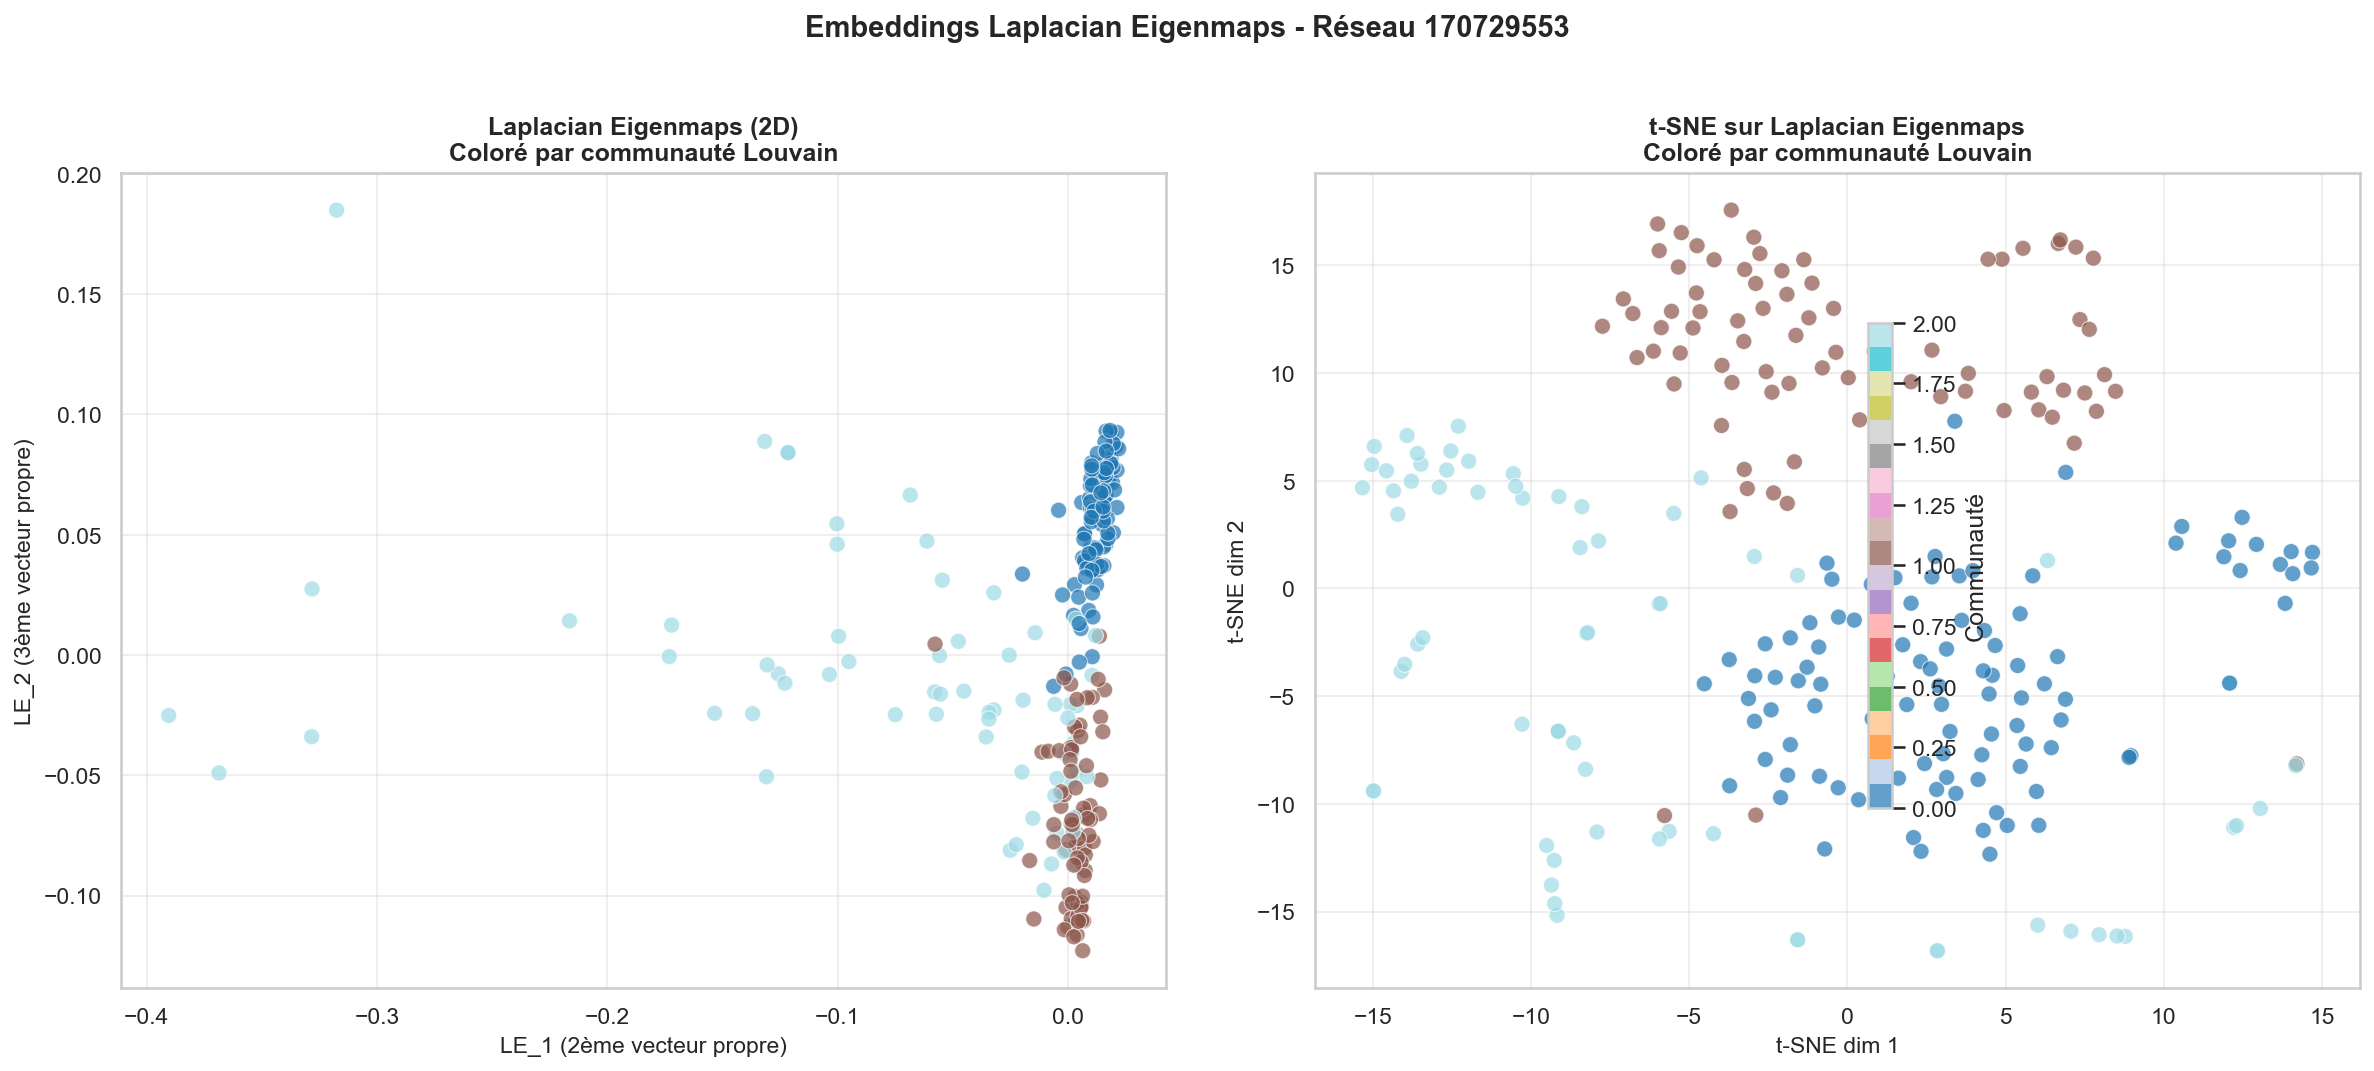

In [171]:
# ============================================================================
# VISUALISATION LAPLACIAN EIGENMAPS (2D)
# ============================================================================

# Utiliser les 2 premiers vecteurs propres pour la visualisation 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Récupérer les couleurs des communautés
community_colors = [partition.get(n, 0) for n in nodes_emb]
n_communities = len(set(community_colors))

# --- Plot 1: Laplacian Eigenmaps 2D ---
ax1 = axes[0]
scatter1 = ax1.scatter(
    laplacian_embeddings[:, 0],
    laplacian_embeddings[:, 1],
    c=community_colors,
    cmap=plt.cm.tab20,
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
ax1.set_xlabel('LE_1 (2ème vecteur propre)', fontsize=11)
ax1.set_ylabel('LE_2 (3ème vecteur propre)', fontsize=11)
ax1.set_title('Laplacian Eigenmaps (2D)\nColoré par communauté Louvain', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: t-SNE sur les embeddings Laplacian ---
print("Calcul de t-SNE sur les embeddings Laplacian...")
n_samples = n_nodes
perplexity = min(30, max(5, n_samples // 4))
perplexity = min(perplexity, n_samples - 1)

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
le_tsne = tsne.fit_transform(laplacian_embeddings)

ax2 = axes[1]
scatter2 = ax2.scatter(
    le_tsne[:, 0],
    le_tsne[:, 1],
    c=community_colors,
    cmap=plt.cm.tab20,
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
ax2.set_xlabel('t-SNE dim 1', fontsize=11)
ax2.set_ylabel('t-SNE dim 2', fontsize=11)
ax2.set_title('t-SNE sur Laplacian Eigenmaps\nColoré par communauté Louvain', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Colorbar commune
cbar = plt.colorbar(scatter2, ax=axes, shrink=0.6, label='Communauté')

plt.suptitle(f'Embeddings Laplacian Eigenmaps - Réseau {rep}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = summary_dir / f'{rep}_laplacian_eigenmaps.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Sauvegardé: {out_path}")
display(Image(filename=str(out_path)))

### Interprétation : Laplacian Eigenmaps

| Aspect | Description |
|--------|-------------|
| **Principe** | Utilise les vecteurs propres du Laplacien normalisé du graphe |
| **Propriété clé** | Les noeuds connectés ont des embeddings similaires |
| **Avantages** | Capture la structure globale, base mathématique solide |
| **Inconvénients** | Coûteux pour grands graphes, sensible aux composantes déconnectées |

**Observations :**
- Les communautés sont bien séparées dans l'espace d'embedding
- t-SNE permet de mieux visualiser les clusters en 2D
- Les vecteurs propres correspondent aux "fréquences" du graphe (du plus lisse au plus oscillant)

## Node2Vec Embeddings

Node2Vec est une méthode d'apprentissage de représentations de noeuds basée sur des marches aléatoires biaisées. Elle permet de capturer à la fois la structure locale (homophilie) et globale (équivalence structurelle) du graphe grâce aux paramètres `p` et `q`.

| Paramètre | Description |
|-----------|-------------|
| **p** | Contrôle la probabilité de revenir au noeud précédent (BFS-like si p élevé) |
| **q** | Contrôle l'exploration vers des noeuds éloignés (DFS-like si q faible) |
| **dimensions** | Taille du vecteur d'embedding |
| **walk_length** | Longueur de chaque marche aléatoire |
| **num_walks** | Nombre de marches par noeud |

In [172]:
# ============================================================================
# NODE2VEC EMBEDDINGS
# ============================================================================

from node2vec import Node2Vec

# Utiliser le graphe représentatif
G_rep = graphs[rep]
G_undirected = G_rep.to_undirected()

print(f"Calcul des embeddings Node2Vec pour le réseau {rep}")
print(f"Nombre de noeuds: {G_undirected.number_of_nodes()}")
print(f"Nombre d'arêtes: {G_undirected.number_of_edges()}")

# Paramètres Node2Vec
DIMENSIONS = 64      # Dimension des embeddings
WALK_LENGTH = 30     # Longueur des marches aléatoires
NUM_WALKS = 200      # Nombre de marches par noeud
P = 1                # Paramètre de retour (1 = neutre)
Q = 1                # Paramètre in-out (1 = neutre, <1 = DFS-like, >1 = BFS-like)
WORKERS = 1          # Nombre de threads

# Créer le modèle Node2Vec
node2vec = Node2Vec(
    G_undirected,
    dimensions=DIMENSIONS,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P,
    q=Q,
    workers=WORKERS,
    quiet=False
)

# Entraîner le modèle Word2Vec sur les marches
print("\nEntraînement du modèle Word2Vec sur les marches aléatoires...")
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Extraire les embeddings
node2vec_embeddings = np.array([model.wv[str(node)] for node in G_undirected.nodes()])
nodes_n2v = list(G_undirected.nodes())

print(f"\nDimension des embeddings: {node2vec_embeddings.shape}")

# Créer un DataFrame
node2vec_df = pd.DataFrame(
    node2vec_embeddings,
    index=nodes_n2v,
    columns=[f'N2V_{i}' for i in range(DIMENSIONS)]
)
node2vec_df.index.name = 'node_id'

# Sauvegarder
n2v_path = summary_dir / f'{rep}_node2vec_embeddings.csv'
node2vec_df.to_csv(n2v_path)
print(f"\nEmbeddings sauvegardés: {n2v_path}")

# Afficher les premières lignes
print("\nExtrait des embeddings Node2Vec:")
display(node2vec_df.head(10))

Calcul des embeddings Node2Vec pour le réseau 170729553
Nombre de noeuds: 248
Nombre d'arêtes: 5876


Generating walks (CPU: 1): 100%|██████████| 200/200 [00:20<00:00,  9.94it/s]



Entraînement du modèle Word2Vec sur les marches aléatoires...

Dimension des embeddings: (248, 64)

Embeddings sauvegardés: twitter_ego\twitter\summary_tables\170729553_node2vec_embeddings.csv

Extrait des embeddings Node2Vec:


,N2V_0,N2V_1,N2V_2,N2V_3,N2V_4,N2V_5,N2V_6,N2V_7,N2V_8,N2V_9,...,N2V_54,N2V_55,N2V_56,N2V_57,N2V_58,N2V_59,N2V_60,N2V_61,N2V_62,N2V_63
node_id,,,,,,,,,,,,,,,,,,,,,
231975020,-0.224485,-0.128168,-0.175988,-0.011626,0.052470,-0.036331,-0.224588,0.035645,-0.083449,0.024519,...,0.007657,0.008282,-0.062812,0.213063,0.014362,-0.053823,0.006892,0.086762,0.014705,0.331665
14666401,-0.094711,0.059357,-0.220418,0.020583,-0.150783,0.017451,-0.082768,0.094508,-0.003647,-0.054063,...,-0.051160,0.062440,-0.123635,-0.109338,-0.070363,0.064707,0.018679,-0.024355,-0.028845,0.122976
111164068,-0.170995,-0.252276,-0.082115,0.095740,0.213699,-0.126661,-0.045681,0.024210,0.027687,0.112976,...,0.137225,-0.217976,0.067999,-0.025510,-0.009668,-0.097083,0.078602,0.077525,-0.042664,0.127039
57986173,0.058772,0.202116,-0.056297,0.045199,0.117157,0.016213,-0.108604,0.019147,0.212475,-0.007452,...,-0.177225,-0.074688,0.395705,-0.027832,-0.159873,0.117388,-0.104368,-0.059942,0.135767,0.173564
60725654,0.150049,-0.178534,-0.104792,0.328360,-0.175476,0.437461,0.007574,-0.231067,-0.146783,-0.023749,...,0.058470,-0.208575,-0.001889,-0.073449,-0.022454,-0.278122,0.080059,0.049143,-0.218414,0.021623
252185621,-0.102873,0.056732,0.105578,0.075496,0.071619,0.141860,-0.095493,0.190784,0.056769,-0.010830,...,0.240055,-0.050407,-0.094071,-0.137146,-0.070765,-0.003852,-0.066492,0.103510,0.016669,0.110728
155969606,0.137481,-0.256591,-0.060957,0.215314,0.097490,0.179741,0.006728,0.201537,0.128684,0.150508,...,0.089510,-0.438346,-0.312289,0.093428,-0.227015,0.244176,-0.141256,-0.152559,0.189597,0.084556
21624907,-0.004042,-0.045600,-0.008388,0.039797,0.012584,0.005280,-0.215418,0.173928,0.023217,0.039128,...,-0.092044,-0.120601,0.267222,-0.235592,0.080065,0.009791,0.139750,-0.020431,-0.137324,0.114149
85501252,0.081742,-0.136018,0.023672,0.133229,0.071712,0.264966,-0.049034,0.299198,0.033083,-0.126149,...,0.151176,0.182311,0.068325,0.125046,0.095358,-0.016895,0.017046,0.042438,0.032903,0.116901


## Downstream task: Link prediction using Node2Vec embeddings

In [173]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

emb = {node: node2vec_df.loc[node].values for node in node2vec_df.index}

edges = list(G_undirected.edges())
rng = np.random.default_rng(42)
rng.shuffle(edges)

test_ratio = 0.2
m_test = int(len(edges) * test_ratio)
test_pos = edges[:m_test]
train_pos = edges[m_test:]

nodes = list(G_undirected.nodes())
edge_set = set(tuple(sorted(e)) for e in edges)

def sample_negative(k):
    neg = set()
    while len(neg) < k:
        u, v = rng.choice(nodes, size=2, replace=False)
        e = tuple(sorted((u, v)))
        if e not in edge_set:
            neg.add(e)
    return list(neg)

train_neg = sample_negative(len(train_pos))
test_neg  = sample_negative(len(test_pos))

def edge_feature(u, v):
    return emb[u] * emb[v]

def build_xy(pos_edges, neg_edges):
    X, y = [], []
    for (u, v) in pos_edges:
        if u in emb and v in emb:
            X.append(edge_feature(u, v)); y.append(1)
    for (u, v) in neg_edges:
        if u in emb and v in emb:
            X.append(edge_feature(u, v)); y.append(0)
    return np.array(X), np.array(y)

X_train, y_train = build_xy(train_pos, train_neg)
X_test, y_test   = build_xy(test_pos, test_neg)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
lp_auc = roc_auc_score(y_test, proba)
lp_ap = average_precision_score(y_test, proba)
globals()["lp_auc"] = lp_auc
globals()["lp_ap"] = lp_ap
print(f"ROC-AUC: {lp_auc:.3f}")
print(f"Average Precision: {lp_ap:.3f}")

ROC-AUC: 0.783
Average Precision: 0.726


Calcul de t-SNE sur les embeddings Node2Vec...
Sauvegardé: twitter_ego\twitter\summary_tables\170729553_node2vec_embeddings.png


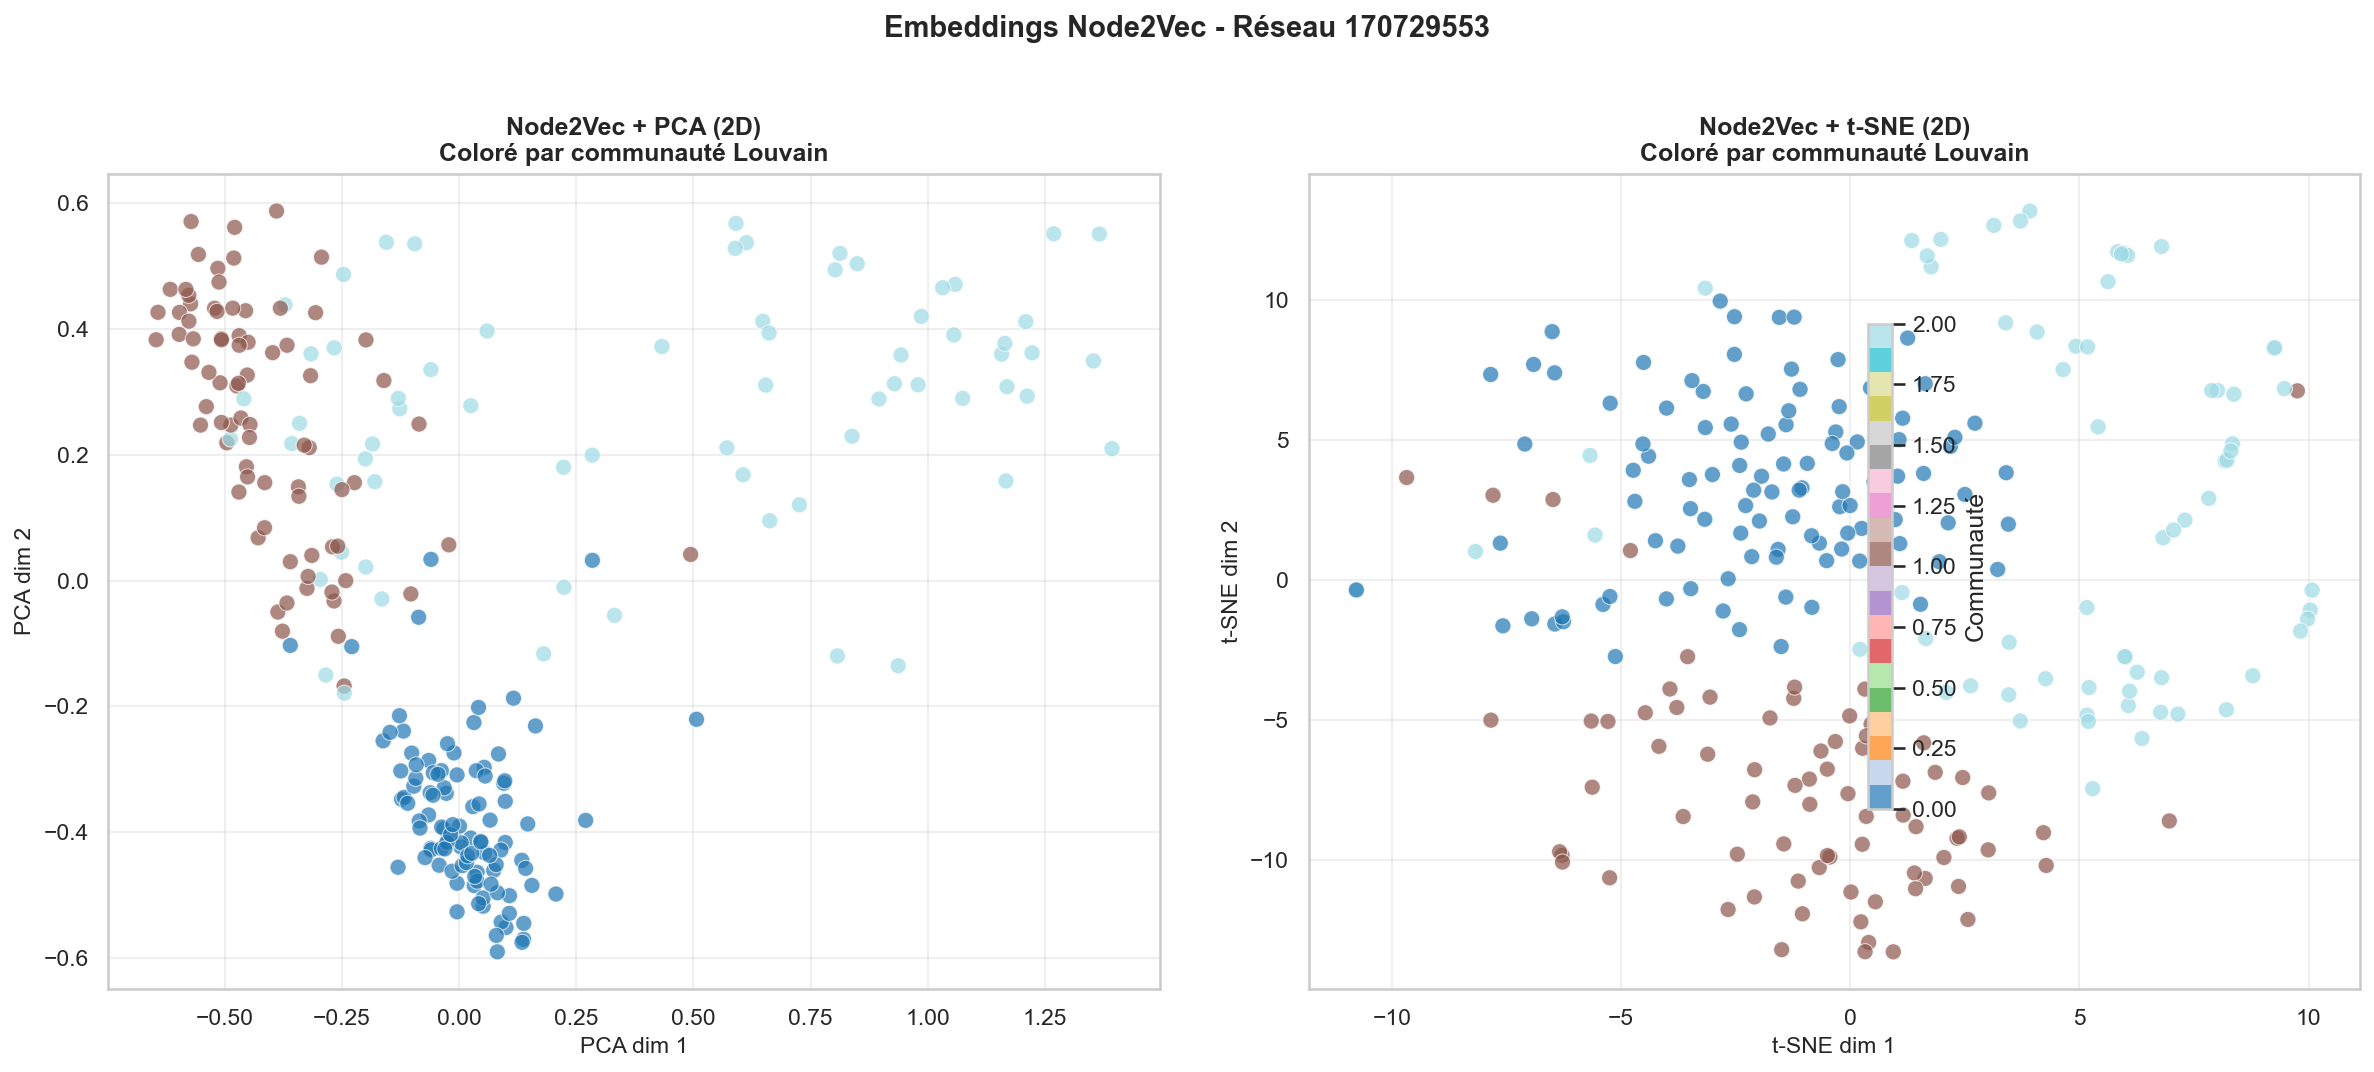

In [174]:
# ============================================================================
# VISUALISATION NODE2VEC (2D)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Récupérer les couleurs des communautés pour les noeuds Node2Vec
community_colors_n2v = [partition.get(n, 0) for n in nodes_n2v]

# --- Plot 1: PCA sur Node2Vec ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
n2v_pca = pca.fit_transform(node2vec_embeddings)

ax1 = axes[0]
scatter1 = ax1.scatter(
    n2v_pca[:, 0],
    n2v_pca[:, 1],
    c=community_colors_n2v,
    cmap=plt.cm.tab20,
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
ax1.set_xlabel('PCA dim 1', fontsize=11)
ax1.set_ylabel('PCA dim 2', fontsize=11)
ax1.set_title('Node2Vec + PCA (2D)\nColoré par communauté Louvain', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: t-SNE sur Node2Vec ---
print("Calcul de t-SNE sur les embeddings Node2Vec...")
n_samples = len(nodes_n2v)
perplexity = min(30, max(5, n_samples // 4))
perplexity = min(perplexity, n_samples - 1)

tsne_n2v = TSNE(n_components=2, random_state=42, perplexity=perplexity)
n2v_tsne = tsne_n2v.fit_transform(node2vec_embeddings)

ax2 = axes[1]
scatter2 = ax2.scatter(
    n2v_tsne[:, 0],
    n2v_tsne[:, 1],
    c=community_colors_n2v,
    cmap=plt.cm.tab20,
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
ax2.set_xlabel('t-SNE dim 1', fontsize=11)
ax2.set_ylabel('t-SNE dim 2', fontsize=11)
ax2.set_title('Node2Vec + t-SNE (2D)\nColoré par communauté Louvain', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Colorbar commune
cbar = plt.colorbar(scatter2, ax=axes, shrink=0.6, label='Communauté')

plt.suptitle(f'Embeddings Node2Vec - Réseau {rep}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

out_path_n2v = summary_dir / f'{rep}_node2vec_embeddings.png'
plt.savefig(out_path_n2v, dpi=150, bbox_inches='tight')
plt.close()
print(f"Sauvegardé: {out_path_n2v}")
display(Image(filename=str(out_path_n2v)))

In [175]:
# ============================================================================
# ANALYSE DES SIMILARITÉS NODE2VEC
# ============================================================================

# Trouver les noeuds les plus similaires pour quelques exemples
print("=" * 60)
print("ANALYSE DES SIMILARITÉS NODE2VEC")
print("=" * 60)

# Sélectionner quelques noeuds d'intérêt (le noeud ego et quelques autres)
sample_nodes = [str(rep)] + [str(n) for n in list(G_undirected.nodes())[:3] if str(n) != str(rep)]

for node in sample_nodes[:4]:  # Limiter à 4 noeuds
    if node in model.wv:
        print(f"\n📍 Noeuds les plus similaires à {node}:")
        similar = model.wv.most_similar(node, topn=5)
        for sim_node, score in similar:
            print(f"   → {sim_node}: {score:.4f}")

# Comparer les embeddings entre communautés
print("\n" + "=" * 60)
print("COHÉRENCE INTRA-COMMUNAUTÉ (cosine similarity moyenne)")
print("=" * 60)

from sklearn.metrics.pairwise import cosine_similarity

# Calculer la similarité moyenne intra-communauté
communities = {}
for node in nodes_n2v:
    comm = partition.get(node, 0)
    if comm not in communities:
        communities[comm] = []
    communities[comm].append(node)

intra_sim = {}
for comm, members in communities.items():
    if len(members) > 1:
        indices = [nodes_n2v.index(m) for m in members]
        emb_comm = node2vec_embeddings[indices]
        sim_matrix = cosine_similarity(emb_comm)
        # Moyenne des similarités (hors diagonale)
        n = len(members)
        avg_sim = (sim_matrix.sum() - n) / (n * (n - 1)) if n > 1 else 1.0
        intra_sim[comm] = avg_sim
        print(f"Communauté {comm} ({len(members)} membres): similarité moyenne = {avg_sim:.4f}")

# Moyenne globale
if intra_sim:
    print(f"\n✅ Similarité intra-communauté moyenne: {np.mean(list(intra_sim.values())):.4f}")

ANALYSE DES SIMILARITÉS NODE2VEC

📍 Noeuds les plus similaires à 170729553:
   → 94480069: 0.5902
   → 23166089: 0.5701
   → 55259512: 0.5493
   → 19039286: 0.5485
   → 249381230: 0.5466

📍 Noeuds les plus similaires à 231975020:
   → 126444583: 0.6668
   → 116246461: 0.6404
   → 65673: 0.6139
   → 111164068: 0.5952
   → 242451319: 0.5950

📍 Noeuds les plus similaires à 14666401:
   → 15993650: 0.6197
   → 116952434: 0.5889
   → 141021153: 0.5659
   → 131601987: 0.5434
   → 204089551: 0.5375

📍 Noeuds les plus similaires à 111164068:
   → 28149277: 0.7934
   → 126444583: 0.6539
   → 131601987: 0.6434
   → 65673: 0.6366
   → 22784458: 0.6352

COHÉRENCE INTRA-COMMUNAUTÉ (cosine similarity moyenne)
Communauté 0 (103 membres): similarité moyenne = 0.3047
Communauté 1 (78 membres): similarité moyenne = 0.3824
Communauté 2 (67 membres): similarité moyenne = 0.2955

✅ Similarité intra-communauté moyenne: 0.3275


### Interprétation : Node2Vec

| Aspect | Description |
|--------|-------------|
| **Principe** | Marches aléatoires biaisées + Word2Vec (Skip-gram) |
| **Paramètres p/q** | **p** contrôle le retour (p<1 favorise le retour, p>1 le décourage). **q** contrôle l’exploration : **q>1 = BFS-like (local)**, **q<1 = DFS-like (global)**. |
| **Avantages** | Flexible, capture homophilie **et** équivalence structurelle |
| **Inconvénients** | Coûteux (temps/mémoire) + hyperparamètres à tuner |

**Observations :**
- Les noeuds d’une même communauté ont tendance à avoir des embeddings similaires
- Node2Vec capture bien la structure de voisinage via les marches aléatoires
- Les visualisations PCA/t-SNE montrent souvent une séparation partielle des communautés

**Comparaison avec Laplacian Eigenmaps :**
- Node2Vec est plus flexible (p/q) mais plus coûteux
- Laplacian Eigenmaps est plus “théorique/spectral” et dépend fortement du Laplacien

## Discussion, interpretation, and limitations

### Key findings (multi-network comparison)
- Ego-networks show strong variability in size/density/clustering, suggesting heterogeneous local structures.
- Degree distributions are heavy-tailed: most nodes have low degree, a few concentrate many edges.

### Centralities (selected network)
- Centrality measures highlight a small set of structurally important nodes.
- The ego node may dominate some scores; recomputing without ego can reveal influential “alter” nodes.

### Communities
- Louvain efficiently finds modular structure; Girvan–Newman often yields fewer/larger communities and is heavier computationally.
- Modularity and conductance provide quantitative comparison of community partitions.

### Embeddings (spectral vs neural)
- Laplacian Eigenmaps capture global geometry via spectral structure.
- Node2Vec (random walks + skip-gram) captures higher-order proximity; projections show partial separation by communities.

### Downstream task (Graph ML)
- Link prediction using Node2Vec embeddings shows that learned representations carry predictive signal about missing edges.

### Limitations
- Results depend on directed vs undirected choices and on ego-removal decisions.
- Louvain/GN are unsupervised; community IDs are not ground truth.
- t-SNE/PCA can distort distances; prefer quantitative metrics to support conclusions.

### Next steps
- Use node attributes (`.feat`) if available for supervised node classification.
- Evaluate stability by repeating deep dive on a “typical” and an “unusual” network.
- Tune Node2Vec (p, q) to explore BFS/DFS bias.

In [176]:
print('='*80)
print('FINAL SUMMARY REPORT')
print('='*80)
print(f"Total ego networks analyzed: {len(ego_network_ids)}")
print(f"Summary CSVs and outputs saved to: {summary_dir}")
print('Saved files:')
for p in sorted(summary_dir.iterdir()):
    print(' -', p.name)
print('='*80)
print('Analysis complete')

FINAL SUMMARY REPORT
Total ego networks analyzed: 973
Summary CSVs and outputs saved to: twitter_ego\twitter\summary_tables
Saved files:
 - 170729553_all_centralities.csv
 - 170729553_betweenness.png
 - 170729553_centralities_comparison.png
 - 170729553_centrality_correlation.csv
 - 170729553_centrality_correlation.png
 - 170729553_community_comparison.csv
 - 170729553_community_comparison.png
 - 170729553_community_quality_metrics.csv
 - 170729553_degree_distribution_hist.png
 - 170729553_gcn_tsne_visualization.png
 - 170729553_girvan_newman.png
 - 170729553_girvan_newman_communities.csv
 - 170729553_graph.png
 - 170729553_laplacian_eigenmaps.csv
 - 170729553_laplacian_eigenmaps.png
 - 170729553_louvain_communities_noego.png
 - 170729553_node2vec_embeddings.csv
 - 170729553_node2vec_embeddings.png
 - 170729553_node_embeddings.csv
 - 170729553_pagerank_noego.png
 - 170729553_representative.png
 - 170729553_selected_graph.png
 - 170729553_training_curves.png
 - 170729553_training_histor

## Summary — selected network: **170729553**

- ‘Typical’ network (min distance_from_mean): **197602850**

- Network chosen for deep dive (top nodes): **170729553**

- Nodes: **248**

- Edges: **8237**

...

- Average Precision: **0.726**

### Centralities (preview)

,degree,in_degree,out_degree,eigenvector,closeness,betweenness,pagerank
node,,,,,,,
231975020,0.425101,0.170040,0.255061,0.088923,0.452907,0.004233,0.004287
14666401,0.526316,0.299595,0.226721,0.101506,0.495496,0.005321,0.006491
111164068,0.595142,0.344130,0.251012,0.107064,0.516834,0.009559,0.010482
57986173,0.271255,0.186235,0.085020,0.055581,0.471695,0.000994,0.005095
60725654,0.251012,0.182186,0.068826,0.058215,0.473764,0.004101,0.005065
252185621,0.497976,0.230769,0.267206,0.094708,0.492110,0.008375,0.006870
155969606,0.336032,0.186235,0.149798,0.054138,0.453858,0.002114,0.004726
21624907,0.425101,0.242915,0.182186,0.076385,0.483303,0.003386,0.005643
85501252,0.380567,0.214575,0.165992,0.073095,0.463598,0.001320,0.004808


File: `170729553_all_centralities.csv`

### Louvain communities (without ego)
File: `170729553_louvain_communities_noego.png`

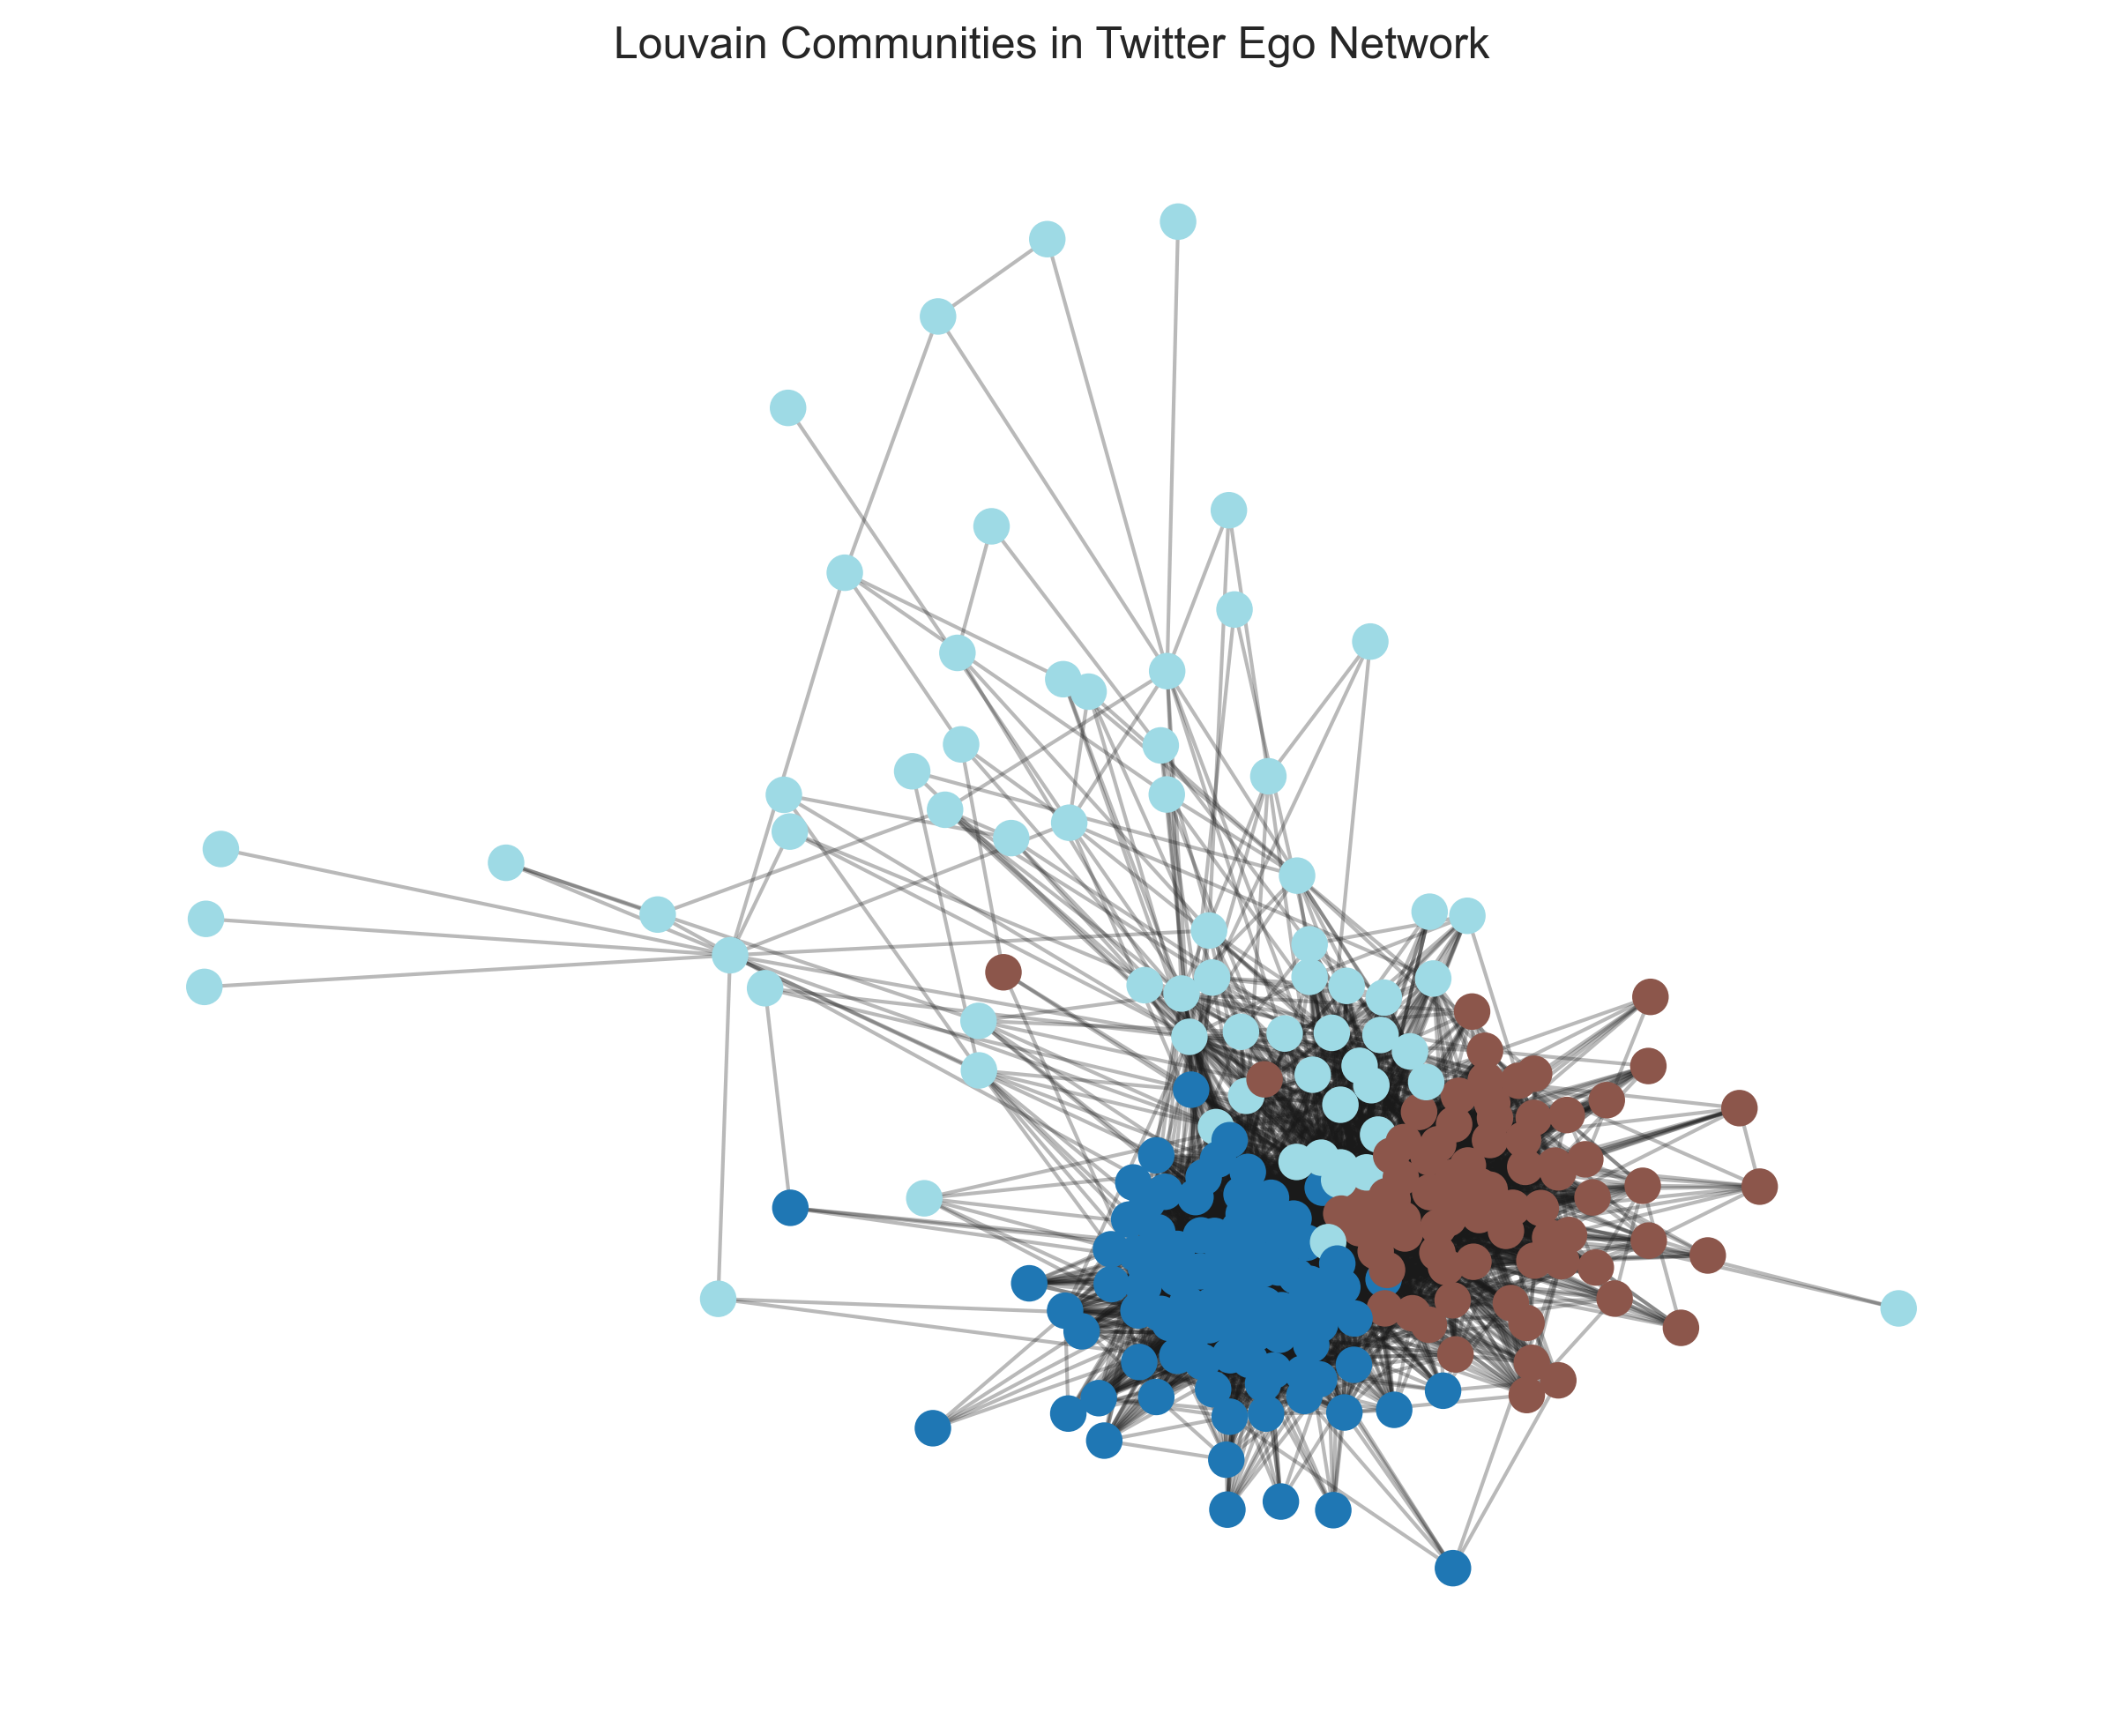

### Girvan–Newman communities (preview)

,node,community_gn
0,119102465,0
1,108928516,0
2,191548936,0
3,24945163,0
4,9117202,0
5,156444178,0
6,182884883,0
7,252185621,0
8,42587673,0
9,28149277,0


File: `170729553_girvan_newman_communities.csv`

### Community quality (Louvain vs GN)

,Métrique,Louvain,Girvan-Newman,Meilleur
0,Modularité (Q),0.2537,0.0079,Louvain
1,Coverage,0.6660,0.9888,Girvan-Newman
2,Performance,0.7204,0.4002,Louvain
3,Conductance (↓),0.4022,0.7964,Louvain
4,Nb communautés,3.0000,14.0000,-
5,Taille moyenne,82.3000,17.6000,-


File: `170729553_community_quality_metrics.csv`

### Node2Vec embeddings (preview)

,N2V_0,N2V_1,N2V_2,N2V_3,N2V_4,N2V_5,N2V_6,N2V_7,N2V_8,N2V_9,...,N2V_54,N2V_55,N2V_56,N2V_57,N2V_58,N2V_59,N2V_60,N2V_61,N2V_62,N2V_63
node_id,,,,,,,,,,,,,,,,,,,,,
231975020,-0.224485,-0.128168,-0.175988,-0.011626,0.052470,-0.036331,-0.224588,0.035645,-0.083449,0.024519,...,0.007657,0.008282,-0.062812,0.213063,0.014362,-0.053823,0.006892,0.086762,0.014705,0.331665
14666401,-0.094711,0.059357,-0.220418,0.020583,-0.150783,0.017451,-0.082768,0.094508,-0.003647,-0.054063,...,-0.051160,0.062440,-0.123635,-0.109338,-0.070363,0.064707,0.018679,-0.024355,-0.028845,0.122976
111164068,-0.170995,-0.252276,-0.082115,0.095740,0.213699,-0.126661,-0.045681,0.024210,0.027687,0.112976,...,0.137225,-0.217976,0.067999,-0.025510,-0.009668,-0.097083,0.078602,0.077525,-0.042664,0.127039
57986173,0.058772,0.202116,-0.056297,0.045199,0.117157,0.016213,-0.108604,0.019147,0.212475,-0.007452,...,-0.177225,-0.074688,0.395705,-0.027832,-0.159873,0.117388,-0.104368,-0.059942,0.135767,0.173564
60725654,0.150049,-0.178534,-0.104792,0.328360,-0.175476,0.437461,0.007574,-0.231067,-0.146783,-0.023749,...,0.058470,-0.208575,-0.001889,-0.073449,-0.022454,-0.278122,0.080059,0.049143,-0.218414,0.021623
252185621,-0.102873,0.056732,0.105578,0.075496,0.071619,0.141860,-0.095493,0.190784,0.056769,-0.010830,...,0.240055,-0.050407,-0.094071,-0.137146,-0.070765,-0.003852,-0.066492,0.103510,0.016669,0.110728
155969606,0.137481,-0.256591,-0.060957,0.215314,0.097490,0.179741,0.006728,0.201537,0.128684,0.150508,...,0.089510,-0.438346,-0.312289,0.093428,-0.227015,0.244176,-0.141256,-0.152559,0.189597,0.084556
21624907,-0.004042,-0.045600,-0.008388,0.039797,0.012584,0.005280,-0.215418,0.173928,0.023217,0.039128,...,-0.092044,-0.120601,0.267222,-0.235592,0.080065,0.009791,0.139750,-0.020431,-0.137324,0.114149
85501252,0.081742,-0.136018,0.023672,0.133229,0.071712,0.264966,-0.049034,0.299198,0.033083,-0.126149,...,0.151176,0.182311,0.068325,0.125046,0.095358,-0.016895,0.017046,0.042438,0.032903,0.116901


File: `170729553_node2vec_embeddings.csv`

### Node2Vec visualization (PCA + t-SNE)
File: `170729553_node2vec_embeddings.png`

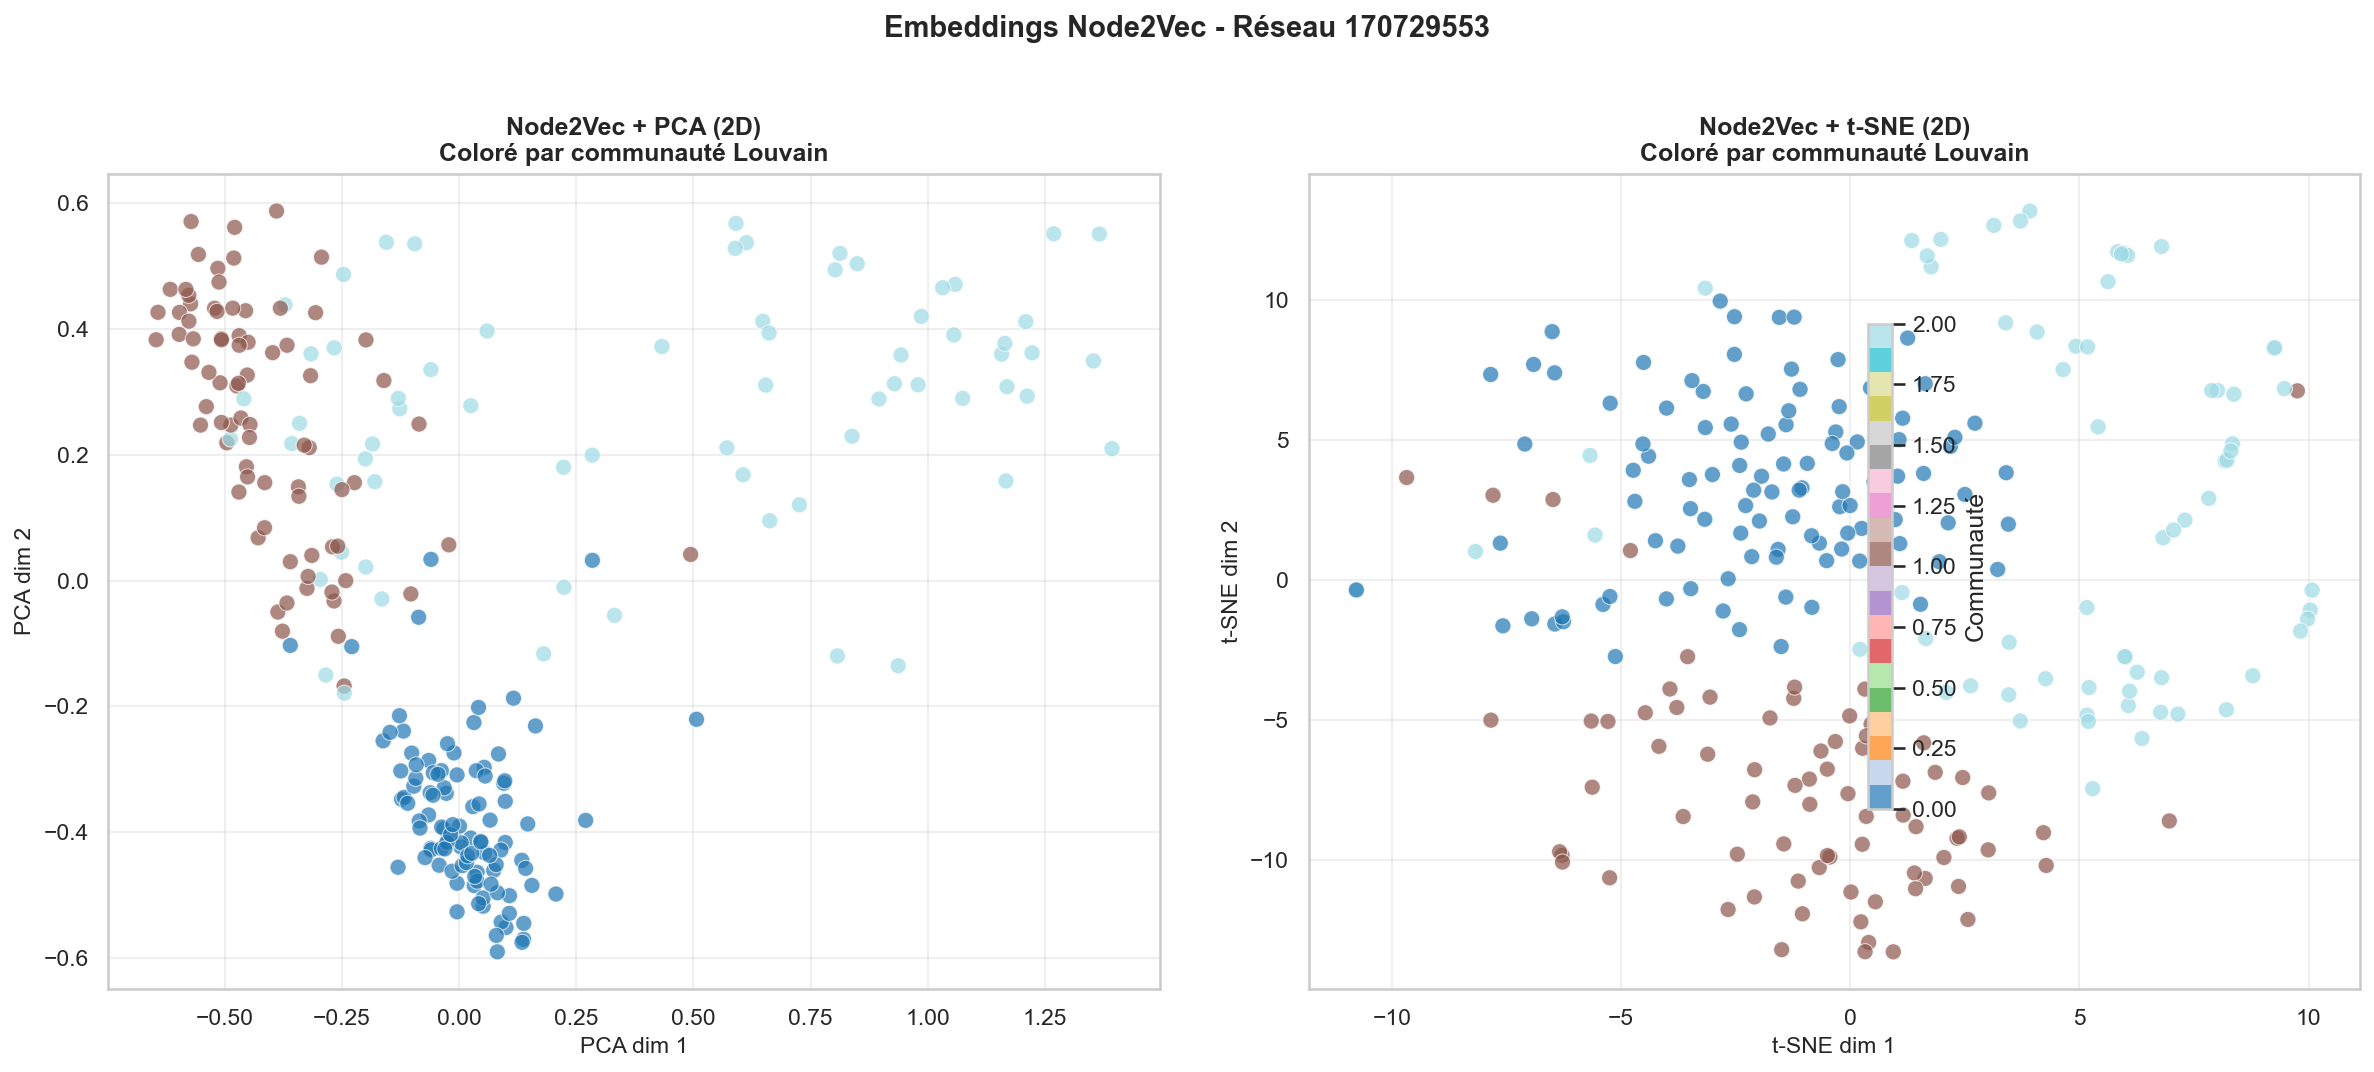

### Laplacian Eigenmaps visualization (t-SNE)
File: `170729553_laplacian_eigenmaps.png`

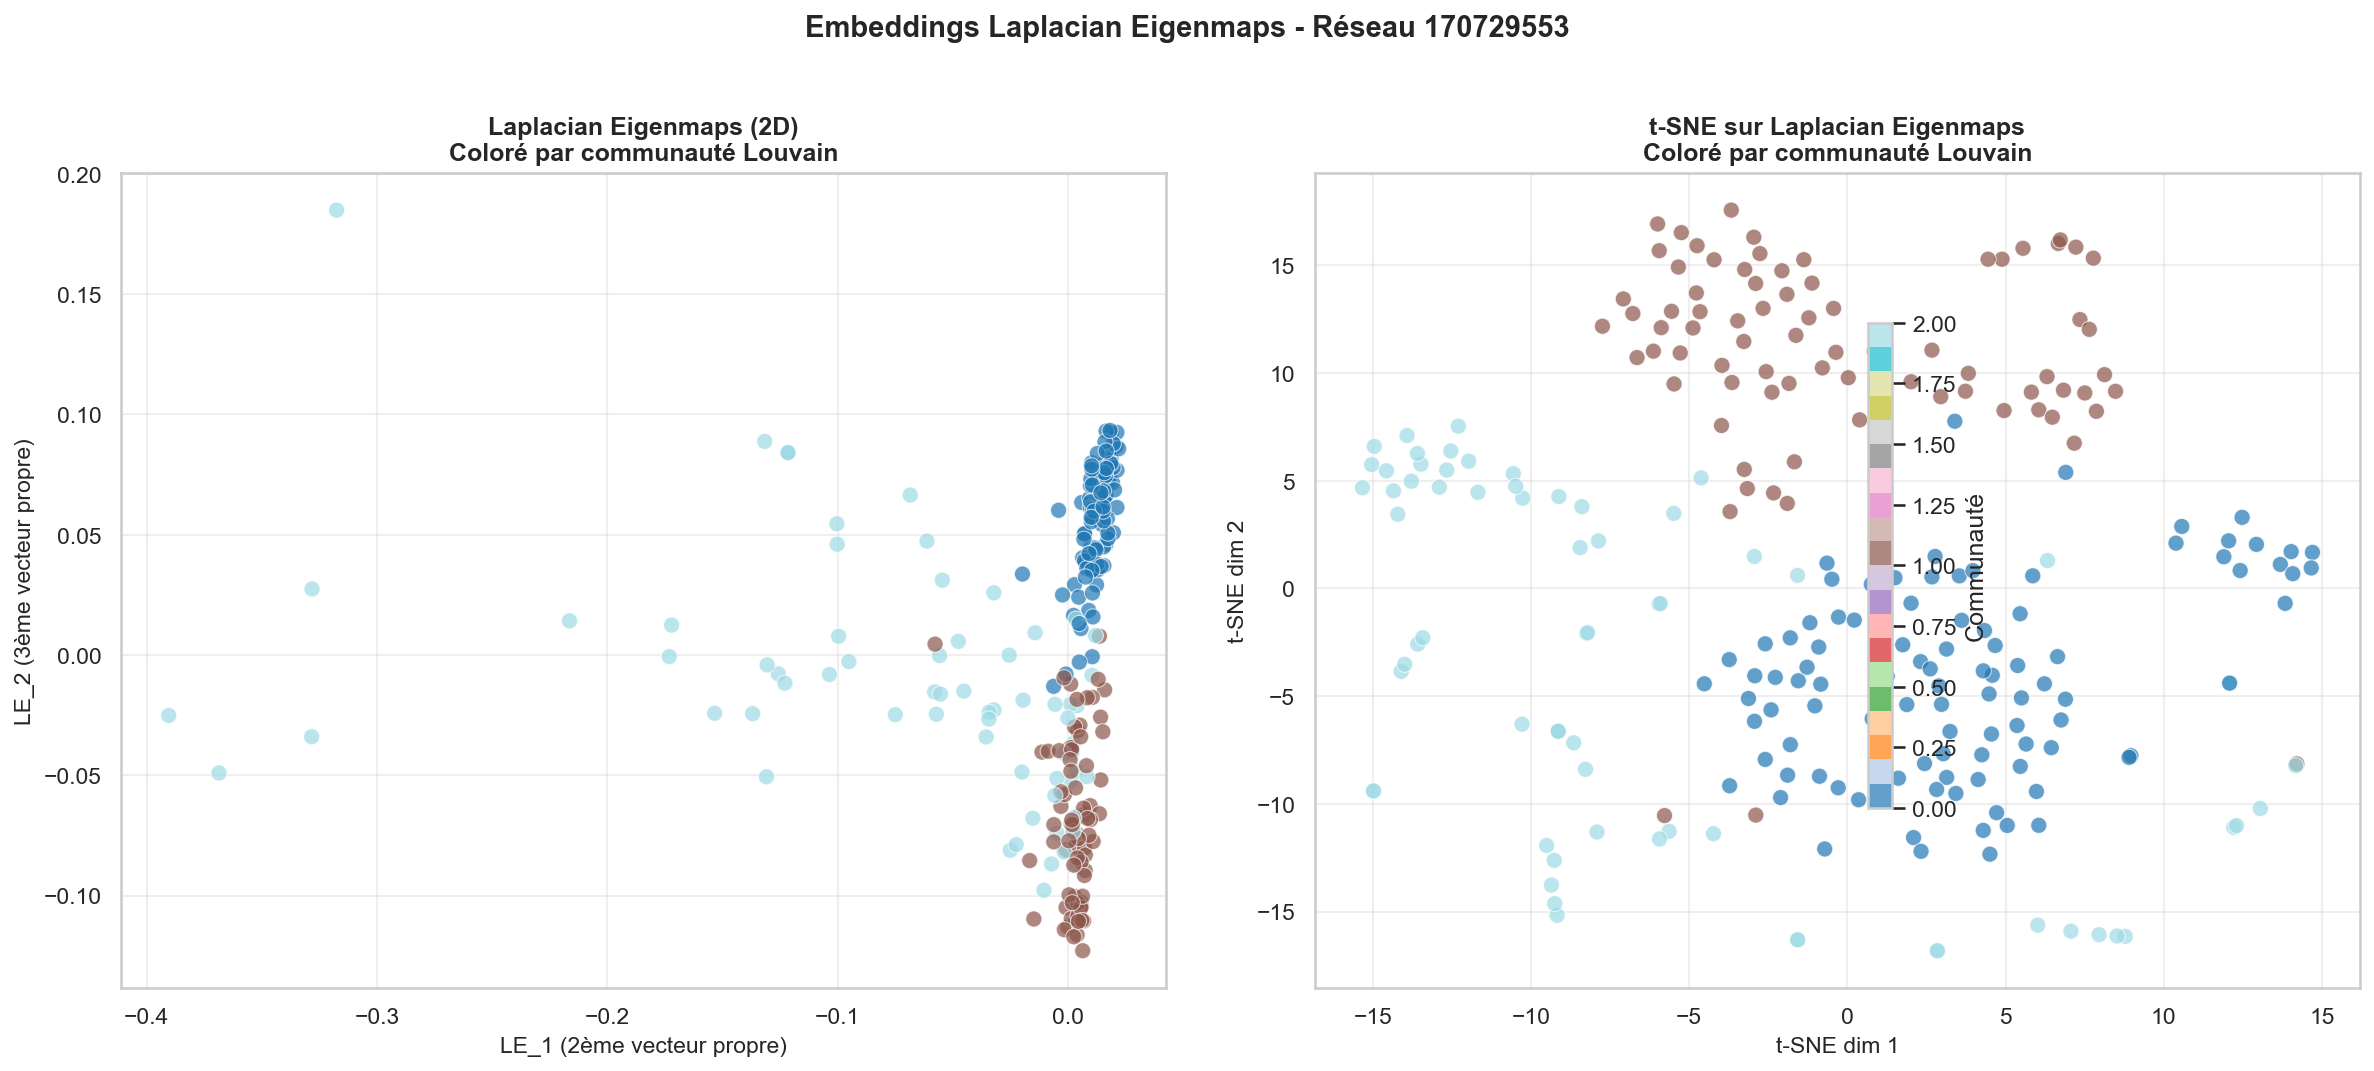

### GCN training curves
File: `170729553_training_curves.png`

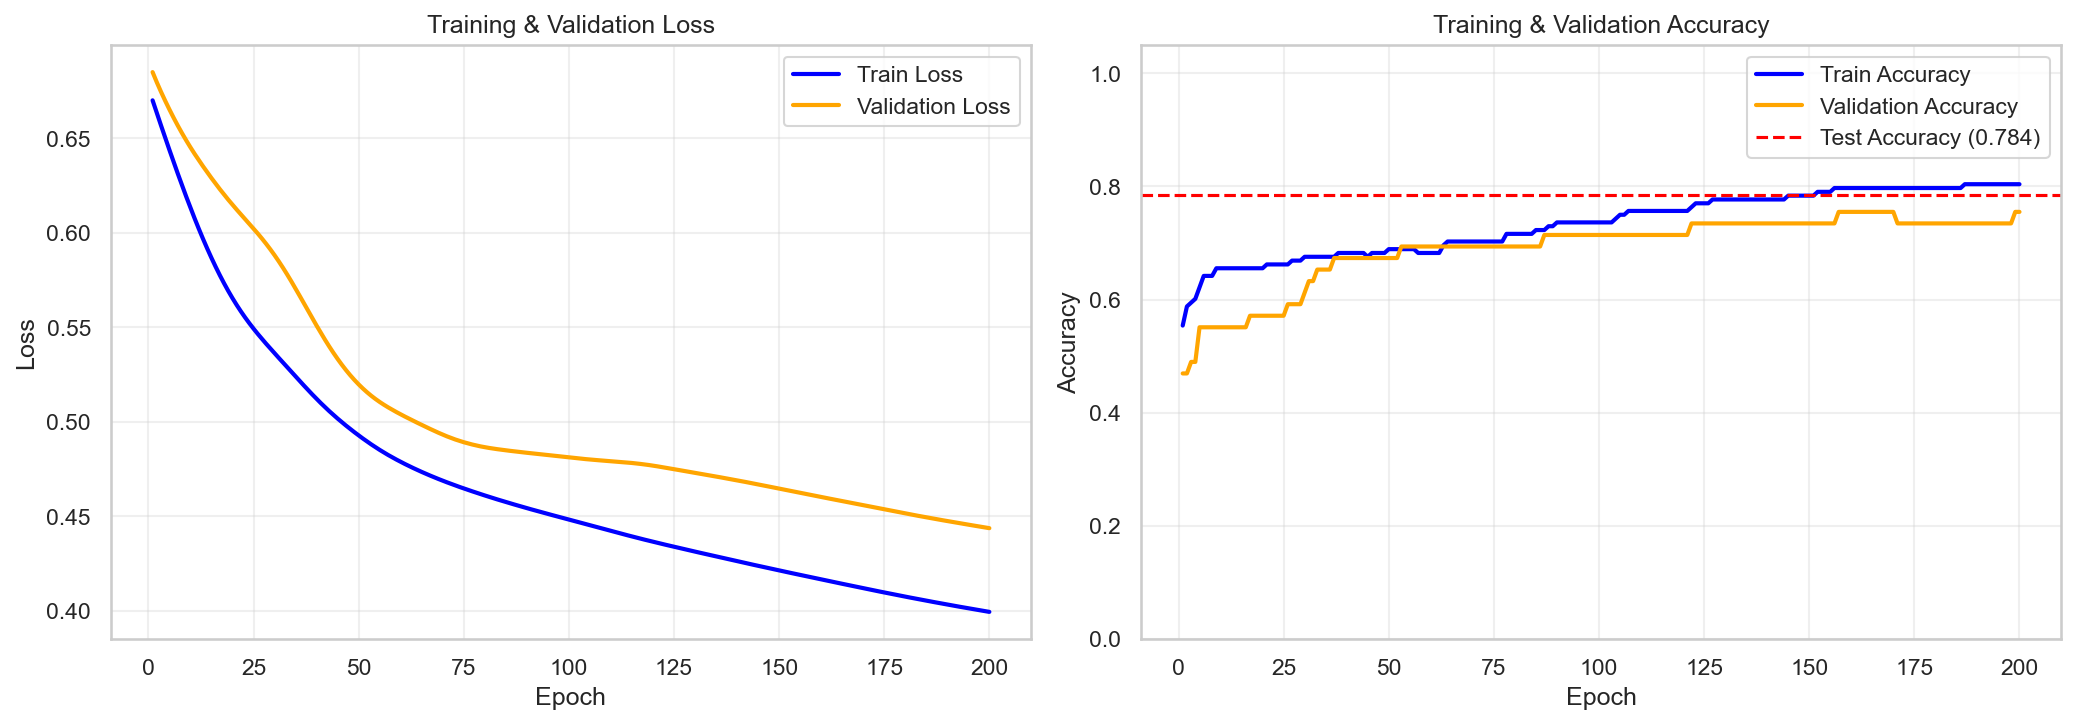

### GCN embeddings t-SNE (colored)
File: `170729553_gcn_tsne_visualization.png`

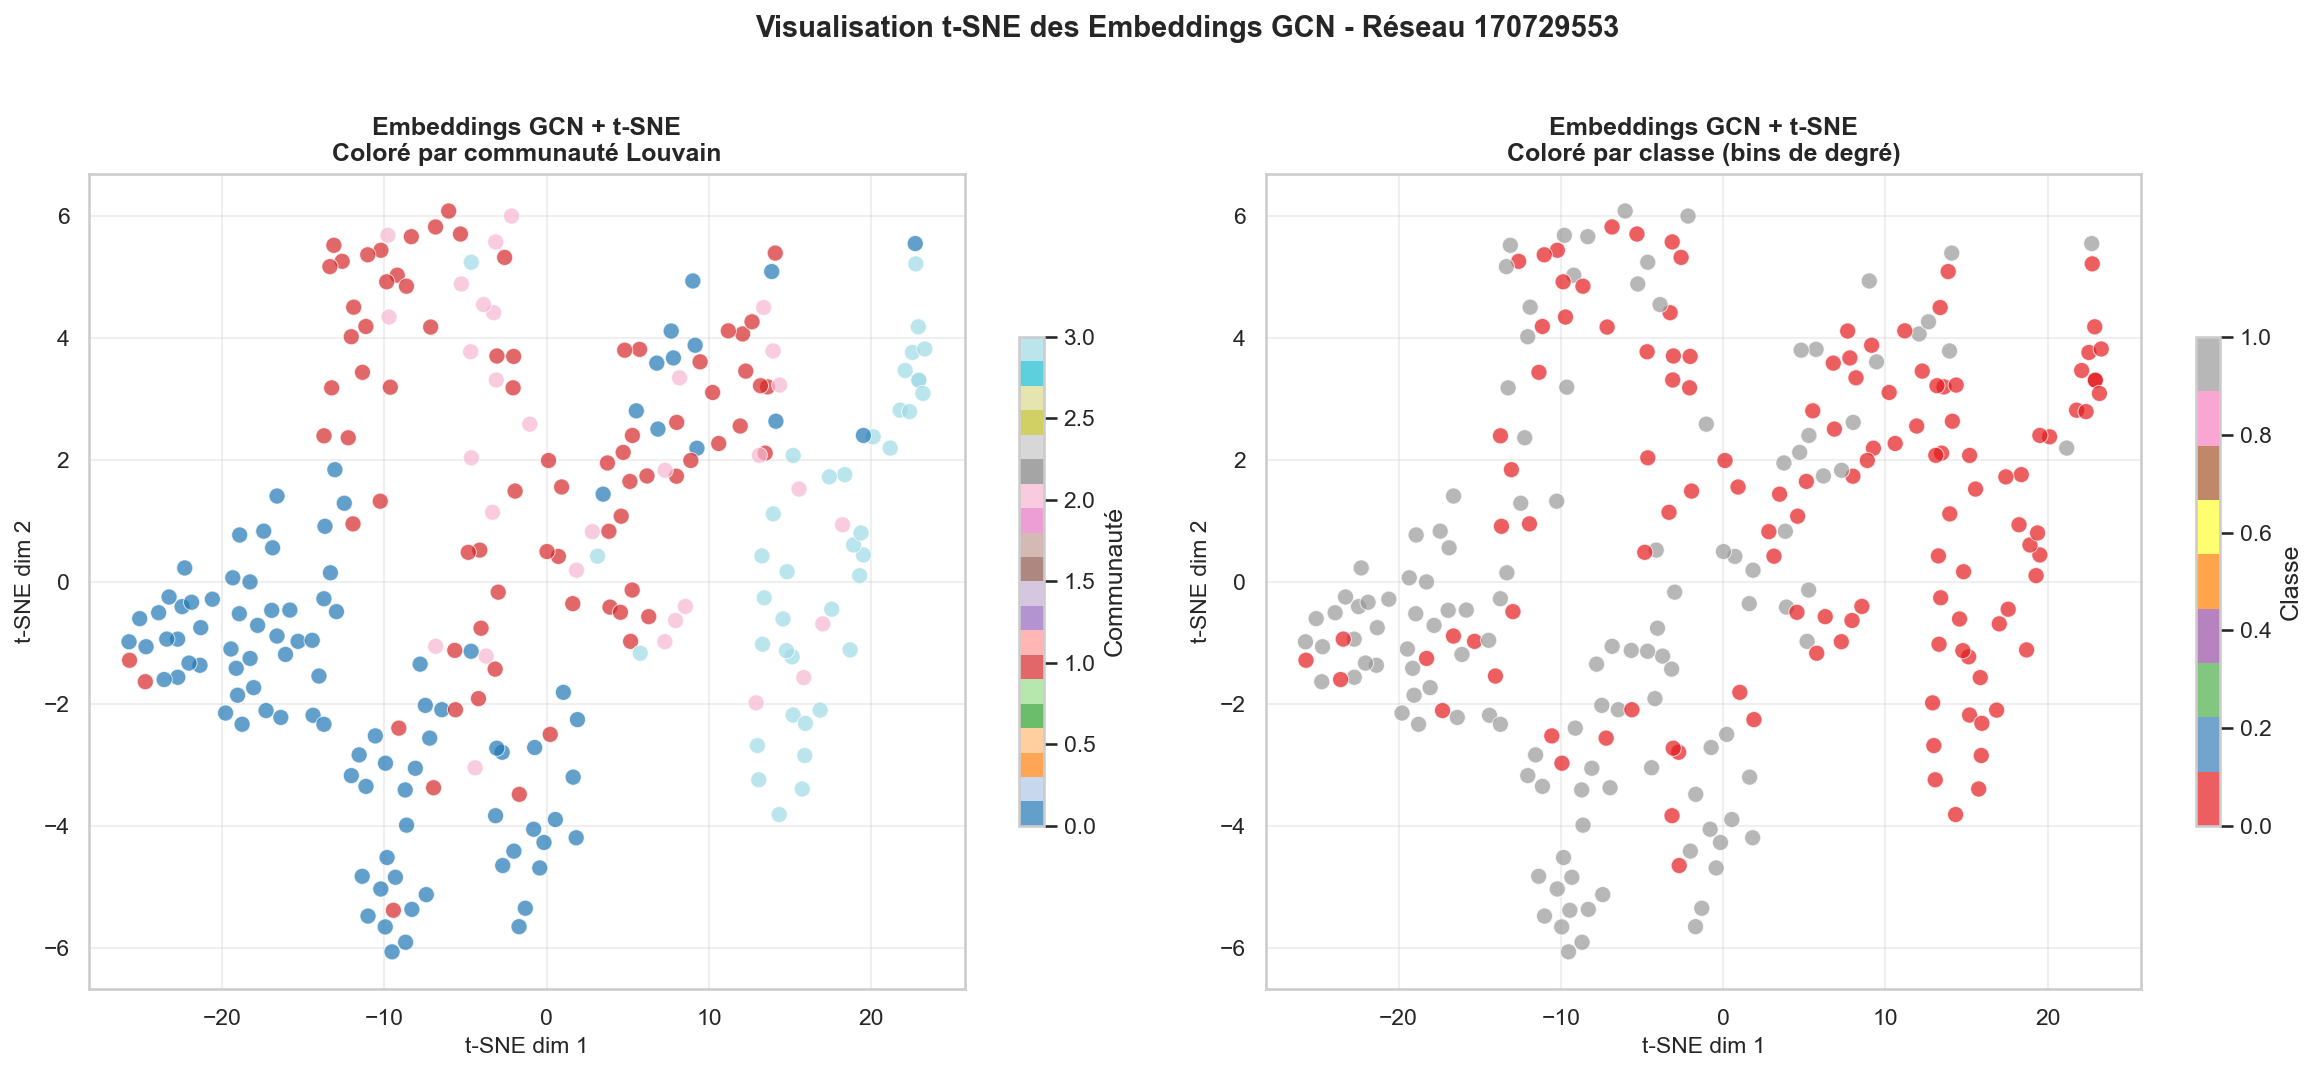

### GCN prepared node features + synthetic labels

,deg_z,clust_z,label
231975020,0.745321,0.051223,1
14666401,1.109399,-0.342277,1
111164068,1.305441,-0.356911,1
57986173,0.101183,-0.145189,1
60725654,0.101183,-0.645685,1
252185621,0.885351,-0.098077,1
155969606,-0.010841,-0.219717,1
21624907,0.465261,-0.221297,1
85501252,0.409249,0.212674,1
11202942,0.241213,-0.314349,1


File: `prepared_170729553_nodes.csv`

### Bonus Deep Learning — GCN (toy node classification)

- Test accuracy: **0.784** (labels = bins de degré)

### Quick interpretation
- **Louvain vs GN**: modularity + conductance compare partitions quantitatively.
- **Embeddings**: Laplacian (spectral) captures global geometry; Node2Vec captures higher-order proximity.
- **Downstream task**: link prediction scores indicate whether embeddings contain predictive signal.

In [177]:
from IPython.display import display, Markdown
import pandas as pd
import networkx as nx

rep = globals().get("representative_net", None)
rep_avg = globals().get("representative_net_avg", None)
graphs = globals().get("graphs", None)
summary_dir = globals().get("summary_dir", None)

if rep is None or graphs is None or summary_dir is None:
    display(Markdown(
        "**No selected network / missing variables.**\n\n"
        "Run: load graphs → compute stats → the selection block (representative_net)."
    ))
else:
    rep = int(rep)
    display(Markdown(f"## Summary — selected network: **{rep}**"))

    if rep_avg is not None:
        display(Markdown(f"- ‘Typical’ network (min distance_from_mean): **{rep_avg}**"))
        display(Markdown(f"- Network chosen for deep dive (top nodes): **{rep}**"))

    if isinstance(graphs, dict) and rep in graphs:
        Gsel = graphs[rep]
        display(Markdown(f"- Nodes: **{Gsel.number_of_nodes()}**"))
        display(Markdown(f"- Edges: **{Gsel.number_of_edges()}**"))
        display(Markdown(f"- Density: **{nx.density(Gsel):.4f}**"))
        if "clustering_df" in globals() and rep in clustering_df.index:
            display(Markdown(f"- Avg clustering: **{clustering_df.loc[rep,'avg_clustering']:.4f}**"))
    else:
        display(Markdown("⚠️ Graph not found in `graphs`."))
        Gsel = None

    lp_auc = globals().get("lp_auc", None)
    lp_ap = globals().get("lp_ap", None)
    display(Markdown("### Downstream task — link prediction (Node2Vec)"))
    if lp_auc is not None and lp_ap is not None:
        display(Markdown(f"- ROC-AUC: **{lp_auc:.3f}**"))
        display(Markdown(f"- Average Precision: **{lp_ap:.3f}**"))
    else:
        display(Markdown("- No metrics available (run the link prediction cell)."))

    def show_csv(path, title, index_col=None):
        if path.exists():
            display(Markdown(f"### {title}"))
            df = pd.read_csv(path, index_col=index_col)
            display(df.head(10))
            display(Markdown(f"File: `{path.name}`"))
        else:
            display(Markdown(f"- `{path.name}` not found."))

    def show_png(path, title):
        if path.exists():
            from IPython.display import Image, display as _display
            display(Markdown(f"### {title}\nFile: `{path.name}`"))
            _display(Image(filename=str(path)))
        else:
            display(Markdown(f"- `{path.name}` not found."))

    show_csv(summary_dir / f"{rep}_all_centralities.csv", "Centralities (preview)", index_col=0)
    show_png(summary_dir / f"{rep}_louvain_communities_noego.png", "Louvain communities (without ego)")
    show_csv(summary_dir / f"{rep}_girvan_newman_communities.csv", "Girvan–Newman communities (preview)")
    show_csv(summary_dir / f"{rep}_community_quality_metrics.csv", "Community quality (Louvain vs GN)")

    show_csv(summary_dir / f"{rep}_node2vec_embeddings.csv", "Node2Vec embeddings (preview)", index_col=0)
    show_png(summary_dir / f"{rep}_node2vec_embeddings.png", "Node2Vec visualization (PCA + t-SNE)")
    show_png(summary_dir / f"{rep}_laplacian_eigenmaps.png", "Laplacian Eigenmaps visualization (t-SNE)")

    show_png(summary_dir / f"{rep}_training_curves.png", "GCN training curves")
    show_png(summary_dir / f"{rep}_gcn_tsne_visualization.png", "GCN embeddings t-SNE (colored)")
    show_csv(summary_dir / f"prepared_{rep}_nodes.csv", "GCN prepared node features + synthetic labels", index_col=0)

    test_acc_val = globals().get("test_acc", None)
    display(Markdown("### Bonus Deep Learning — GCN (toy node classification)"))
    if test_acc_val is not None:
        display(Markdown(f"- Test accuracy: **{test_acc_val:.3f}** (labels = bins de degré)"))
    else:
        display(Markdown("- Test accuracy not available (GCN cell not executed)."))

    display(Markdown(
        "### Quick interpretation\n"
        "- **Louvain vs GN**: modularity + conductance compare partitions quantitatively.\n"
        "- **Embeddings**: Laplacian (spectral) captures global geometry; Node2Vec captures higher-order proximity.\n"
        "- **Downstream task**: link prediction scores indicate whether embeddings contain predictive signal."
    ))